> **SENSITIVITY CALIBRATION — FULL THETA + SCCM_CORRECTED, WITHOUT LAB010,
> WITH REPAIRED SAMPLING SIGNALS FOR LAB004/LAB007/LAB008**
>
> This SOURCE notebook reuses the complete full-theta calibration suite without modifying its
> preprocessing, model, objective, bounds, weights or multistart settings. Two interventions are
> isolated here: (1) LAB010 is excluded from every natural-matrix optimization and
> identifiability refit, and (2) the observed CO2 signal of LAB004, LAB007 and LAB008 is
> replaced by the canonical sampling-repaired versions produced by the microleaks /
> sampling-transients diagnostics. Every other observed row stays byte-identical to the frozen
> SCCM-corrected input, so the previous-signals versus repaired-signals comparison below
> isolates exactly that signal change. LAB012 remains the internal natural holdout, and LAB010
> is evaluated afterwards with frozen parameters. LAB013–LAB015 are external kinetic / activation holdouts and are never used to tune
> anything; their documented-unreliable gas signals are shown only in an exploratory overlay.


# CO2-layer sensitivity: LAB010 exclusion and repaired sampling signals

## Full natural theta, recalibrated CO2 layer, corrected SCCM

Comparisons reported here:

- **A — current:** full-theta calibration including LAB010, original signals;
- **B — sensitivity:** the same calibration excluding LAB010 from the natural fit, with the
  canonical sampling-repaired observed signals for LAB004/LAB007/LAB008;
- **A′ versus B isolation:** the previous no-LAB010 run on the original signals (frozen
  snapshot) versus the run above, so the repaired-signal effect is isolated from the LAB010
  exclusion.

The synthetic fit and cross-matrix machinery are retained unchanged. No kinetic theta is
re-estimated in this notebook.


## Estructura del modelo

Para la corrida (r), primero se corrige el cero instrumental en la señal nativa:

\[
b_r=\max\left[0,Q_{0.10}\{y_{sccm}(t):t\leq t_0+12\,h\}\right],\qquad
y_{corr}(t)=\max[y_{sccm}(t)-b_r,0]
\]

La conversión a g L⁻¹ h⁻¹, el filtrado de transientes y el suavizado ocurren después. Esta regla supone que el extremo inferior de las primeras 12 h representa cero instrumental; si ya existe flujo biológico durante toda esa ventana, puede sustraer parte de la señal real.

La primera muestra química que cumple pérdida de glucosa+fructosa ≥5 g/L o aumento de etanol ≥2 g/L marca el extremo superior del intervalo de activación. La muestra química anterior fija el extremo inferior. La fuente usa una rampa *smoothstep* continua:

\[
t_s=t_L+f_s(t_U-t_L),\quad
\Delta t=f_d(t_U-t_L),\quad
a_{chem}=3z^2-2z^3,\quad
z=\operatorname{clip}\!\left(\frac{t-t_s}{\Delta t},0,1\right)
\]

Los parámetros (f_s) y (f_d) son compartidos por matriz. Esto permite un aumento pequeño y gradual desde (t_s), pero mantiene el comienzo ligado al bracket químico en vez de introducir una latencia independiente por fermentación.

\[
\frac{dO_2}{dt}=-q_{O_2,max}X\frac{O_2}{K_{O_2}+O_2},\qquad
\phi_{ana}=\frac{K_{ana}^{h}}{K_{ana}^{h}+O_2^{h}}
\]

\[
q_{prod}=a_{chem}(t)\left[q_{bio}\left(f_{Crabtree}+(1-f_{Crabtree})\phi_{ana}\right)+q_{resp}\right]
\]

Para una adición en \(t_N\), la fracción utilizada es causal:

\[
f_N(t)=\operatorname{clip}\left(\frac{t-t_N}{t_{rise}},0,1\right),\qquad
q_{bio,N}=\left[1+(g_N-1)f_N(t)\right]q_{bio,0}
+f_N(t)\left(q_{bio,+N}-q_{bio,0}\right)
\]

La biomasa usa la misma diferencia con/sin pulso, pero sin \(g_N\). Así, el término de actividad puede capturar el aumento de capacidad de transporte descrito por el grupo de Sablayrolles sin imponer crecimiento ficticio.

\[
C^*_{CO_2}=s_{sat}\,1.69\,e^{-0.032(T-20)}e^{0.0016E}e^{-0.0012(G+F)}
\]

\[
\frac{dC_{CO_2}}{dt}=q_{prod}-q_{gas},\qquad
q_{gas}=\min\!\left[k_{release}C_{CO_2}
\left(f_0+(1-f_0)\frac{C_{CO_2}}{C_{CO_2}+C^*_{CO_2}}\right),
\frac{C_{CO_2}}{\Delta t}+q_{prod}\right],\quad f_0=0.05
\]

La formulación anterior, usada como comparador directo, tenía (q_{gas}=k_{release}\operatorname{softplus}(C_{CO_2}-C^*_{CO_2})): eso mantenía la predicción pegada a cero hasta acumular suficiente CO₂ disuelto. El nuevo piso (f_0) representa liberación sub-saturada pequeña y evita ese umbral duro.

El inicio observado se define como el primero de tres puntos horarios consecutivos sobre el mayor valor entre: límite de detección local y línea base inicial +10 % del rango dinámico. Además se reporta la primera emisión sostenida sobre 0.005 g L⁻¹ h⁻¹ y la duración visual 2–10 % del ascenso. El ajuste conserva el residuo de tiempo de inicio y, en lotes pulsados, el desfase del máximo durante las 72 h posteriores a la adición, además de los residuos del perfil completo.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Execute this notebook from the repository or a descendant")

FM = ROOT / "fermentation_model"
for path in (FM, FM / "laboratory_2026", FM / "pilot_2025"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from laboratory_2026 import run_co2_matrix_cross_validation_2026_full_theta as analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
print("Repository:", ROOT)
print("Current model:", analysis.MODEL_NAME)
print("Direct comparator:", analysis.THRESHOLD_RELEASE_MODEL_NAME)
print("Historical comparator:", analysis.LEGACY_MODEL_NAME)
print("Holdouts:", analysis.HOLDOUTS)
print("Excluded:", analysis.EXCLUDED_BATCHES)

# Sensitivity isolation: redirect every artifact to a new directory and alter only
# natural-fit membership. The original module and runner files remain untouched.
BASELINE_RESULTS_DIR = analysis.RESULTS_DIR
SENSITIVITY_RESULTS_DIR = (
    analysis.SCRIPT_DIR
    / "results"
    / "co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010"
)
analysis.RESULTS_DIR = SENSITIVITY_RESULTS_DIR
analysis.PLOT_DIR = SENSITIVITY_RESULTS_DIR / "figures"
analysis.NOTEBOOK_PATH = (
    analysis.NOTEBOOK_DIR
    / "co2_solubility_o2_cross_matrix_2026_full_theta_no_lab010.ipynb"
)
analysis.EXECUTED_NOTEBOOK_PATH = (
    analysis.NOTEBOOK_DIR
    / "co2_solubility_o2_cross_matrix_2026_full_theta_no_lab010.executed.ipynb"
)

SENSITIVITY_EXCLUDED_BATCH = "LAB010"
_historical = analysis.historical
_original_fit_matrix = _historical.fit_matrix
_original_calibration_batch_names = _historical._calibration_batch_names
_original_predict_and_score = _historical.predict_and_score

def _without_lab010_from_natural_fit(matrix, observations):
    adjusted = observations.copy()
    if matrix == "natural":
        adjusted.loc[adjusted["batch"].eq(SENSITIVITY_EXCLUDED_BATCH), "calibratable"] = False
    return adjusted

def _sensitivity_fit_matrix(matrix, observations, cache, *args, **kwargs):
    return _original_fit_matrix(
        matrix, _without_lab010_from_natural_fit(matrix, observations), cache, *args, **kwargs
    )

def _sensitivity_calibration_batch_names(matrix, observations):
    names = _original_calibration_batch_names(matrix, observations)
    if matrix == "natural":
        names = [name for name in names if name != SENSITIVITY_EXCLUDED_BATCH]
    return names

def _sensitivity_predict_and_score(fits, observations, cache, *args, **kwargs):
    predictions, metrics, validation = _original_predict_and_score(
        fits, observations, cache, *args, **kwargs
    )
    for frame in (predictions, metrics):
        diagnostic = (
            frame["calibration_matrix"].eq("natural")
            & frame["target_matrix"].eq("natural")
            & frame["batch"].eq(SENSITIVITY_EXCLUDED_BATCH)
        )
        frame.loc[diagnostic, "role"] = "excluded_fit_frozen_diagnostic"
    return predictions, metrics, validation

_historical.fit_matrix = _sensitivity_fit_matrix
_historical._calibration_batch_names = _sensitivity_calibration_batch_names
_historical.predict_and_score = _sensitivity_predict_and_score

print("Baseline results (read-only comparator):", BASELINE_RESULTS_DIR.relative_to(ROOT))
print("Sensitivity results:", SENSITIVITY_RESULTS_DIR.relative_to(ROOT))
print("Natural fit exclusion:", SENSITIVITY_EXCLUDED_BATCH)
print("Natural holdout retained:", analysis.HOLDOUTS["natural"])


Repository: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
Current model: solubility_o2_nitrogen_boost_continuous_release
Direct comparator: solubility_o2_nitrogen_boost_threshold_release
Historical comparator: solubility_o2_slow_transition
Holdouts: {'synthetic': 'lot2_F3', 'natural': 'LAB012'}
Excluded: {'LAB001': 'discarded: unreliable CO2 implementation/profile', 'LAB002': 'discarded: unreliable CO2 implementation/profile', 'LAB003': 'discarded: unreliable CO2 implementation/profile', 'LAB009': 'discarded: unreliable CO2 implementation/profile', 'lot1_F2': 'discarded: unreliable CO2 implementation/profile (DOE-F02)'}
Baseline results (read-only comparator): fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026_full_theta_sccm_corrected
Sensitivity results: fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010
Natural fit exclusion: LAB010
Natural holdout retained: LAB012


## Aislamiento de señales reparadas — único cambio de datos observados

Para LAB004, LAB007 y LAB008 la señal observada de CO2 utilizada por la calibración se reemplaza
por la versión canónica reparada frente a artefactos de muestreo construida en el análisis de
variabilidad histórica/microleaks (`co2_observations_hourly_sampling_repaired.csv`,
`observation_signal_version = experimental_repaired_plus_current_smoothing`). No se reconstruye
ninguna señal en este notebook: se reutilizan exactamente las filas de ese artefacto. El resto de
la tabla de observaciones (LAB005/006/010/011/012 y toda la matriz sintética) permanece
byte-idéntico al input congelado SCCM-corrected, y se verifica por aserción.


In [2]:
# Repaired-signal isolation: the only observed-data intervention of this variant.
# LAB004/007/008 swap their observed CO2 signal for the canonical sampling-repaired
# versions; every other row of the frozen SCCM-corrected table is verified identical.
import numpy as np
REPAIRED_RESULTS_DIR = (
    analysis.SCRIPT_DIR
    / "results"
    / "co2_historical_variability_microleaks_2026_sampling_repaired"
)
REPAIRED_OBSERVATIONS_PATH = REPAIRED_RESULTS_DIR / "co2_observations_hourly_sampling_repaired.csv"
SIGNAL_SWAP_BATCHES = ("LAB004", "LAB007", "LAB008")

CORRECTED_FROZEN_DIR = analysis.HISTORICAL_CORRECTED_RESULTS_DIR
_baseline_observations = pd.read_csv(CORRECTED_FROZEN_DIR / "co2_observations_hourly.csv")
_repaired_natural = pd.read_csv(REPAIRED_OBSERVATIONS_PATH)

def _assert_identical_frames(a, b, label):
    assert list(a.columns) == list(b.columns), f"{label}: column mismatch"
    assert len(a) == len(b), f"{label}: row mismatch {len(a)} vs {len(b)}"
    for column in a.columns:
        left, right = a[column], b[column]
        if pd.api.types.is_numeric_dtype(left) and pd.api.types.is_numeric_dtype(right):
            assert np.array_equal(
                left.to_numpy(dtype=float), right.to_numpy(dtype=float), equal_nan=True
            ), f"{label}: numeric mismatch in {column}"
        else:
            assert left.astype(str).equals(right.astype(str)), f"{label}: mismatch in {column}"

# Canonical-signal guards: the diagnostics must repair exactly these three labs.
_flagged = sorted(
    _repaired_natural.loc[
        _repaired_natural["sampling_repair_applied"].astype(bool), "batch"
    ].unique()
)
assert _flagged == list(SIGNAL_SWAP_BATCHES), f"unexpected repaired set: {_flagged}"
assert _repaired_natural["sccm_conversion"].astype(str).eq("SCCM_CORRECTED").all()
_version = _repaired_natural.groupby("batch")["observation_signal_version"].first()
assert (
    _version.reindex(SIGNAL_SWAP_BATCHES)
    .eq("experimental_repaired_plus_current_smoothing")
    .all()
)

# Untouched natural batches must reproduce the frozen table exactly.
for _lab in sorted(set(_repaired_natural["batch"].unique()) - set(SIGNAL_SWAP_BATCHES)):
    _assert_identical_frames(
        _baseline_observations[_baseline_observations["batch"].eq(_lab)]
        .sort_values("t_h")
        .reset_index(drop=True)[_baseline_observations.columns],
        _repaired_natural[_repaired_natural["batch"].eq(_lab)]
        .sort_values("t_h")
        .reset_index(drop=True)[_baseline_observations.columns],
        f"untouched batch {_lab}",
    )

# Swapped batches keep the identical hourly grid; only the signal chain changes.
_parts = []
swap_audit_rows = []
for _batch, _group in _baseline_observations.groupby("batch", sort=False):
    _group = _group.sort_values("t_h").reset_index(drop=True)
    if _batch in SIGNAL_SWAP_BATCHES:
        _new = (
            _repaired_natural[_repaired_natural["batch"].eq(_batch)]
            .sort_values("t_h")
            .reset_index(drop=True)
        )
        assert len(_new) == len(_group), f"{_batch}: hourly support changed"
        assert np.array_equal(
            _group["t_h"].to_numpy(dtype=float), _new["t_h"].to_numpy(dtype=float)
        ), f"{_batch}: time grid changed"
        _old_signal = _group["co2_rate_g_l_h"].to_numpy(dtype=float)
        _new_signal = _new["co2_rate_g_l_h"].to_numpy(dtype=float)
        _t_h = _group["t_h"].to_numpy(dtype=float)
        swap_audit_rows.append(
            {
                "batch": _batch,
                "n_rows": int(len(_new)),
                "n_changed_signal_rows": int((~np.isclose(_old_signal, _new_signal)).sum()),
                "max_abs_signal_change_g_l_h": float(np.abs(_old_signal - _new_signal).max()),
                "integral_old_g_l": float(np.trapz(_old_signal, _t_h)),
                "integral_new_g_l": float(np.trapz(_new_signal, _t_h)),
                "left_censored_old": int(_group["left_censored"].astype(bool).sum()),
                "left_censored_new": int(_new["left_censored"].astype(bool).sum()),
                "observation_signal_version": "experimental_repaired_plus_current_smoothing",
            }
        )
        _parts.append(_new)
    else:
        _parts.append(_group)
repaired_support_observations = pd.concat(_parts, ignore_index=True)[
    _baseline_observations.columns
]
assert len(repaired_support_observations) == len(_baseline_observations)
signal_swap_audit = pd.DataFrame(swap_audit_rows)

# Frozen inputs are copied untouched; only the observation table is replaced, and the
# analysis module is pointed at this input directory before run_analysis is called.
OBSERVATION_INPUT_DIR = SENSITIVITY_RESULTS_DIR / "observation_input_sampling_repaired"
OBSERVATION_INPUT_DIR.mkdir(parents=True, exist_ok=True)
repaired_support_observations.to_csv(
    OBSERVATION_INPUT_DIR / "co2_observations_hourly.csv", index=False
)
for _frozen_name in (
    "fit_parameters.csv",
    "fit_start_diagnostics.csv",
    "frozen_mask_audit.csv",
    "native_corrected_mask_diagnostic.csv",
):
    (OBSERVATION_INPUT_DIR / _frozen_name).write_bytes(
        (CORRECTED_FROZEN_DIR / _frozen_name).read_bytes()
    )
analysis.HISTORICAL_CORRECTED_RESULTS_DIR = OBSERVATION_INPUT_DIR

# The reproduction gate stays strict for model-side quantities (fits and driver cache are
# unchanged, so predicted curves must reproduce the frozen baseline). The observed column
# is expected to differ exactly where the three signals were replaced.
_original_reproduction_audit = analysis._reproduction_audit

def _reproduction_audit_model_side(predictions, observations):
    saved = pd.read_csv(CORRECTED_FROZEN_DIR / "prediction_rows.csv")
    keys = ["calibration_matrix", "target_matrix", "batch", "time_h"]
    merged_audit = saved.merge(
        predictions, on=keys, suffixes=("_saved", "_recomputed"), validate="one_to_one"
    )
    if len(merged_audit) != len(saved) or len(merged_audit) != len(predictions):
        raise AssertionError(
            "Historical SCCM-corrected prediction support was not reproduced"
        )
    rows = []
    for column in ("observed_g_l_h", "predicted_g_l_h", "raw_model_qgas_g_l_h"):
        difference = (
            pd.to_numeric(merged_audit[f"{column}_recomputed"], errors="raise")
            - pd.to_numeric(merged_audit[f"{column}_saved"], errors="raise")
        ).abs()
        rows.append(
            {
                "quantity": column,
                "n_rows": len(difference),
                "max_absolute_difference": float(difference.max()),
                "mean_absolute_difference": float(difference.mean()),
            }
        )
    audit = pd.DataFrame(rows)
    model_side = float(
        audit.loc[
            audit["quantity"].ne("observed_g_l_h"), "max_absolute_difference"
        ].max()
    )
    if model_side > 1e-9:
        raise AssertionError(
            "Historical SCCM-corrected model predictions were not reproduced numerically"
        )
    return audit

analysis._reproduction_audit = _reproduction_audit_model_side

print("Repaired-signal source:", REPAIRED_OBSERVATIONS_PATH.relative_to(ROOT))
print("Repaired batches:", ", ".join(SIGNAL_SWAP_BATCHES))
display(signal_swap_audit.round(6))


Repaired-signal source: fermentation_model\laboratory_2026\results\co2_historical_variability_microleaks_2026_sampling_repaired\co2_observations_hourly_sampling_repaired.csv
Repaired batches: LAB004, LAB007, LAB008


,batch,n_rows,n_changed_signal_rows,max_abs_signal_change_g_l_h,integral_old_g_l,integral_new_g_l,left_censored_old,left_censored_new,observation_signal_version
0,LAB004,162,51,0.455838,31.239596,34.332607,65,65,experimental_repaired_plus_current_smoothing
1,LAB007,161,53,0.214634,35.227186,36.155970,60,61,experimental_repaired_plus_current_smoothing
2,LAB008,161,57,0.150300,29.956625,29.893661,47,47,experimental_repaired_plus_current_smoothing


## Ejecución completa y partición experimental

Verified natural fitting batches: ['LAB004', 'LAB005', 'LAB006', 'LAB007', 'LAB008', 'LAB011']


,matrix,batch,experiment_code,reason,used_for_calibration,used_for_validation,shown_in_profile_figures
0,natural,LAB001,LAB001,discarded: unreliable CO2 implementation/profile,False,False,False
1,natural,LAB002,LAB002,discarded: unreliable CO2 implementation/profile,False,False,False
2,natural,LAB003,LAB003,discarded: unreliable CO2 implementation/profile,False,False,False
3,natural,LAB009,LAB009,discarded: unreliable CO2 implementation/profile,False,False,False
4,synthetic,lot1_F2,DOE-F02,discarded: unreliable CO2 implementation/profi...,False,False,False


,matrix,experiment_code,batch,lot,calibratable,split,acquisition_channel,sensor_id,sensor_zero_offset_sccm,n_co2_hourly,chemistry_first_h,chemistry_last_h,co2_first_h,co2_last_h,co2_peak_g_l_h,median_setpoint_c,n_artifacts_replaced,n_left_censored_hourly,note
0,natural,LAB004,LAB004,natural_2026,True,calibration,F1,1,0.00000,162,0.0,163.0,1.666667,162.833333,0.553903,18.0,19,65,NaN
1,natural,LAB005,LAB005,natural_2026,True,calibration,F2,2,0.62066,162,0.0,163.0,1.666667,162.833333,0.484689,18.0,1,43,NaN
2,natural,LAB006,LAB006,natural_2026,True,calibration,F3,3,0.52838,210,0.0,211.0,1.666667,210.833333,0.281067,16.0,2,71,NaN
3,natural,LAB007,LAB007,natural_2026,True,calibration,F1,1,0.00000,161,0.0,160.0,0.000000,159.833333,0.567668,18.0,18,60,NaN
4,natural,LAB008,LAB008,natural_2026,True,calibration,F2,2,0.78048,161,0.0,160.0,0.000000,159.833333,0.464942,18.0,17,47,NaN
5,natural,LAB010,LAB010,natural_2026,True,excluded_fit_frozen_diagnostic,F1,1,0.00000,185,0.0,187.0,1.166667,186.833333,0.257233,15.0,0,101,NaN
6,natural,LAB011,LAB011,natural_2026,True,calibration,F2,2,0.98992,161,0.0,163.0,1.166667,162.833333,0.877484,21.0,0,85,NaN
7,natural,LAB012,LAB012,natural_2026,True,validation,F3,3,0.83948,161,0.0,163.0,1.166667,162.833333,0.835463,18.0,1,63,NaN
8,synthetic,DOE-F01,lot1_F1,MBDOE_lot1,True,calibration,F1,1,0.03998,213,0.0,211.5,0.000000,211.500000,0.360842,18.0,51,35,NaN
9,synthetic,DOE-F03,lot1_F3,MBDOE_lot1,True,calibration,F3,3,1.05890,213,0.0,211.5,0.000000,211.500000,0.566931,20.0,26,57,NaN


,batch,calendar_t_h,density_crossing_t_h,density_bracket_width_h,model_pulse_time_h,timing_source,amount_N_kg_m3,calendar_product,calendar_dose,excluded_from_co2_analysis
0,LAB004,51.50,56.091667,17.0,56.091667,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
1,LAB005,51.50,55.086614,17.0,55.086614,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
2,LAB006,75.50,74.000000,0.0,74.000000,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
3,LAB007,44.75,56.246154,16.0,56.246154,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
4,LAB008,44.75,56.750000,16.0,56.750000,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
5,LAB009,44.75,41.846154,8.0,41.846154,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,True
6,LAB010,79.00,102.494530,67.0,102.494530,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False
7,LAB011,71.75,86.836735,72.0,86.836735,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False
8,LAB012,71.75,91.041739,72.0,91.041739,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False


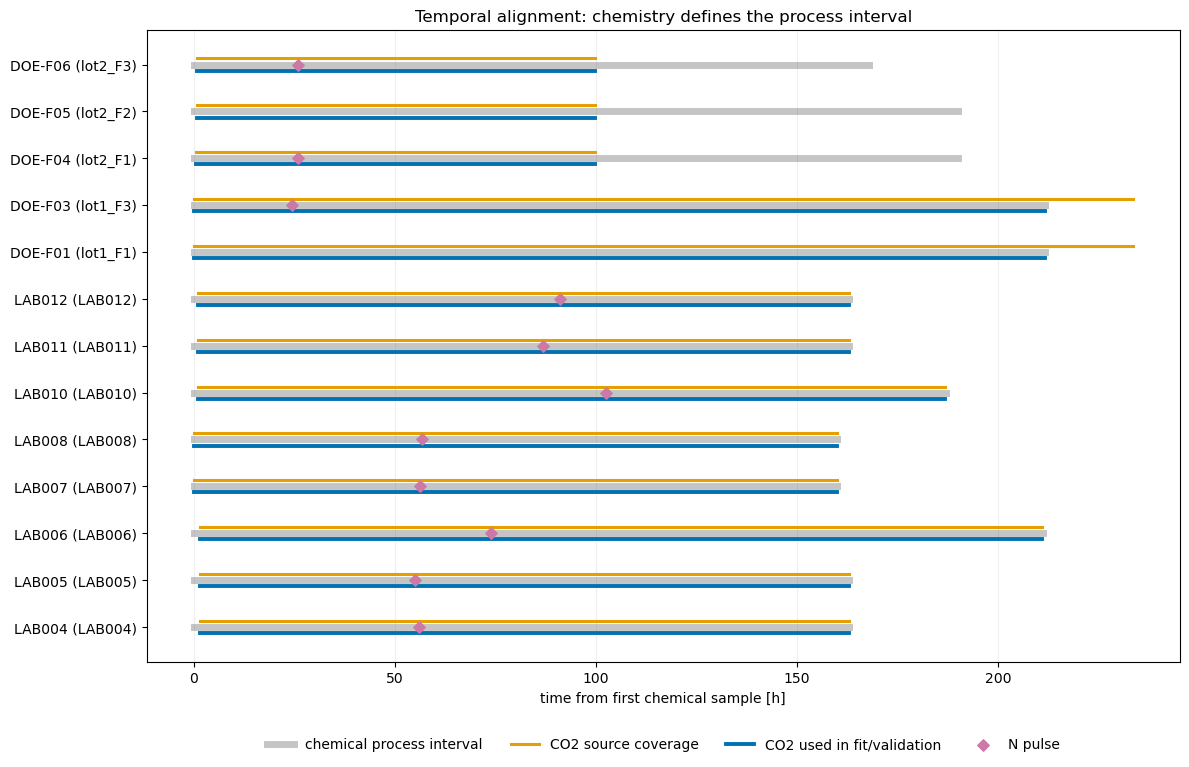

In [3]:
result = analysis.run_analysis(n_starts=5, max_nfev=300, seed=20260812)

# Correct the presentation-only inventory label. The underlying observations remain present
# so LAB010 can be evaluated with the fitted parameters frozen.
result["inventory"].loc[
    result["inventory"]["batch"].eq(SENSITIVITY_EXCLUDED_BATCH), "split"
] = "excluded_fit_frozen_diagnostic"
assert set(_historical._calibration_batch_names("natural", result["observations"])) == {
    "LAB004", "LAB005", "LAB006", "LAB007", "LAB008", "LAB011"
}
assert analysis.HOLDOUTS["natural"] == "LAB012"
print("Verified natural fitting batches:", _historical._calibration_batch_names("natural", result["observations"]))

display(result["exclusions"])
display(result["inventory"][[
    "matrix", "experiment_code", "batch", "lot", "calibratable", "split",
    "acquisition_channel", "sensor_id", "sensor_zero_offset_sccm",
    "n_co2_hourly", "chemistry_first_h", "chemistry_last_h", "co2_first_h",
    "co2_last_h", "co2_peak_g_l_h", "median_setpoint_c",
    "n_artifacts_replaced", "n_left_censored_hourly", "note"
]])
display(result["natural_nutrient_pulses"][[
    "batch", "calendar_t_h", "density_crossing_t_h", "density_bracket_width_h",
    "model_pulse_time_h", "timing_source", "amount_N_kg_m3",
    "calendar_product", "calendar_dose", "excluded_from_co2_analysis"
]])
fig = analysis.plot_process_timeline_alignment(
    result["inventory"], result["nutrient_pulses"], save=False
)
plt.show()

La separación se hace por fermentación completa. Los pulsos LAB aportan 0.14 kg N m⁻³; el pulso inicial se ignora porque el YAN inicial ya está en t=0. En todos los LAB con cruce disponible, el tiempo del pulso se obtiene por interpolación del cruce de densidad 1040 g/L. Un bracket químico >24 h se conserva, pero se etiqueta como incertidumbre de tiempo. En DOE-F0X se usa el tiempo de proceso existente, sin recalcularlo por densidad ni calendario.

## Filtrado y sensibilidad del sensor

,matrix,experiment_code,batch,acquisition_channel,sensor_id,sensor_zero_offset_sccm,sensor_zero_offset_g_l_h,median_setpoint_c,n_artifacts_replaced,n_sampling_window_transients,n_other_short_transients,negative_signed_fraction,n_left_censored_hourly,n_cold_low_sensitivity_hourly,smoothing_roughness_ratio,smoothing_integral_ratio,smoothing_peak_ratio
0,natural,LAB004,LAB004,F1,1,0.00000,0.000000,18.0,19,19,0,0.102911,65,0,0.304945,1.009568,0.915117
1,natural,LAB005,LAB005,F2,2,0.62066,0.025099,18.0,1,1,0,0.000000,43,0,0.219792,1.004438,0.988852
2,natural,LAB006,LAB006,F3,3,0.52838,0.021367,16.0,2,2,0,0.000000,71,0,0.263213,0.995662,0.962957
3,natural,LAB007,LAB007,F1,1,0.00000,0.000000,18.0,18,15,3,0.046875,60,0,0.403619,1.001061,0.889022
4,natural,LAB008,LAB008,F2,2,0.78048,0.031562,18.0,17,15,2,0.000000,47,0,0.416879,1.005046,0.863164
5,natural,LAB010,LAB010,F1,1,0.00000,0.000000,15.0,0,0,0,0.037273,101,100,0.379791,0.997475,0.993794
6,natural,LAB011,LAB011,F2,2,0.98992,0.040032,21.0,0,0,0,0.000000,85,45,0.416713,0.997368,0.988019
7,natural,LAB012,LAB012,F3,3,0.83948,0.033948,18.0,1,1,0,0.000000,63,52,0.460909,0.999966,0.976676
8,synthetic,DOE-F01,lot1_F1,F1,1,0.03998,0.002120,18.0,51,51,0,0.010236,35,0,0.167762,1.000070,0.880775
9,synthetic,DOE-F03,lot1_F3,F3,3,1.05890,0.056159,20.0,26,26,0,0.000000,57,0,0.208076,1.013734,0.992073


,matrix,batch,experiment_code,lot,acquisition_channel,sensor_id,sensor_assignment_source,zero_method,zero_window_h,zero_quantile,n_zero_candidates,initial_native_q10_sccm,estimated_zero_offset_sccm,estimated_zero_offset_g_l_h,initial_native_median_sccm,initial_corrected_q10_sccm,initial_corrected_median_sccm,sccm_conversion
0,natural,LAB004,LAB004,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00042,0.00000,0.000000,0.00000,-4.200000e-04,0.00000,SCCM_CORRECTED
1,natural,LAB005,LAB005,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.62066,0.62066,0.025099,0.72450,4.456071e-17,0.10384,SCCM_CORRECTED
2,natural,LAB006,LAB006,natural_2026,F3,3,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.52838,0.52838,0.021367,0.58710,4.453360e-17,0.05872,SCCM_CORRECTED
3,natural,LAB007,LAB007,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00038,0.00000,0.000000,0.00010,-3.800000e-04,0.00010,SCCM_CORRECTED
4,natural,LAB008,LAB008,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.78048,0.78048,0.031562,0.93975,2.320193e-17,0.15927,SCCM_CORRECTED
5,natural,LAB010,LAB010,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00492,0.00000,0.000000,0.00000,-4.920000e-03,0.00000,SCCM_CORRECTED
6,natural,LAB011,LAB011,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.98992,0.98992,0.040032,1.00820,-2.218549e-17,0.01828,SCCM_CORRECTED
7,natural,LAB012,LAB012,natural_2026,F3,3,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.83948,0.83948,0.033948,0.85040,2.228035e-17,0.01092,SCCM_CORRECTED
8,synthetic,lot1_F1,DOE-F01,MBDOE_lot1,F1,1,explicit DOE mapping; DOE-F06 label 6 is acqui...,initial_12h_q10,12.0,0.1,73,0.03998,0.03998,0.001658,0.15745,-8.673617e-19,0.11747,SCCM_CORRECTED
9,synthetic,lot1_F3,DOE-F03,MBDOE_lot1,F3,3,explicit DOE mapping; DOE-F06 label 6 is acqui...,initial_12h_q10,12.0,0.1,73,1.05890,1.05890,0.043919,1.20635,9.367507e-17,0.14745,SCCM_CORRECTED


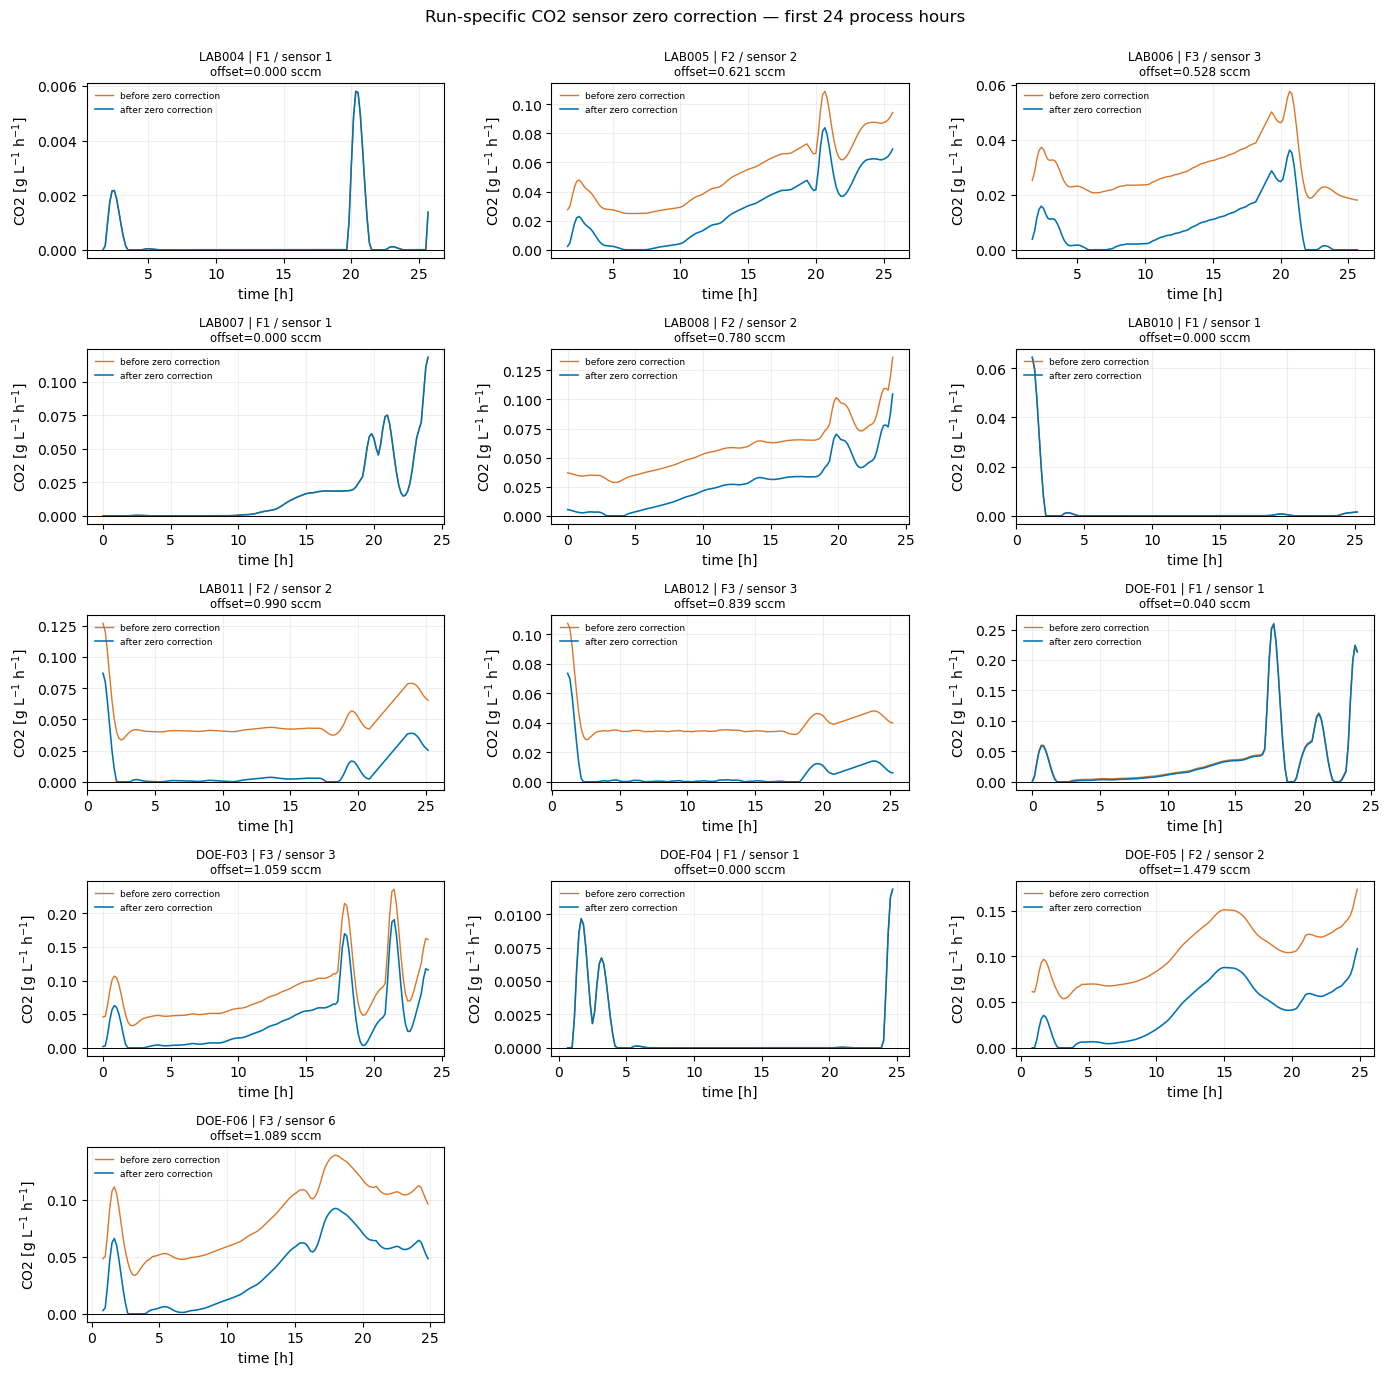

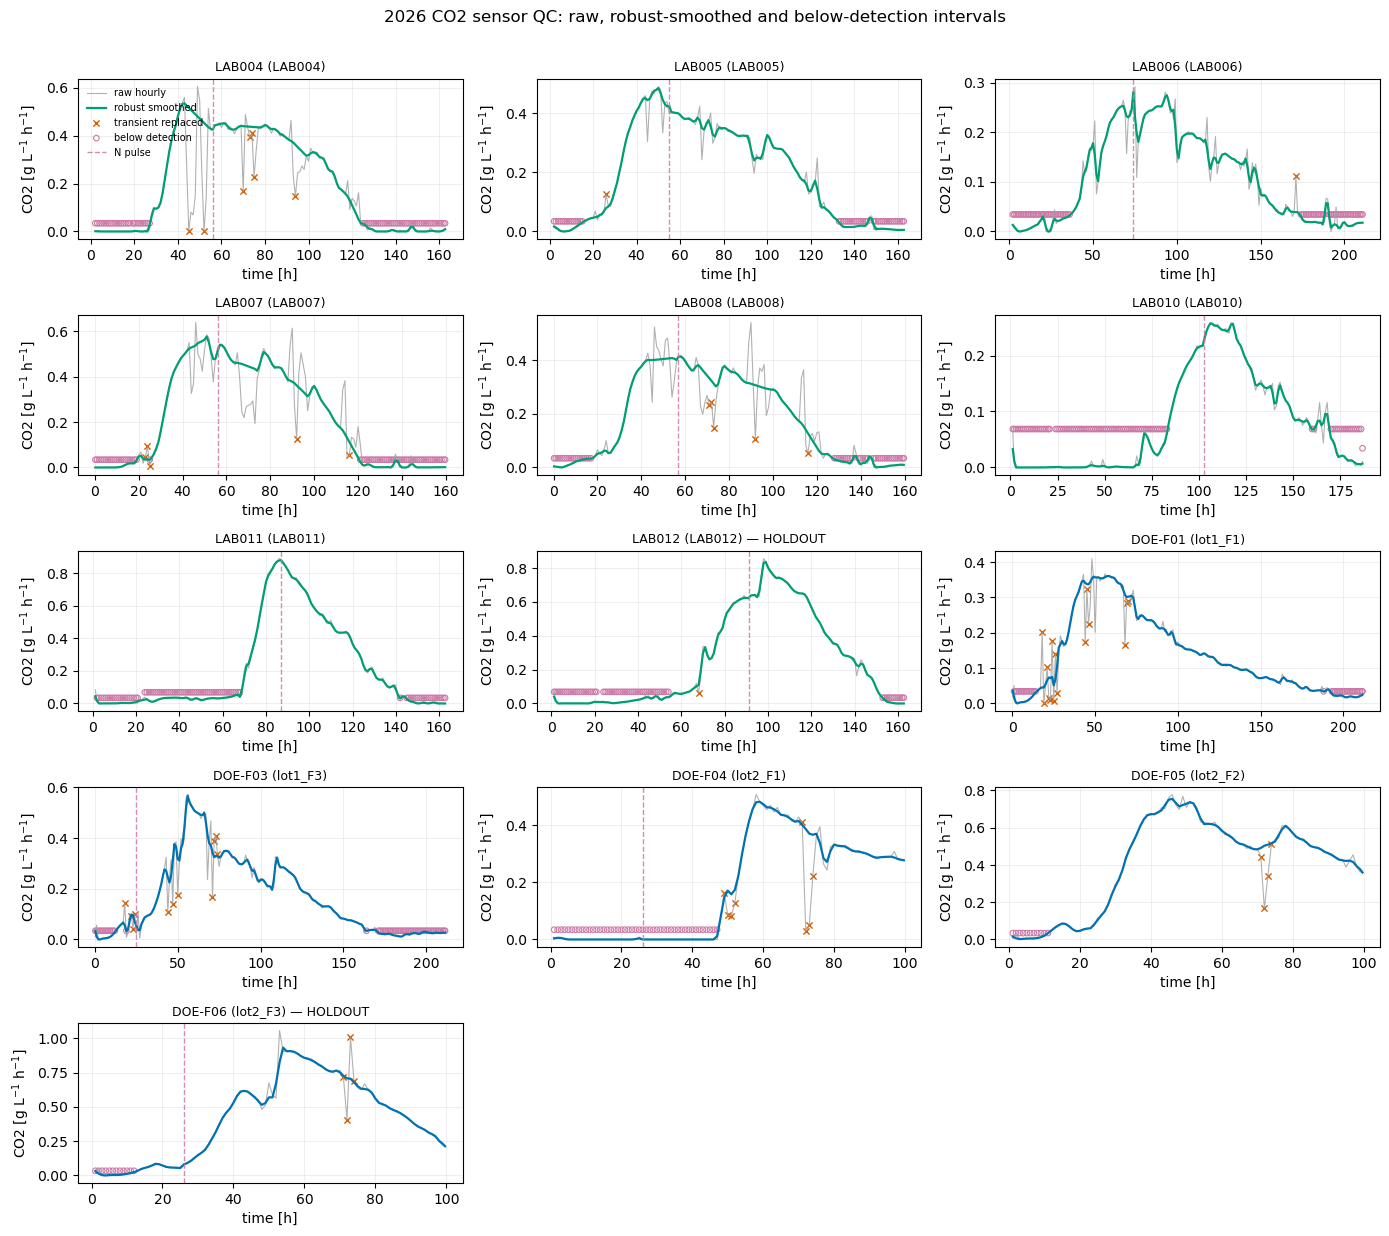

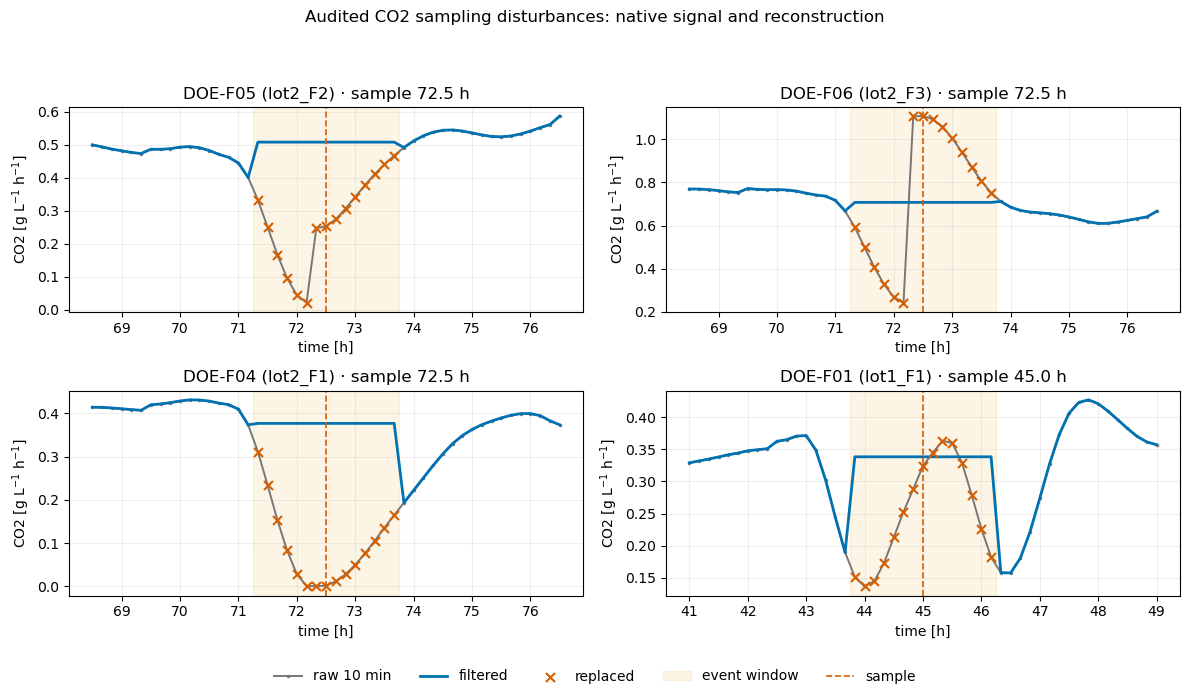

In [4]:
display(result["qc_summary"][[
    "matrix", "experiment_code", "batch", "acquisition_channel", "sensor_id",
    "sensor_zero_offset_sccm", "sensor_zero_offset_g_l_h", "median_setpoint_c",
    "n_artifacts_replaced", "n_sampling_window_transients",
    "n_other_short_transients", "negative_signed_fraction",
    "n_left_censored_hourly", "n_cold_low_sensitivity_hourly",
    "smoothing_roughness_ratio", "smoothing_integral_ratio", "smoothing_peak_ratio"
]])
display(result["sensor_zero_offsets"])
fig = analysis.plot_sensor_zero_correction(
    result["sensor_qc"], result["sensor_zero_offsets"], save=False
)
plt.show()
fig = analysis.plot_data_overview(
    result["observations"], result["nutrient_pulses"], save=False
)
plt.show()
fig = analysis.plot_sensor_filter_examples(
    result["sensor_qc"], result["sampling_schedule"],
    result["nutrient_pulses"], save=False
)
plt.show()

El primer gráfico comprueba la corrección de cero antes de cualquier reconstrucción. El offset se estima por corrida porque los canales muestran deriva entre campañas. Luego, las excursiones asociadas a muestreo se reconstruyen sólo cuando el evento completo está respaldado por niveles pre/post consistentes; se aplica mediana robusta de 3 h y Savitzky–Golay cuadrático de 5 h. Los puntos bajo el umbral local aportan una penalización unilateral si el modelo excede el límite.

## Temperatura y evidencia química de activación

,matrix,batch,temperature_used_min_c,temperature_used_mean_c,temperature_used_max_c,chemical_activity_lower_h,chemical_activity_upper_h,chemical_activity_center_h,initial_o2_saturation_base_mg_l,base_qprod_peak_g_l_h,csat_base_min_g_l,csat_base_max_g_l
0,natural,LAB004,17.7,19.266845,21.4,19.0,26.000000,22.500000,7.648403,0.358080,1.528572,1.957059
1,natural,LAB005,18.0,19.413936,21.4,0.0,19.000000,9.500000,7.497196,0.383042,1.490154,1.934773
2,natural,LAB006,16.0,17.030296,18.4,0.0,19.000000,9.500000,7.929510,0.288407,1.595673,2.090212
3,natural,LAB007,17.4,19.241498,21.1,0.0,16.000000,8.000000,7.497524,0.367365,1.510227,2.044642
4,natural,LAB008,17.4,19.195164,21.1,0.0,16.000000,8.000000,7.542804,0.380276,1.505889,1.873646
5,natural,LAB010,14.9,15.442991,16.5,0.0,72.000000,36.000000,8.146563,0.354771,1.665073,2.256914
6,natural,LAB011,14.9,18.842113,21.4,19.0,67.000000,43.000000,7.605382,0.433712,1.523275,2.076625
7,natural,LAB012,15.0,18.390505,21.2,0.0,48.000000,24.000000,8.150655,0.361827,1.662902,1.984255
8,synthetic,lot1_F1,17.6,18.107438,18.7,0.0,17.000000,8.500000,7.043979,0.407275,1.338996,2.012567
9,synthetic,lot1_F3,16.6,20.039876,23.0,0.0,17.000000,8.500000,7.792047,0.318327,1.507055,1.907763


,matrix,batch,experiment_code,n_temperature_comparisons,model_minus_sensor_bias_c,model_sensor_mae_c,model_sensor_rmse_c,model_sensor_max_abs_c
0,natural,LAB004,LAB004,162,0.006121,0.098508,0.142957,0.466667
1,natural,LAB005,LAB005,162,0.001800,0.038632,0.066050,0.250000
2,natural,LAB006,LAB006,209,0.022089,0.075518,0.131357,0.616667
3,natural,LAB007,LAB007,161,-0.005771,0.107531,0.259512,2.133333
4,natural,LAB008,LAB008,161,0.002277,0.058799,0.147161,1.500000
5,natural,LAB010,LAB010,184,0.017346,0.063089,0.095622,0.333333
6,natural,LAB011,LAB011,160,0.015964,0.081172,0.193215,1.866667
7,natural,LAB012,LAB012,160,0.019010,0.066146,0.148282,1.300000
8,synthetic,lot1_F1,DOE-F01,213,0.015258,0.261268,0.330510,0.800000
9,synthetic,lot1_F3,DOE-F03,213,-0.014554,0.093427,0.164445,0.700000


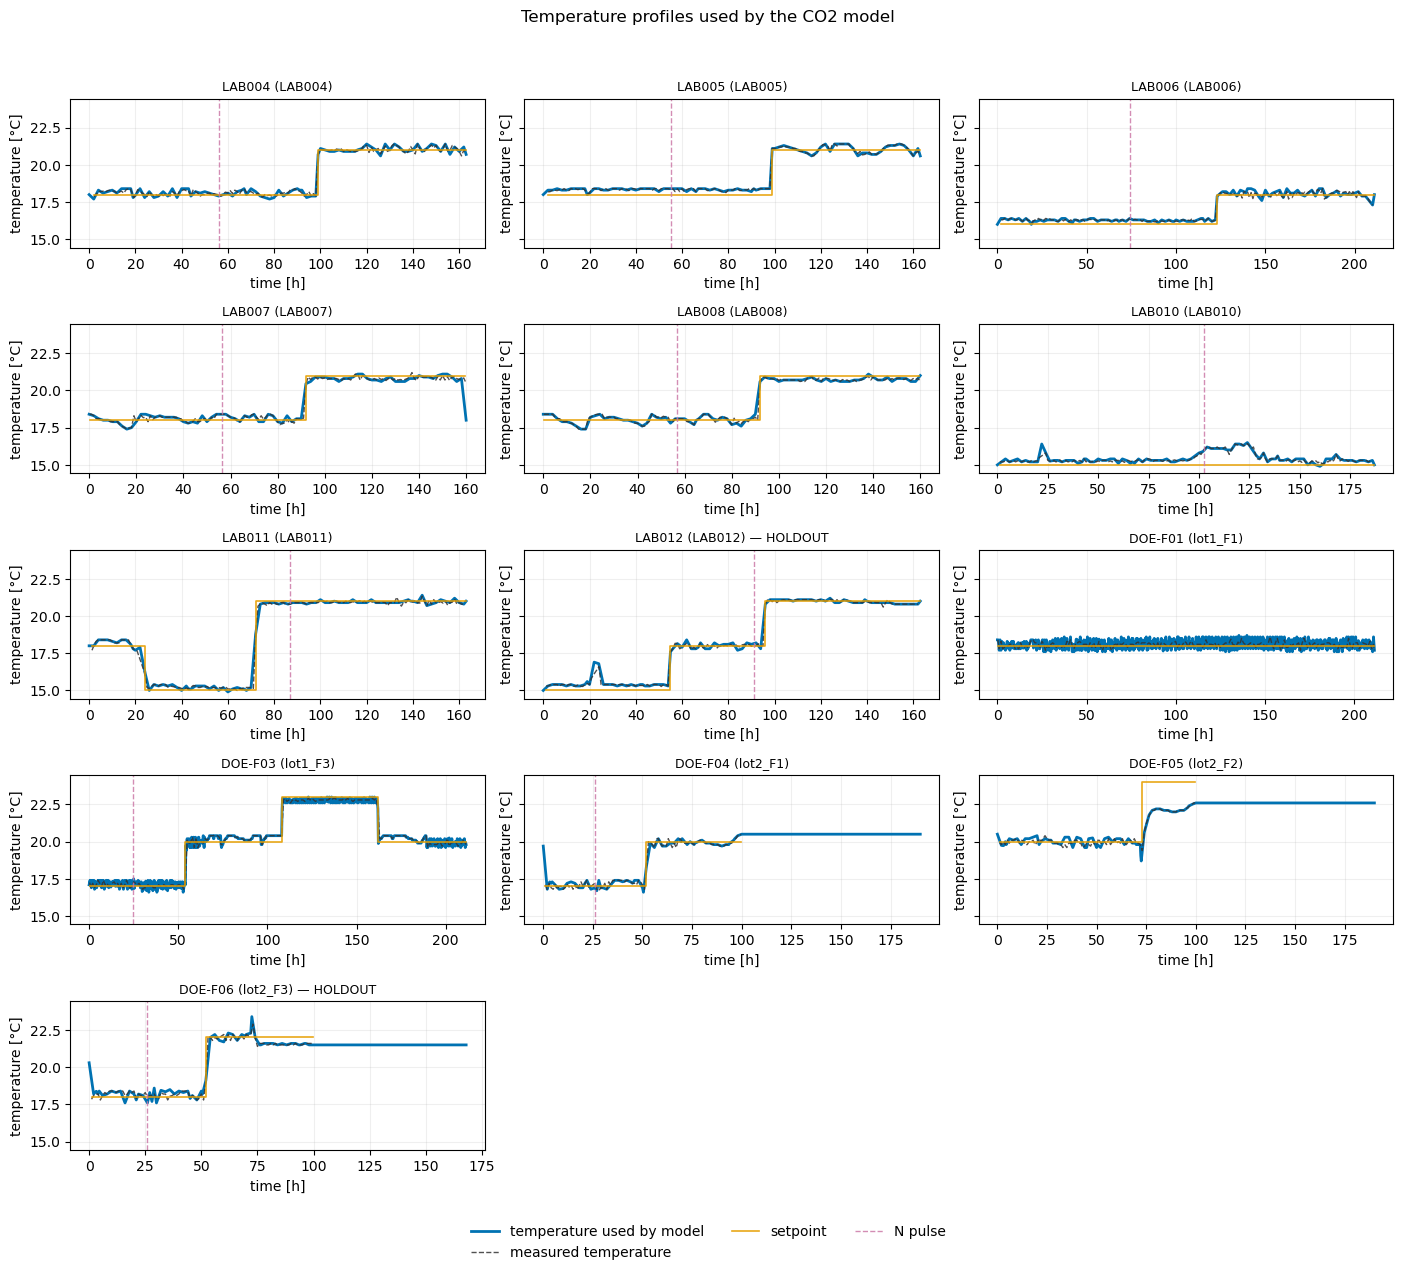

In [5]:
display(result["driver_diagnostics"][[
    "matrix", "batch", "temperature_used_min_c", "temperature_used_mean_c",
    "temperature_used_max_c", "chemical_activity_lower_h",
    "chemical_activity_upper_h", "chemical_activity_center_h",
    "initial_o2_saturation_base_mg_l", "base_qprod_peak_g_l_h",
    "csat_base_min_g_l", "csat_base_max_g_l"
]])
display(result["temperature_alignment"])
fig = analysis.plot_temperature_profiles(
    result["observations"], result["temperature_inputs"],
    result["nutrient_pulses"], save=False
)
plt.show()

La temperatura medida/reconstruida entra tanto a los drivers cinéticos como a la solubilidad de CO₂; el setpoint queda como referencia. La tabla permite verificar, lote por lote, el intervalo químico que condiciona el encendido de la fuente.

## Auditoría obligatoria de theta y SCCM

Esta celda se ejecuta después de construir los drivers; si cualquiera de los tres CSV no contiene
exactamente los 17 parámetros esperados, el runner falla antes de la primera simulación. La tabla de
reconstrucción identifica las seis filas que históricamente provenían de `DEFAULT_THETA`.

In [6]:
display(result["theta_validation_summary"])
display(result["theta_historical_audit"])
print("SCCM_CORRECTED [g/L/h/SCCM]:", result["manifest"]["sccm_conversion"]["factor_g_l_h_per_sccm_at_2L"])
print("Historical baseline reproduced:")
display(result["historical_reproduction_audit"])

,theta_label,csv_path,parameter_count,expected_count,all_17_present,sha256,simulation_use
0,natural,laboratory_2026/results/estimability_historica...,17,17,True,3876c53d0b4dc6f4126ffb4f8e0999a8455c90f283c345...,target natural batches
1,synthetic,laboratory_2026/results/estimability_historica...,17,17,True,009200460549b461dd46bf31b5d4aded36b2d99eed53c5...,target synthetic batches
2,joint,shared/results/new_must_glycerol_overnight_val...,17,17,True,146185f5d070c58b309a4b8ab492848a3326e243509c28...,validated reference only; original cross-matri...


,matrix,parameter,historical_load_mode,historical_value,complete_theta_value,absolute_change,historical_csv
0,natural,mu0,serialized_csv,0.078728,0.078728,0.000000,laboratory_2026/results/estimability_historica...
1,natural,sN,DEFAULT_THETA_fallback,18.000000,8.751446,-9.248554,laboratory_2026/results/estimability_historica...
2,natural,qN,serialized_csv,0.021080,0.021080,0.000000,laboratory_2026/results/estimability_historica...
3,natural,qXG,DEFAULT_THETA_fallback,0.112500,0.081491,-0.031009,laboratory_2026/results/estimability_historica...
4,natural,qXF,DEFAULT_THETA_fallback,0.112500,0.070933,-0.041567,laboratory_2026/results/estimability_historica...
5,natural,betaG0,serialized_csv,0.428878,0.428878,0.000000,laboratory_2026/results/estimability_historica...
6,natural,sG,DEFAULT_THETA_fallback,0.030000,0.097455,0.067455,laboratory_2026/results/estimability_historica...
7,natural,betaF0,serialized_csv,3.440399,3.440399,0.000000,laboratory_2026/results/estimability_historica...
8,natural,sF,DEFAULT_THETA_fallback,0.030000,0.178295,0.148295,laboratory_2026/results/estimability_historica...
9,natural,qEG,serialized_csv,1.712807,1.712807,0.000000,laboratory_2026/results/estimability_historica...


SCCM_CORRECTED [g/L/h/SCCM]: 0.0404391928807947
Historical baseline reproduced:


,quantity,n_rows,max_absolute_difference,mean_absolute_difference
0,observed_g_l_h,4178,4.558383e-01,4.633913e-03
1,predicted_g_l_h,4178,5.551115e-16,3.924626e-17
2,raw_model_qgas_g_l_h,4178,3.053113e-16,3.825356e-17


## Comparación explícita A/B/C

A→B cuantifica solo el reemplazo del theta. B→C cuantifica la readaptación de la capa CO₂. A→C es
el efecto final. La descomposición escala/forma ajusta únicamente un multiplicador diagnóstico entre
dos curvas ya calculadas; no modifica B ni constituye un refit. Un valor alto de la fracción explicada
por escala indica cambio mayormente multiplicativo.

,state,matrix,wsse_equal_batch_fixed_co2,n_residuals,matrix_gain,co2_refitted
0,A_historical,synthetic,19.515601,632,1.459910,False
1,A_historical,natural,18.814777,1029,2.139011,False
2,A_historical,all,38.330378,1661,NaN,False
3,B_full_theta_no_refit,synthetic,27.810253,632,1.459910,False
4,B_full_theta_no_refit,natural,38.154928,1029,2.139011,False
5,B_full_theta_no_refit,all,65.965181,1661,NaN,False
6,C_full_theta_refit,synthetic,18.908940,632,1.149648,True
7,C_full_theta_refit,natural,15.959851,1029,1.602222,True
8,C_full_theta_refit,all,34.868791,1661,NaN,True


,transition,left_state,right_state,calibration_matrix,parameter,left_estimate,right_estimate,absolute_change,percent_change,left_active_bound,right_active_bound
0,A_to_B,A_historical,B_full_theta_no_refit,synthetic,kCO2_release_h,3.883746,3.883746,0.000000e+00,0.000000e+00,False,False
1,A_to_B,A_historical,B_full_theta_no_refit,synthetic,CO2sat_scale,0.425408,0.425408,0.000000e+00,0.000000e+00,False,False
2,A_to_B,A_historical,B_full_theta_no_refit,synthetic,O2_qmax_mg_gdw_h,0.150164,0.150164,0.000000e+00,0.000000e+00,True,True
3,A_to_B,A_historical,B_full_theta_no_refit,synthetic,O2_initial_scale,0.380416,0.380416,0.000000e+00,0.000000e+00,False,False
4,A_to_B,A_historical,B_full_theta_no_refit,synthetic,pulse_t_rise_h,36.500023,36.500023,0.000000e+00,0.000000e+00,False,False
5,A_to_B,A_historical,B_full_theta_no_refit,synthetic,pulse_activity_gain,1.233338,1.233338,0.000000e+00,0.000000e+00,False,False
6,A_to_B,A_historical,B_full_theta_no_refit,synthetic,chem_activation_start_fraction,0.010004,0.010004,0.000000e+00,0.000000e+00,True,True
7,A_to_B,A_historical,B_full_theta_no_refit,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.000000e+00,0.000000e+00,True,True
8,A_to_B,A_historical,B_full_theta_no_refit,synthetic,matrix_gain,1.459910,1.459910,0.000000e+00,0.000000e+00,False,False
9,A_to_B,A_historical,B_full_theta_no_refit,natural,kCO2_release_h,0.424382,0.424382,0.000000e+00,0.000000e+00,False,False


,matrix,historical_matrix_gain,refit_matrix_gain,absolute_change,percent_change,direct_raw_integral_ratio_B_over_A,gain_ratio_C_over_A,gain_only_compensated_ratio_to_A,other_co2_layer_raw_ratio_C_over_B,final_scaled_integral_ratio_C_over_A,interpretation_guardrail
0,synthetic,1.459910,1.149648,-0.310262,-21.252106,1.279092,0.787479,1.007258,1.002452,1.009727,matrix_gain is an empirical observation/scale ...
1,natural,2.139011,1.602222,-0.536789,-25.095189,1.223072,0.749048,0.916140,1.055845,0.967302,matrix_gain is an empirical observation/scale ...


,state,model,calibration_matrix,target_matrix,batch,experiment_code,role,n,n_total,n_left_censored,rmse_g_l_h,mae_g_l_h,bias_g_l_h,nrmse_peak,correlation,r2,observed_peak_g_l_h,predicted_peak_g_l_h,observed_peak_time_h,predicted_peak_time_h,...,observed_onset_h,predicted_onset_h,onset_delay_h,visual_rise_low_threshold_g_l_h,visual_rise_high_threshold_g_l_h,observed_visual_rise_low_h,observed_visual_rise_high_h,observed_visual_rise_duration_h,predicted_first_emission_0p005_h,predicted_visual_rise_low_h,predicted_visual_rise_high_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,pulse_time_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,observed_pulse_t_rise_h,predicted_pulse_t_rise_h,postpulse_peak_delay_h,scenario
0,A_historical,solubility_o2_nitrogen_boost_continuous_release,synthetic,natural,LAB012,LAB012,cross_holdout,98,161,63,0.262905,0.221831,-0.134862,0.314682,0.391021,-0.199708,0.835463,0.332797,99.0,58.0,...,65.156714,14.756717,-50.399997,0.017140,0.083942,37.845148,65.156714,27.311566,6.276060,9.600226,14.756717,5.156491,-22.155075,91.041739,99.0,102.0,7.958261,10.958261,3.0,cross_matrix_holdout
1,A_historical,solubility_o2_nitrogen_boost_continuous_release,natural,natural,LAB012,LAB012,internal_holdout,98,161,63,0.218546,0.186302,-0.142275,0.261587,0.776977,0.170979,0.835463,0.430035,99.0,88.0,...,65.156714,54.596062,-10.560652,0.017140,0.083942,37.845148,65.156714,27.311566,43.711819,47.633718,54.596062,6.962344,-20.349222,91.041739,99.0,92.0,7.958261,0.958261,-7.0,within_matrix_holdout
2,A_historical,solubility_o2_nitrogen_boost_continuous_release,natural,synthetic,lot2_F3,DOE-F06,cross_holdout,88,100,12,0.223794,0.197371,-0.197371,0.240241,0.963349,0.314353,0.931537,0.621052,54.0,56.0,...,27.509842,30.380292,2.870450,0.024555,0.098594,12.030648,27.509842,15.479194,23.365046,26.664162,30.380292,3.716130,-11.763064,26.000000,54.0,56.0,28.000000,30.000000,2.0,cross_matrix_holdout
3,A_historical,solubility_o2_nitrogen_boost_continuous_release,synthetic,synthetic,lot2_F3,DOE-F06,internal_holdout,88,100,12,0.167725,0.130063,-0.104597,0.180052,0.876565,0.614877,0.931537,0.788604,54.0,54.0,...,27.509842,36.311061,8.801219,0.024555,0.098594,12.030648,27.509842,15.479194,9.141964,20.012238,36.311061,16.298823,0.819629,26.000000,54.0,54.0,28.000000,28.000000,0.0,within_matrix_holdout
4,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,synthetic,natural,LAB012,LAB012,cross_holdout,98,161,63,0.335821,0.304067,-0.137711,0.401958,0.088301,-0.957462,0.835463,0.522447,99.0,62.0,...,65.156714,13.579615,-51.577099,0.017140,0.083942,37.845148,65.156714,27.311566,5.741412,8.735032,13.579615,4.844583,-22.466983,91.041739,99.0,97.0,7.958261,5.958261,-2.0,cross_matrix_holdout
5,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,natural,natural,LAB012,LAB012,internal_holdout,98,161,63,0.277885,0.247957,-0.098792,0.332612,0.455391,-0.340319,0.835463,0.694367,99.0,84.0,...,65.156714,52.120948,-13.035766,0.017140,0.083942,37.845148,65.156714,27.311566,42.864890,46.272071,52.120948,5.848877,-21.462689,91.041739,99.0,92.0,7.958261,0.958261,-7.0,within_matrix_holdout
6,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,natural,synthetic,lot2_F3,DOE-F06,cross_holdout,88,100,12,0.119524,0.103237,-0.103237,0.128308,0.974928,0.804424,0.931537,0.873465,54.0,56.0,...,27.509842,29.605333,2.095491,0.024555,0.098594,12.030648,27.509842,15.479194,23.012975,26.116792,29.605333,3.488541,-11.990653,26.000000,54.0,56.0,28.000000,30.000000,2.0,cross_matrix_holdout
7,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,synthetic,synthetic,lot2_F3,DOE-F06,internal_holdout,88,100,12,0.187509,0.163438,0.031197,0.201290,0.876038,0.518661,0.931537,1.129665,54.0,55.0,...,27.509842,35.054008,7.544166,0.024555,0.098594,12.030648,27.509842,15.479194,8.653681,16.321836,35.054008,18.732173,3.252979,26.000000,54.0,55.0,28.000000,29.000000,1.0,within_matrix_holdout
8,C_full_the

,transition,calibration_matrix,target_matrix,batch,experiment_code,role,best_multiplicative_scale_right_from_left,direct_prediction_rmse_g_l_h,shape_rmse_after_best_scale_g_l_h,fraction_squared_change_explained_by_scale,prediction_shape_correlation,integral_ratio_right_over_left,peak_ratio_right_over_left,peak_time_change_h
25,A_to_B,synthetic,synthetic,lot2_F3,DOE-F06,internal_holdout,1.399733,0.167979,0.029028,0.970138,0.997571,1.377660,1.432486,1.000000
20,A_to_B,synthetic,natural,LAB012,LAB012,cross_holdout,1.129163,0.154304,0.150290,0.051359,0.736814,1.066709,1.408680,37.916667
14,A_to_B,synthetic,natural,LAB005,LAB005,cross_context,1.219750,0.150798,0.136123,0.185160,0.797309,1.165712,1.579440,0.000000
19,A_to_B,synthetic,natural,LAB011,LAB011,cross_context,1.051904,0.146463,0.145903,0.007629,0.773875,0.943796,1.686524,0.000000
18,A_to_B,synthetic,natural,LAB010,LAB010,cross_context,1.111592,0.134557,0.131794,0.040657,0.808283,1.013299,1.357909,0.000000
13,A_to_B,synthetic,natural,LAB004,LAB004,cross_context,1.183436,0.133394,0.124979,0.122191,0.800095,1.120145,1.504195,-9.000000
16,A_to_B,synthetic,natural,LAB007,LAB007,cross_context,1.284087,0.131232,0.109064,0.309310,0.839486,1.244887,1.660656,2.000000
17,A_to_B,synthetic,natural,LAB008,LAB008,cross_context,1.281728,0.131176,0.109175,0.307316,0.849425,1.238628,1.663016,0.000000
7,A_to_B,natural,natural,LAB012,LAB012,internal_holdout,1.276146,0.130136,0.112759,0.249223,0.904590,1.143502,1.614675,-4.000000
1,A_to_B,natural,natural,LAB005,LAB005,calibration,1.384736,0.128263,0.077799,0.632090,0.967485,1.270639,1.404641,0.000000


,state,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,A_historical,synthetic,632,8,8,2.924571e+07,2.660739e-07,7.781522,0.031275,ill_conditioned
1,A_historical,natural,1029,8,8,7.937670e+01,7.211155e-02,5.723977,0.018405,moderate_or_better
2,C_full_theta_refit,synthetic,632,8,8,9.076098e+10,3.373549e-08,3061.865826,0.030303,ill_conditioned
3,C_full_theta_refit,natural,1029,8,8,2.154967e+04,5.115635e-02,1102.402405,0.015632,ill_conditioned


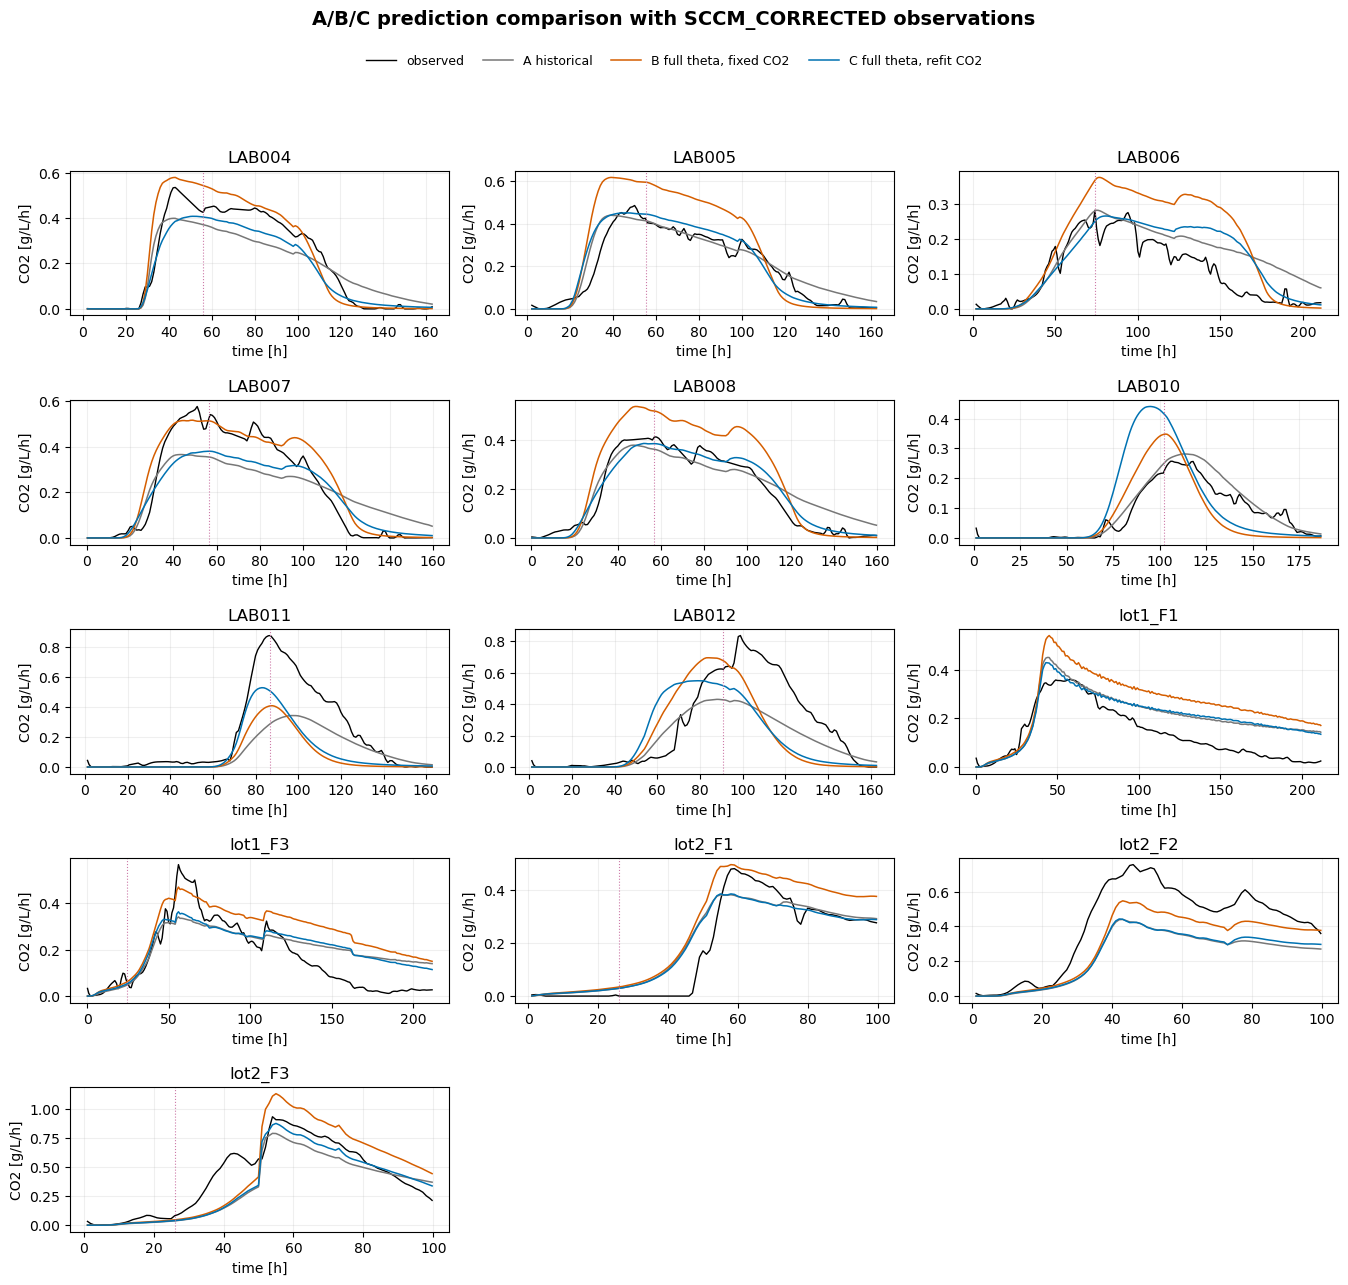

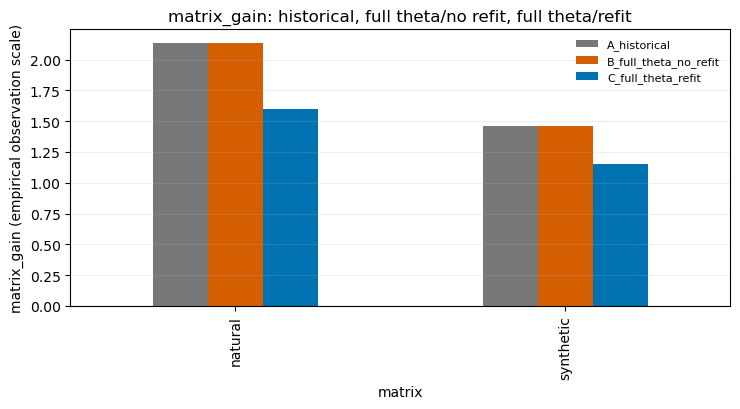

In [7]:
display(result["state_objectives"])
display(result["state_parameter_changes"])
display(result["matrix_gain_compensation"])
display(result["state_validation"])
display(
    result["pairwise_shape_scale"]
    .query("transition == 'A_to_B'")
    .sort_values("direct_prediction_rmse_g_l_h", ascending=False)
)
display(result["identifiability_state_comparison"])
fig = analysis.plot_three_state_overlays(result["state_predictions"], save=False)
plt.show()
fig = analysis.plot_matrix_gain_three_states(result["state_parameters"], save=False)
plt.show()

## Estado C — recalibración CO₂ por matriz con theta completo congelado

,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
0,synthetic,kCO2_release_h,6.118870,0.03,25.00,False,2.092799e-01
1,synthetic,CO2sat_scale,0.606169,0.35,2.50,False,2.793459e-01
2,synthetic,O2_qmax_mg_gdw_h,0.150032,0.15,6.00,True,5.856736e-05
3,synthetic,O2_initial_scale,0.359185,0.05,1.50,False,4.202587e-01
4,synthetic,pulse_t_rise_h,35.314587,1.00,72.00,False,1.665713e-01
5,synthetic,pulse_activity_gain,1.197615,0.25,4.00,False,4.349590e-01
6,synthetic,chem_activation_start_fraction,0.010000,0.01,0.95,True,3.507122e-09
7,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,3.955875e-10
8,synthetic,matrix_gain,1.149648,0.10,20.00,False,4.609088e-01
9,natural,kCO2_release_h,0.278349,0.03,25.00,False,3.312320e-01


,matrix,success,nfev,wsse_equal_batch,kCO2_release_h,CO2sat_scale,O2_qmax_mg_gdw_h,O2_initial_scale,pulse_t_rise_h,pulse_activity_gain,chem_activation_start_fraction,chem_activation_duration_fraction,matrix_gain
0,natural,True,37,15.959851,0.278349,2.498908,0.253137,0.179606,56.741847,0.250011,0.741575,0.457773,1.602222
1,synthetic,True,44,18.908940,6.118870,0.606169,0.150032,0.359185,35.314587,1.197615,0.010000,0.350000,1.149648


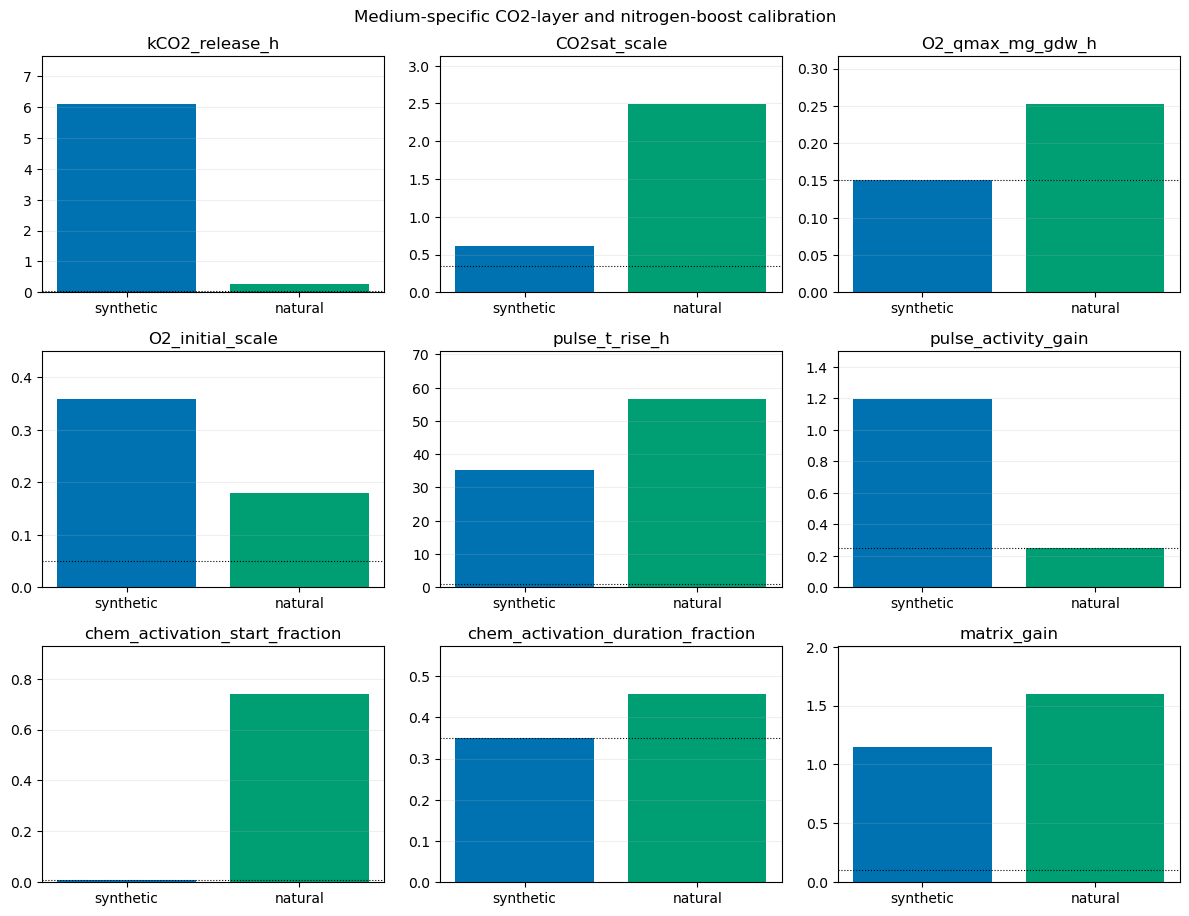

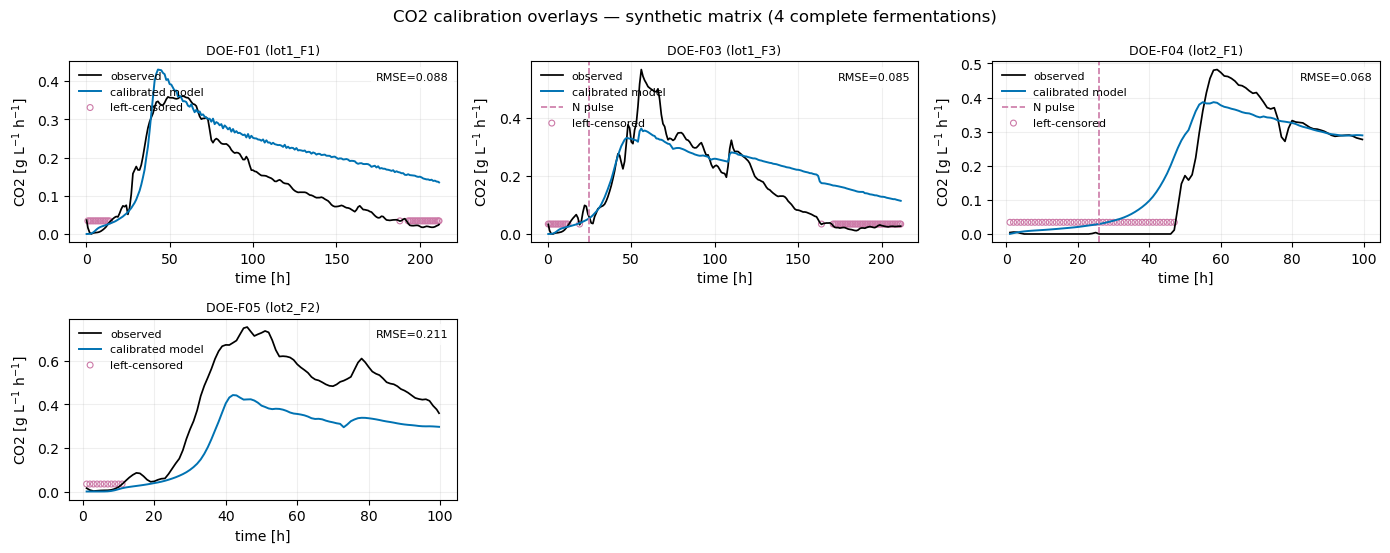

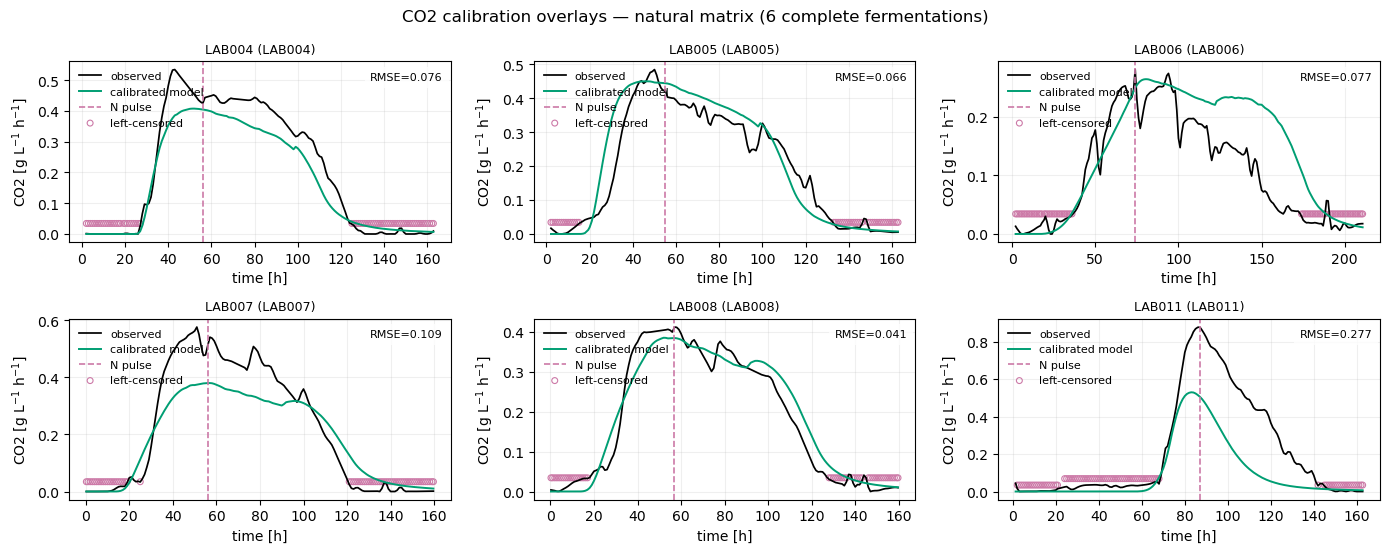

In [8]:
display(result["fit_parameters"])
best_starts = (
    result["fit_starts"].sort_values("wsse_equal_batch")
    .groupby("matrix", as_index=False).first()
)
display(best_starts[[
    "matrix", "success", "nfev", "wsse_equal_batch", "kCO2_release_h",
    "CO2sat_scale", "O2_qmax_mg_gdw_h", "O2_initial_scale",
    "pulse_t_rise_h", "pulse_activity_gain",
    "chem_activation_start_fraction", "chem_activation_duration_fraction",
    "matrix_gain"
]])
fig = analysis.plot_parameter_comparison(result["fit_parameters"], save=False)
plt.show()
for matrix in ("synthetic", "natural"):
    fig = analysis.plot_calibration_overlays(result["predictions"], matrix, save=False)
    plt.show()

`active_bound=True` indica que el dato sólo acota el parámetro en el borde permitido. Debe leerse como tensión estructural o falta de identificabilidad, no como una estimación interior resuelta. `chem_activation_start_fraction` ubica el inicio dentro del bracket químico y `chem_activation_duration_fraction` escala la duración por el ancho de ese bracket. `pulse_activity_gain=1` significa ausencia de modulación sobre la actividad preexistente; >1 es boost y <1 es atenuación.

En esta sección todos los estimates corresponden al estado C. Los estados A y B comparten exactamente los parámetros CO₂ históricos; B no ejecuta fitting.

## Estimabilidad de inicio y duración

,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,synthetic,632,8,8,9.076098e+10,3.373549e-08,3061.865826,0.030303,ill_conditioned
1,natural,1029,8,8,2.154967e+04,5.115635e-02,1102.402405,0.015632,ill_conditioned


,matrix,parameter_1,parameter_2,local_log_parameter_correlation
126,natural,chem_activation_duration_fraction,chem_activation_start_fraction,-0.981824
125,natural,chem_activation_duration_fraction,pulse_activity_gain,0.036518
123,natural,chem_activation_duration_fraction,O2_initial_scale,0.075471
122,natural,chem_activation_duration_fraction,O2_qmax_mg_gdw_h,0.083225
124,natural,chem_activation_duration_fraction,pulse_t_rise_h,0.108805
121,natural,chem_activation_duration_fraction,CO2sat_scale,0.399192
120,natural,chem_activation_duration_fraction,kCO2_release_h,0.441572
127,natural,chem_activation_duration_fraction,chem_activation_duration_fraction,1.000000
119,natural,chem_activation_start_fraction,chem_activation_duration_fraction,-0.981824
112,natural,chem_activation_start_fraction,kCO2_release_h,-0.457673


,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,natural,chem_activation_start_fraction,0.741575,0.637447,0.753604,0.796561,1.591143e-01,2.145627e-01,6,0,0
1,natural,chem_activation_duration_fraction,0.457773,0.350000,0.403928,1.737068,1.387068e+00,3.030031e+00,6,3,0
2,synthetic,chem_activation_start_fraction,0.010000,0.010000,0.010000,0.010000,1.687858e-11,1.687858e-09,4,4,0
3,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,3.516015e-11,1.004576e-10,4,4,0


,matrix,omitted_batch,success,nfev,chem_activation_start_fraction,chem_activation_duration_fraction
0,synthetic,lot1_F1,True,29,0.010000,0.350000
1,synthetic,lot1_F3,True,31,0.010000,0.350000
2,synthetic,lot2_F1,True,25,0.010000,0.350000
3,synthetic,lot2_F2,True,28,0.010000,0.350000
4,natural,LAB004,True,36,0.787968,0.350000
5,natural,LAB005,True,26,0.796561,0.350083
6,natural,LAB006,True,18,0.765634,0.350000
7,natural,LAB007,True,16,0.741573,0.457773
8,natural,LAB008,True,13,0.741575,0.457773
9,natural,LAB011,True,25,0.637447,1.737068


,matrix,profiled_parameter,fixed_value,wsse_equal_batch,success,nfev,full_fit_estimate,delta_wsse,relative_wsse_increase
0,natural,chem_activation_duration_fraction,0.350000,16.030469,True,20,0.457773,7.061758e-02,4.424702e-03
1,natural,chem_activation_duration_fraction,0.457773,15.959851,True,11,0.457773,0.000000e+00,0.000000e+00
2,natural,chem_activation_duration_fraction,0.467981,16.052104,True,7,0.457773,9.225334e-02,5.780338e-03
3,natural,chem_activation_duration_fraction,0.625732,16.030079,True,14,0.457773,7.022838e-02,4.400315e-03
4,natural,chem_activation_duration_fraction,0.836660,16.202471,True,24,0.457773,2.426199e-01,1.520189e-02
5,natural,chem_activation_duration_fraction,1.118689,16.557784,True,24,0.457773,5.979330e-01,3.746483e-02
6,natural,chem_activation_duration_fraction,1.495787,17.115314,True,30,0.457773,1.155463e+00,7.239809e-02
7,natural,chem_activation_duration_fraction,2.000000,17.963384,True,30,0.457773,2.003533e+00,1.255358e-01
8,natural,chem_activation_start_fraction,0.010000,18.361035,True,24,0.741575,2.418760e+00,1.517199e-01
9,natural,chem_activation_start_fraction,0.166667,17.565568,True,24,0.741575,1.623293e+00,1.018232e-01


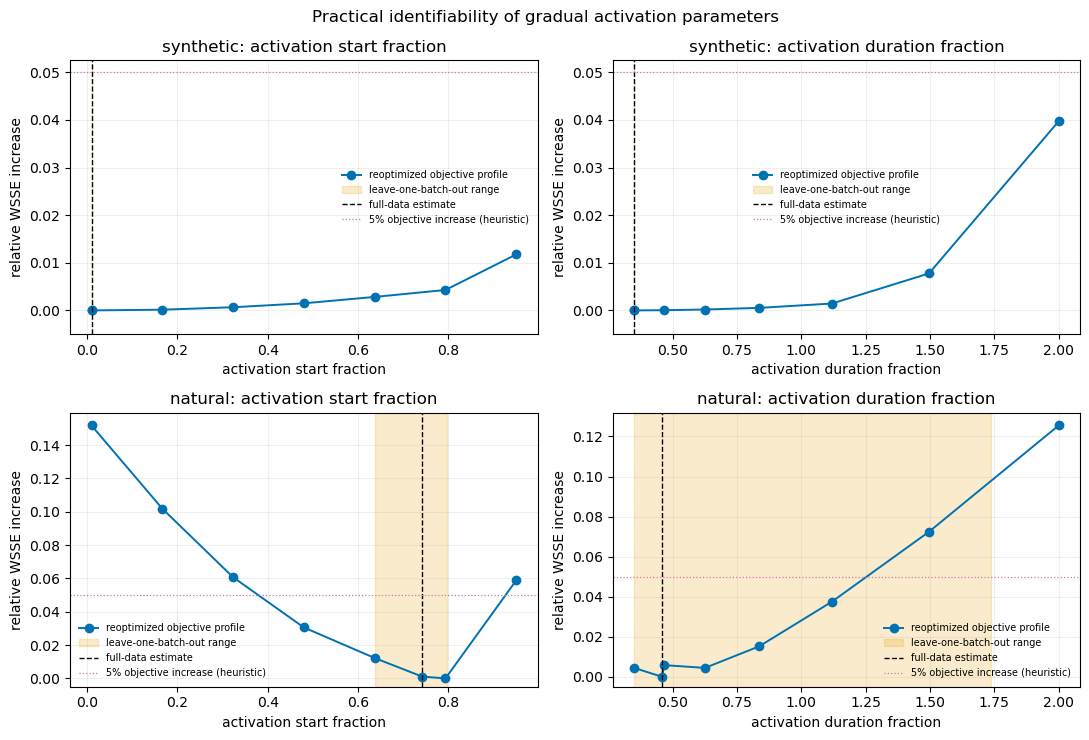

In [9]:
display(result["jacobian_identifiability"])
display(
    result["local_parameter_correlations"].query(
        "parameter_1 in ['chem_activation_start_fraction', 'chem_activation_duration_fraction']"
    )[["matrix", "parameter_1", "parameter_2", "local_log_parameter_correlation"]]
    .sort_values(["matrix", "parameter_1", "local_log_parameter_correlation"])
)
display(result["loo_activation_summary"])
display(result["loo_activation_estimates"][[
    "matrix", "omitted_batch", "success", "nfev",
    "chem_activation_start_fraction", "chem_activation_duration_fraction"
]])
display(result["activation_profiles"])
fig = analysis.plot_activation_identifiability(
    result["activation_profiles"], result["loo_activation_summary"], save=False
)
plt.show()

El Jacobiano evalúa sensibilidad local en log-parámetros; un número de condición alto indica direcciones compensables. Los perfiles fijan uno de los dos parámetros y reoptimizan todos los demás. La franja naranjo muestra cuánto cambia la estimación al retirar una fermentación completa. La línea horizontal de 5 % es sólo un umbral descriptivo de sensibilidad del objetivo, no un intervalo de confianza de verosimilitud.

La identificabilidad se compara entre A y C, ambos óptimos de calibración. No se atribuye identificabilidad a B porque deliberadamente no es un óptimo.

## ¿Se corrigió la cola inicial?

,target_matrix,experiment_code,batch,median_setpoint_c,cold_operation,chemical_activity_lower_h,chemical_activity_upper_h,source_10pct_peak_onset_h,o2_below_anaerobic_halfpoint_h,observed_onset_h,predicted_onset_h,onset_delay_h,O2_qmax_mg_gdw_h,O2_initial_scale,n_pulse_time_h,pulse_t_rise_h,pulse_activity_gain,chem_activation_start_fraction,chem_activation_duration_fraction,pulse_utilization_complete_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
8,synthetic,DOE-F01,lot1_F1,18.0,False,0.0,17.000000,20.00,36.25,16.399541,20.334196,3.934655,0.150032,0.359185,NaN,35.314587,1.197615,0.010000,0.350000,NaN,NaN,NaN,NaN
9,synthetic,DOE-F03,lot1_F3,20.0,False,0.0,17.000000,17.50,37.75,20.640551,26.640831,6.000280,0.150032,0.359185,24.500000,35.314587,1.197615,0.010000,0.350000,59.814587,56.0,56.0,0.0
10,synthetic,DOE-F04,lot2_F1,17.0,False,0.0,3.174722,28.75,44.75,47.547195,32.802113,-14.745083,0.150032,0.359185,26.000000,35.314587,1.197615,0.010000,0.350000,61.314587,59.0,58.0,-1.0
11,synthetic,DOE-F05,lot2_F2,20.0,False,4.5,21.000000,20.75,35.75,24.057329,28.225744,4.168415,0.150032,0.359185,NaN,35.314587,1.197615,0.010000,0.350000,NaN,NaN,NaN,NaN
12,synthetic,DOE-F06,lot2_F3,18.0,False,4.5,21.000000,34.25,42.00,27.509842,36.215465,8.705623,0.150032,0.359185,26.000000,35.314587,1.197615,0.010000,0.350000,61.314587,54.0,55.0,1.0
13,natural,LAB004,LAB004,18.0,False,19.0,26.000000,25.00,7.00,27.687244,29.013368,1.326123,0.253137,0.179606,56.091667,56.741847,0.250011,0.741575,0.457773,112.833514,61.0,57.0,-4.0
14,natural,LAB005,LAB005,18.0,False,0.0,19.000000,16.25,5.50,22.576040,21.553711,-1.022329,0.253137,0.179606,55.086614,56.741847,0.250011,0.741575,0.457773,111.828461,56.0,56.0,0.0
15,natural,LAB006,LAB006,16.0,False,0.0,19.000000,21.25,22.75,36.543760,35.656547,-0.887213,0.253137,0.179606,74.000000,56.741847,0.250011,0.741575,0.457773,130.741847,74.0,80.0,6.0
16,natural,LAB007,LAB007,18.0,False,0.0,16.000000,14.25,8.75,26.858251,21.789034,-5.069217,0.253137,0.179606,56.246154,56.741847,0.250011,0.741575,0.457773,112.988001,57.0,57.0,0.0
17,natural,LAB008,LAB008,18.0,False,0.0,16.000000,14.75,9.75,19.540360,21.537855,1.997496,0.253137,0.179606,56.750000,56.741847,0.250011,0.741575,0.457773,113.491847,57.0,57.0,0.0


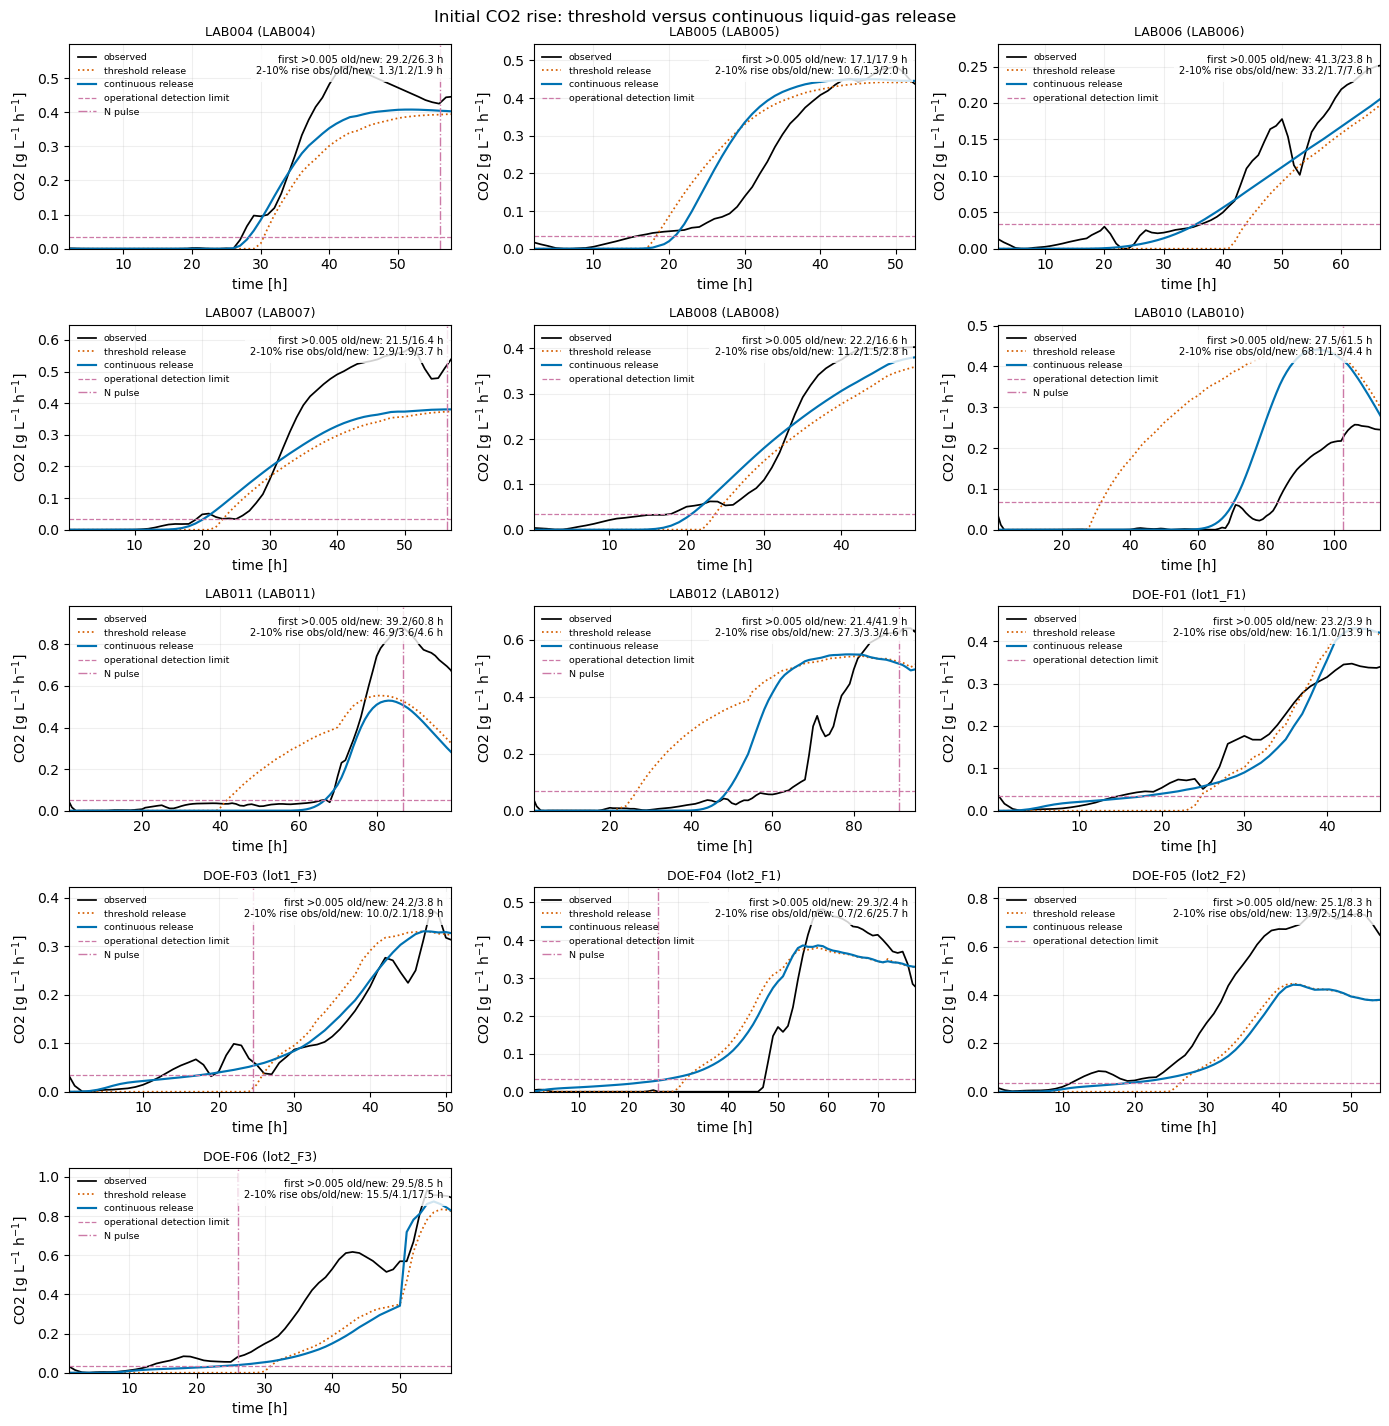

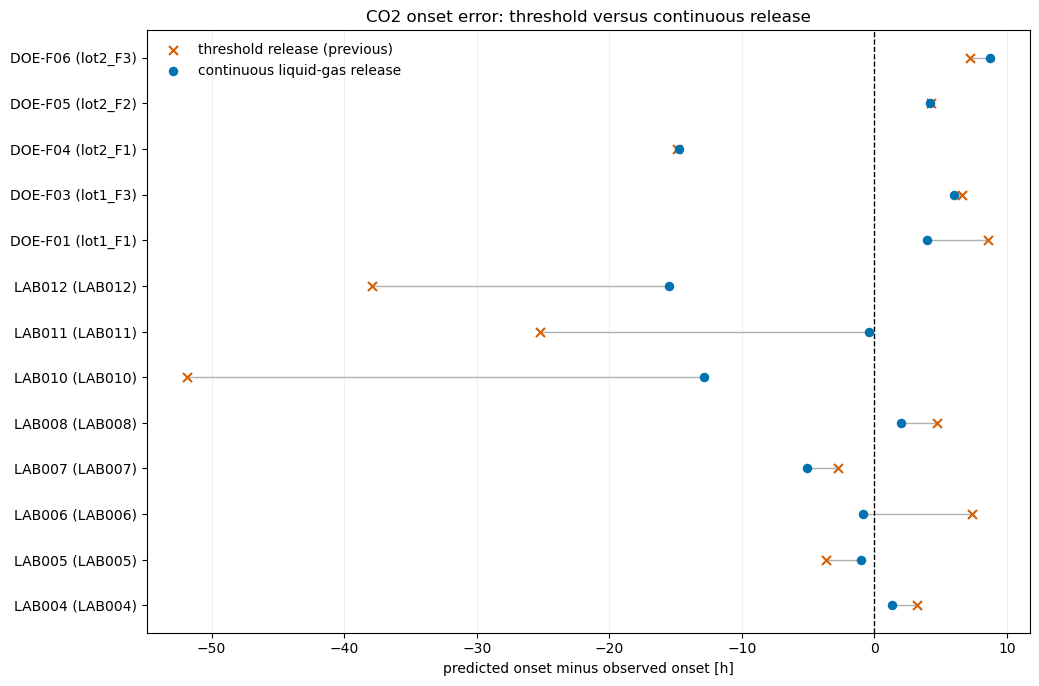

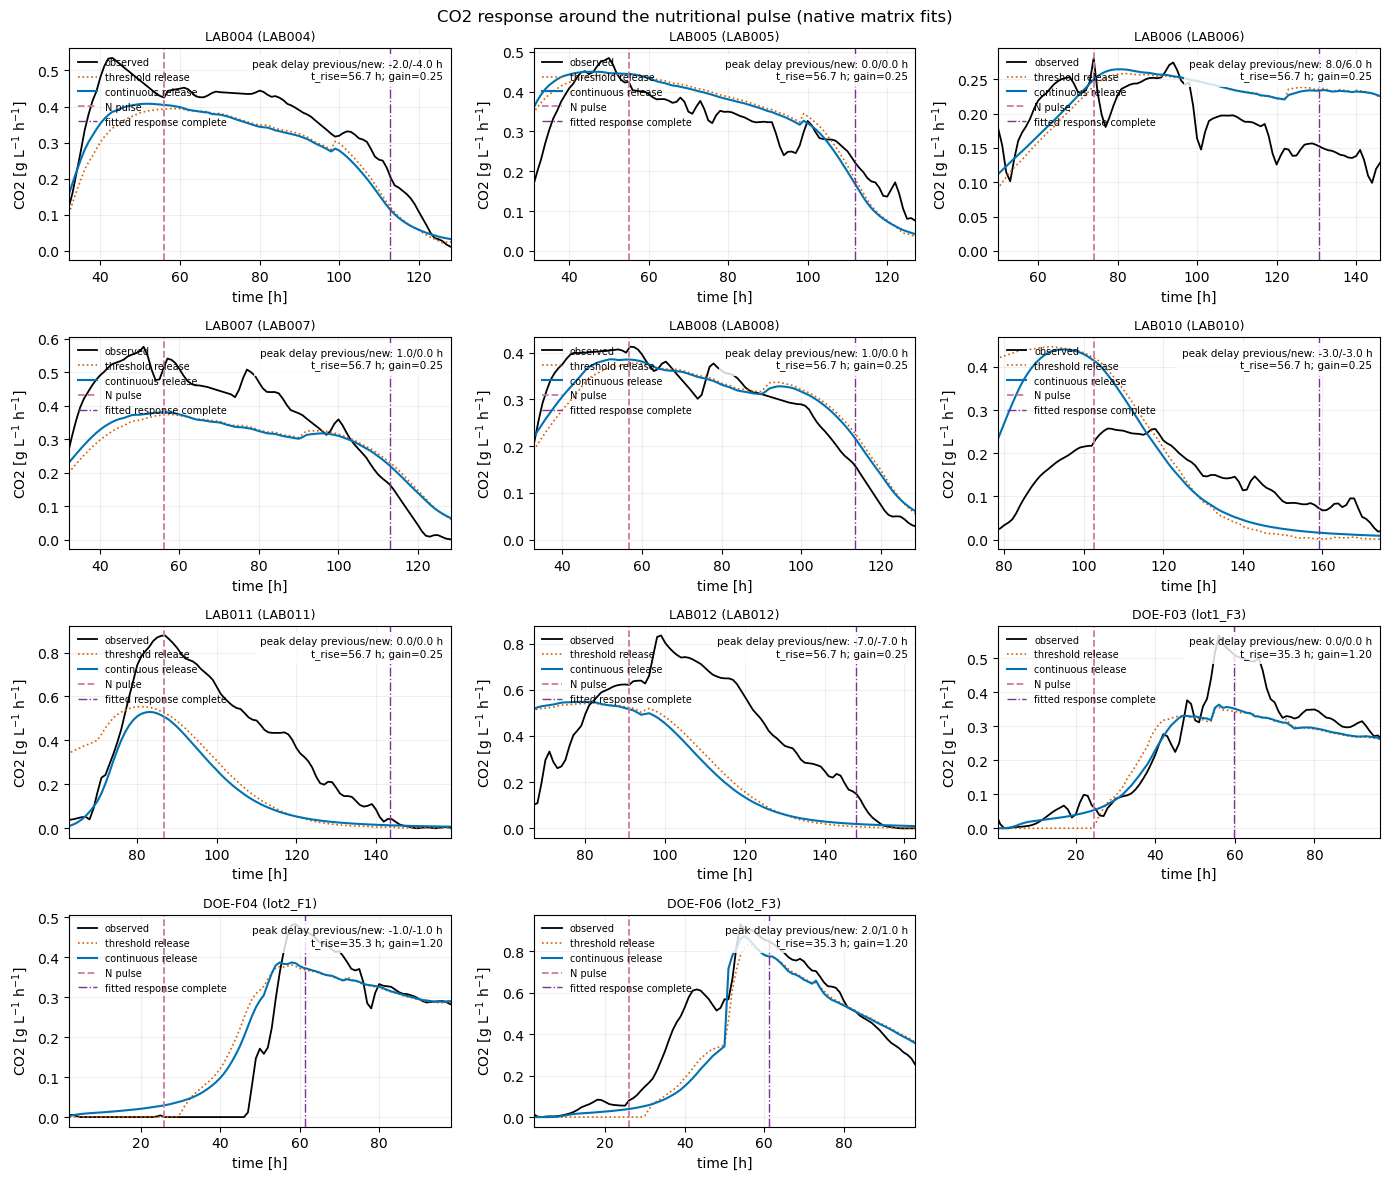

In [10]:
native_transition = result["source_transition_diagnostics"].query("native_matrix_fit").copy()
display(native_transition[[
    "target_matrix", "experiment_code", "batch", "median_setpoint_c",
    "cold_operation", "chemical_activity_lower_h", "chemical_activity_upper_h",
    "source_10pct_peak_onset_h", "o2_below_anaerobic_halfpoint_h",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "O2_qmax_mg_gdw_h", "O2_initial_scale", "n_pulse_time_h",
    "pulse_t_rise_h", "pulse_activity_gain",
    "chem_activation_start_fraction", "chem_activation_duration_fraction",
    "pulse_utilization_complete_h",
    "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]])
fig = analysis.plot_initial_release_comparison(
    result["predictions"], result["previous_predictions"],
    result["batch_metrics"], result["previous_batch_metrics"], save=False
)
plt.show()
fig = analysis.plot_onset_model_comparison(
    result["batch_metrics"], result["previous_batch_metrics"], save=False
)
plt.show()
fig = analysis.plot_pulse_response_comparison(
    result["predictions"], result["previous_predictions"],
    result["batch_metrics"], result["previous_batch_metrics"],
    result["source_transition_diagnostics"], save=False
)
plt.show()

El primer gráfico es el control visual principal: amplía el inicio de cada lote y compara liberación por umbral (naranjo) con liberación continua (azul). La línea horizontal marca 0.005 g L⁻¹ h⁻¹; el texto cuantifica la primera emisión y la duración 2–10 %. El segundo resume el error de inicio. El tercero amplía cada lote pulsado: línea magenta = adición; línea morada = término de la disponibilidad gradual estimada.

## Validación retenida y transferencia cruzada

,scenario,calibration_matrix,target_matrix,experiment_code,batch,n,n_total,n_left_censored,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,r2,integral_ratio_pred_over_observed_lower_bound,observed_onset_h,predicted_onset_h,onset_delay_h,predicted_first_emission_0p005_h,observed_visual_rise_duration_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,pulse_time_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
0,cross_matrix_holdout,synthetic,natural,LAB012,LAB012,98,161,63,0.344574,0.412435,-0.198728,0.082069,-1.060834,0.834944,65.156714,13.823893,-51.332821,5.569067,27.311566,5.028773,-22.282793,91.041739,99.0,97.0,-2.0
1,within_matrix_holdout,natural,natural,LAB012,LAB012,98,161,63,0.296128,0.354448,-0.115538,0.262620,-0.522081,0.736423,65.156714,49.640486,-15.516228,41.890341,27.311566,4.620093,-22.691473,91.041739,99.0,92.0,-7.0
2,cross_matrix_holdout,natural,synthetic,DOE-F06,lot2_F3,88,100,12,0.233592,0.250760,-0.205225,0.977547,0.252999,0.558027,27.509842,29.078629,1.568787,21.710247,15.479194,4.256801,-11.222393,26.000000,54.0,58.0,4.0
3,within_matrix_holdout,synthetic,synthetic,DOE-F06,lot2_F3,88,100,12,0.151561,0.162700,-0.077922,0.888842,0.685529,0.828388,27.509842,36.215465,8.705623,8.511975,15.479194,17.520545,2.041351,26.000000,54.0,55.0,1.0


,scenario,calibration_matrix,target_matrix,batch,experiment_code,rmse_g_l_h_threshold_release,nrmse_peak_threshold_release,correlation_threshold_release,r2_threshold_release,integral_ratio_pred_over_observed_lower_bound_threshold_release,observed_onset_h_threshold_release,predicted_onset_h_threshold_release,onset_delay_h_threshold_release,predicted_first_emission_0p005_h_threshold_release,observed_visual_rise_duration_h_threshold_release,predicted_visual_rise_duration_h_threshold_release,visual_rise_duration_error_h_threshold_release,observed_postpulse_peak_h_threshold_release,predicted_postpulse_peak_h_threshold_release,observed_pulse_t_rise_h_threshold_release,...,nrmse_peak_continuous_release,correlation_continuous_release,r2_continuous_release,integral_ratio_pred_over_observed_lower_bound_continuous_release,observed_onset_h_continuous_release,predicted_onset_h_continuous_release,onset_delay_h_continuous_release,predicted_first_emission_0p005_h_continuous_release,observed_visual_rise_duration_h_continuous_release,predicted_visual_rise_duration_h_continuous_release,visual_rise_duration_error_h_continuous_release,observed_postpulse_peak_h_continuous_release,predicted_postpulse_peak_h_continuous_release,observed_pulse_t_rise_h_continuous_release,predicted_pulse_t_rise_h_continuous_release,postpulse_peak_delay_h_continuous_release,rmse_change_continuous_minus_threshold_release,abs_onset_error_change_continuous_minus_threshold_release,abs_postpulse_peak_error_change_continuous_minus_threshold_release,abs_visual_rise_duration_error_change_continuous_minus_threshold_release
0,cross_matrix_holdout,synthetic,natural,LAB012,LAB012,0.337654,0.404152,0.134204,-0.978889,0.701212,65.156714,20.954824,-44.201890,19.107892,27.311566,1.392853,-25.918713,99.0,96.0,7.958261,...,0.412435,0.082069,-1.060834,0.834944,65.156714,13.823893,-51.332821,5.569067,27.311566,5.028773,-22.282793,99.0,97.0,7.958261,5.958261,-2.0,0.006920,7.130930,-1.0,-3.635920
1,within_matrix_holdout,natural,natural,LAB012,LAB012,0.293133,0.350863,0.263026,-0.491443,0.926834,65.156714,27.270511,-37.886203,21.399697,27.311566,3.276279,-24.035286,99.0,92.0,7.958261,...,0.354448,0.262620,-0.522081,0.736423,65.156714,49.640486,-15.516228,41.890341,27.311566,4.620093,-22.691473,99.0,92.0,7.958261,0.958261,-7.0,0.002996,-22.369975,0.0,-1.343813
2,cross_matrix_holdout,natural,synthetic,lot2_F3,DOE-F06,0.239143,0.256719,0.980863,0.217073,0.551775,27.509842,28.453949,0.944107,24.659038,15.479194,2.712510,-12.766684,54.0,61.0,28.000000,...,0.250760,0.977547,0.252999,0.558027,27.509842,29.078629,1.568787,21.710247,15.479194,4.256801,-11.222393,54.0,58.0,28.000000,32.000000,4.0,-0.005551,0.624680,-3.0,-1.544291
3,within_matrix_holdout,synthetic,synthetic,lot2_F3,DOE-F06,0.142093,0.152537,0.912343,0.723591,0.814661,27.509842,34.712220,7.202378,29.454237,15.479194,4.142484,-11.336711,54.0,56.0,28.000000,...,0.162700,0.888842,0.685529,0.828388,27.509842,36.215465,8.705623,8.511975,15.479194,17.520545,2.041351,54.0,55.0,28.000000,29.000000,1.0,0.009468,1.503245,-1.0,-9.295360


,calibration_matrix,target_matrix,batch,experiment_code,rmse_g_l_h_unfiltered_fit_common_support,nrmse_peak_unfiltered_fit_common_support,bias_g_l_h_unfiltered_fit_common_support,correlation_unfiltered_fit_common_support,r2_unfiltered_fit_common_support,rmse_g_l_h_filtered_censored,nrmse_peak_filtered_censored,bias_g_l_h_filtered_censored,correlation_filtered_censored,r2_filtered_censored,rmse_change
0,synthetic,natural,LAB012,LAB012,0.343742,0.411439,-0.202722,0.090581,-1.050890,0.344574,0.412435,-0.198728,0.082069,-1.060834,0.000832
1,natural,natural,LAB012,LAB012,0.293207,0.350952,-0.127475,0.273635,-0.492200,0.296128,0.354448,-0.115538,0.262620,-0.522081,0.002921
2,natural,synthetic,lot2_F3,DOE-F06,0.233340,0.250490,-0.205440,0.985075,0.254609,0.233592,0.250760,-0.205225,0.977547,0.252999,0.000252
3,synthetic,synthetic,lot2_F3,DOE-F06,0.168463,0.180844,-0.109197,0.884779,0.611480,0.151561,0.162700,-0.077922,0.888842,0.685529,-0.016902


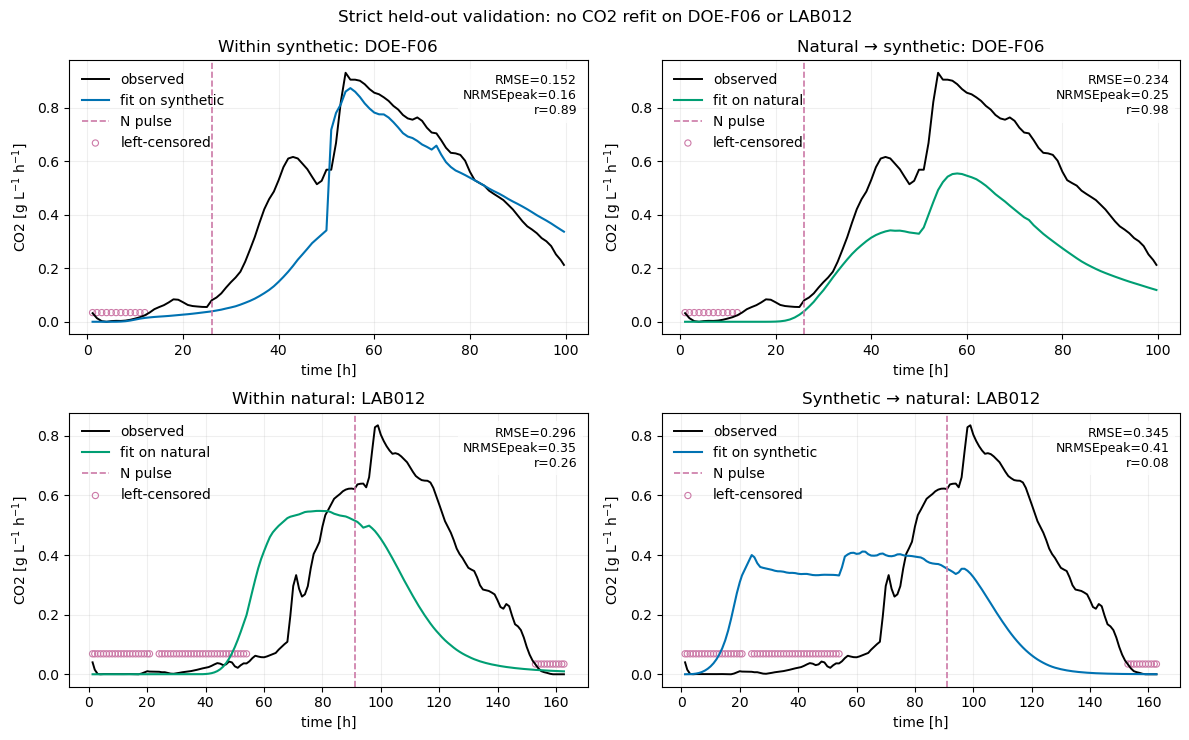

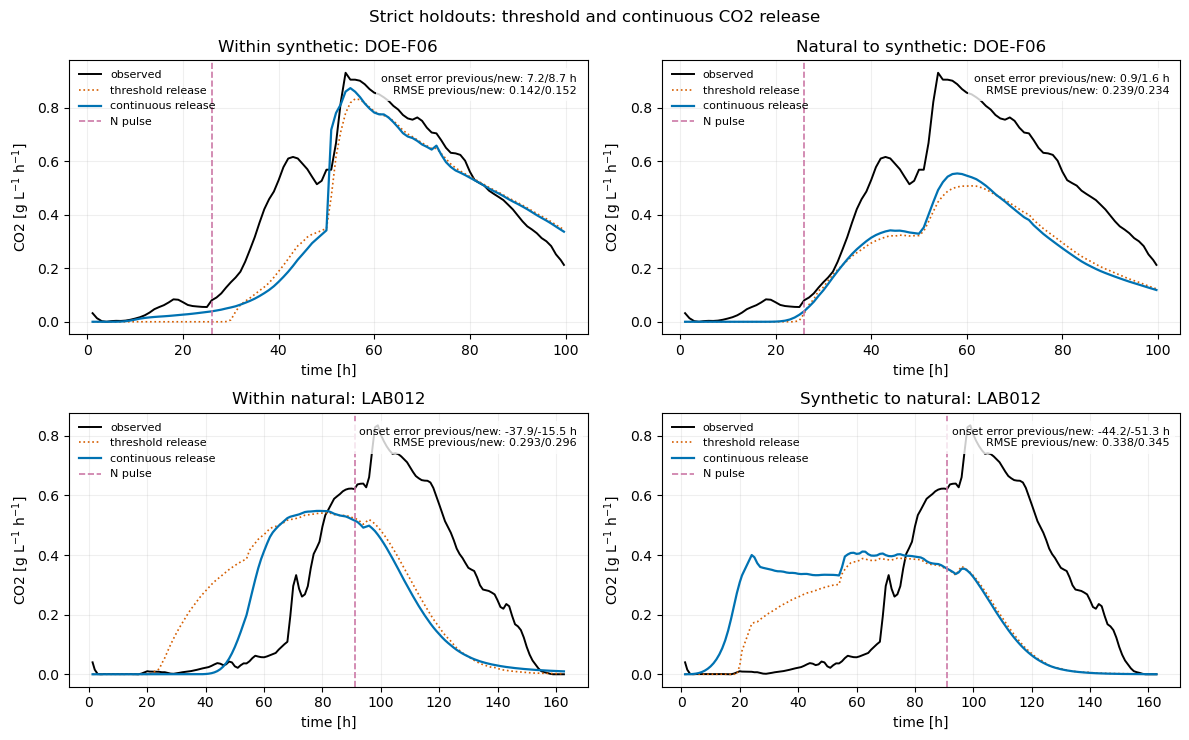

In [11]:
validation_columns = [
    "scenario", "calibration_matrix", "target_matrix", "experiment_code", "batch",
    "n", "n_total", "n_left_censored", "rmse_g_l_h", "nrmse_peak", "bias_g_l_h",
    "correlation", "r2", "integral_ratio_pred_over_observed_lower_bound",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "predicted_first_emission_0p005_h", "observed_visual_rise_duration_h",
    "predicted_visual_rise_duration_h", "visual_rise_duration_error_h",
    "pulse_time_h", "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]
display(result["validation"][validation_columns])
display(result["model_comparison"])
display(result["filter_impact"])
fig = analysis.plot_validation(result["predictions"], result["validation"], save=False)
plt.show()
fig = analysis.plot_validation_model_comparison(
    result["predictions"], result["previous_predictions"],
    result["validation"], result["previous_validation"], save=False
)
plt.show()

`model_comparison` usa exactamente los mismos holdouts para la liberación por umbral anterior y la liberación continua nueva, conservando la misma respuesta finita al pulso. Valores negativos en las columnas `*_change_continuous_minus_threshold_release` significan mejora. `filter_impact` compara los ajustes crudo y filtrado sobre el mismo soporte cuantificable.

## Diagnóstico por fermentación

In [12]:
display(result["batch_metrics"][[
    "calibration_matrix", "target_matrix", "experiment_code", "batch", "role",
    "n", "n_left_censored", "rmse_g_l_h", "nrmse_peak", "bias_g_l_h",
    "correlation", "integral_ratio_pred_over_observed_lower_bound",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h", "pulse_time_h",
    "predicted_first_emission_0p005_h", "observed_visual_rise_duration_h",
    "predicted_visual_rise_duration_h", "visual_rise_duration_error_h",
    "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]].sort_values(["calibration_matrix", "target_matrix", "batch"]))

,calibration_matrix,target_matrix,experiment_code,batch,role,n,n_left_censored,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,integral_ratio_pred_over_observed_lower_bound,observed_onset_h,predicted_onset_h,onset_delay_h,pulse_time_h,predicted_first_emission_0p005_h,observed_visual_rise_duration_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
13,natural,natural,LAB004,LAB004,calibration,97,65,0.075667,0.141521,-0.066934,0.964953,0.823807,27.687244,29.013368,1.326123,56.091667,26.273866,1.275093,1.907881,0.632788,61.0,57.0,-4.0
14,natural,natural,LAB005,LAB005,calibration,119,43,0.066164,0.136508,0.021669,0.913602,1.076548,22.576040,21.553711,-1.022329,55.086614,17.907705,10.599277,1.991744,-8.607532,56.0,56.0,0.0
15,natural,natural,LAB006,LAB006,calibration,139,71,0.077131,0.274422,0.046166,0.576188,1.307882,36.543760,35.656547,-0.887213,74.000000,23.784621,33.181485,7.590487,-25.590998,74.0,80.0,6.0
16,natural,natural,LAB007,LAB007,calibration,100,61,0.108898,0.188792,-0.066196,0.937865,0.854139,26.858251,21.789034,-5.069217,56.246154,16.395062,12.924601,3.705922,-9.218680,57.0,57.0,0.0
17,natural,natural,LAB008,LAB008,calibration,114,47,0.040902,0.099170,0.008150,0.956889,1.034894,19.540360,21.537855,1.997496,56.750000,16.639726,11.159331,2.788656,-8.370676,57.0,57.0,0.0
18,natural,natural,LAB010,LAB010,excluded_fit_frozen_diagnostic,84,101,0.138321,0.537727,0.029767,0.641220,1.298780,83.423205,70.538290,-12.884915,102.494530,61.461558,68.111733,4.428888,-63.682845,106.0,103.0,-3.0
19,natural,natural,LAB011,LAB011,calibration,76,85,0.276700,0.315333,-0.242829,0.877217,0.449609,68.971501,68.580348,-0.391153,86.836735,60.803711,46.946272,4.551039,-42.395233,87.0,87.0,0.0
20,natural,natural,LAB012,LAB012,internal_holdout,98,63,0.296128,0.354448,-0.115538,0.262620,0.736423,65.156714,49.640486,-15.516228,91.041739,41.890341,27.311566,4.620093,-22.691473,99.0,92.0,-7.0
21,natural,synthetic,DOE-F01,lot1_F1,cross_context,178,35,0.182945,0.506994,0.173127,0.887752,2.169763,16.399541,21.445818,5.046277,NaN,17.457749,16.149541,2.222186,-13.927355,NaN,NaN,NaN
22,natural,synthetic,DOE-F03,lot1_F3,cross_context,156,57,0.147463,0.260107,-0.074278,0.459727,0.695865,20.640551,22.402848,1.762297,24.500000,17.365792,10.049108,2.719816,-7.329293,56.0,39.0,-17.0


## Experimento pendiente para distinguir sensor de biología

El umbral dependiente de temperatura sigue siendo operacional, no un LOD/LOQ certificado. Para identificarlo se requiere un ensayo a 15, 18 y 21 °C con el mismo medio y volumen, referencia independiente de CO₂ y escalones de 0.01–0.30 g CO₂ L⁻¹ h⁻¹. En cada temperatura deben estimarse LOD, LOQ, sesgo, repetibilidad y tiempo de respuesta.

La corrección por percentil inicial también es operacional. Debe reemplazarse por blancos de gas sin fermentación medidos al comienzo y al final de cada corrida en cada canal. Eso separaría offset, deriva y flujo biológico temprano sin depender de una ventana temporal elegida.

La validación biológica complementaria debe iniciar con medición química frecuente durante las primeras 48–72 h, especialmente en frío, para estrechar el intervalo de activación. Sin ese muestreo, la química sólo identifica un intervalo y no un instante exacto.

## Resumen reproducible

In [13]:
print("SCCM_CORRECTED:", result["manifest"]["sccm_conversion"]["factor_g_l_h_per_sccm_at_2L"], "g/L/h/SCCM")
display(result["state_objectives"])
print()
print("matrix_gain (parámetro empírico de observación):")
display(result["matrix_gain_compensation"])

direct = result["pairwise_shape_scale"].query("transition == 'A_to_B'")
native = direct.query("calibration_matrix == target_matrix")
print()
print("Batches más sensibles a A→B (fits nativos):")
display(native.nlargest(8, "direct_prediction_rmse_g_l_h")[[
    "calibration_matrix", "target_matrix", "experiment_code", "batch", "role",
    "direct_prediction_rmse_g_l_h", "best_multiplicative_scale_right_from_left",
    "shape_rmse_after_best_scale_g_l_h", "fraction_squared_change_explained_by_scale",
    "integral_ratio_right_over_left", "peak_ratio_right_over_left", "peak_time_change_h"
]])

print()
print("Holdouts y transferencia A/B/C:")
display(result["state_validation"])
print()
print("Parámetros en límite por estado:")
display(result["state_parameters"].query("active_bound"))
print()
print("Identificabilidad local A vs C:")
display(result["identifiability_state_comparison"])
print()
print("Artefactos:", analysis.RESULTS_DIR.relative_to(ROOT))

SCCM_CORRECTED: 0.0404391928807947 g/L/h/SCCM


,state,matrix,wsse_equal_batch_fixed_co2,n_residuals,matrix_gain,co2_refitted
0,A_historical,synthetic,19.515601,632,1.459910,False
1,A_historical,natural,18.814777,1029,2.139011,False
2,A_historical,all,38.330378,1661,NaN,False
3,B_full_theta_no_refit,synthetic,27.810253,632,1.459910,False
4,B_full_theta_no_refit,natural,38.154928,1029,2.139011,False
5,B_full_theta_no_refit,all,65.965181,1661,NaN,False
6,C_full_theta_refit,synthetic,18.908940,632,1.149648,True
7,C_full_theta_refit,natural,15.959851,1029,1.602222,True
8,C_full_theta_refit,all,34.868791,1661,NaN,True



matrix_gain (parámetro empírico de observación):


,matrix,historical_matrix_gain,refit_matrix_gain,absolute_change,percent_change,direct_raw_integral_ratio_B_over_A,gain_ratio_C_over_A,gain_only_compensated_ratio_to_A,other_co2_layer_raw_ratio_C_over_B,final_scaled_integral_ratio_C_over_A,interpretation_guardrail
0,synthetic,1.459910,1.149648,-0.310262,-21.252106,1.279092,0.787479,1.007258,1.002452,1.009727,matrix_gain is an empirical observation/scale ...
1,natural,2.139011,1.602222,-0.536789,-25.095189,1.223072,0.749048,0.916140,1.055845,0.967302,matrix_gain is an empirical observation/scale ...



Batches más sensibles a A→B (fits nativos):


...


Parámetros en límite por estado:


,state,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance,co2_refitted
2,A_historical,synthetic,O2_qmax_mg_gdw_h,0.150164,0.15,6.00,True,2.956649e-04,False
6,A_historical,synthetic,chem_activation_start_fraction,0.010004,0.01,0.95,True,8.809663e-05,False
7,A_historical,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,1.204971e-09,False
10,A_historical,natural,CO2sat_scale,0.350040,0.35,2.50,True,5.834029e-05,False
11,A_historical,natural,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True,1.859963e-14,False
14,A_historical,natural,pulse_activity_gain,0.250000,0.25,4.00,True,0.000000e+00,False
20,B_full_theta_no_refit,synthetic,O2_qmax_mg_gdw_h,0.150164,0.15,6.00,True,2.956649e-04,False
24,B_full_theta_no_refit,synthetic,chem_activation_start_fraction,0.010004,0.01,0.95,True,8.809663e-05,False
25,B_full_theta_no_refit,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,1.204971e-09,False
28,B_full_theta_no_refit,natural,CO2sat_scale,0.350040,0.35,2.50,True,5.834029e-05,False



Identificabilidad local A vs C:


,state,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,A_historical,synthetic,632,8,8,2.924571e+07,2.660739e-07,7.781522,0.031275,ill_conditioned
1,A_historical,natural,1029,8,8,7.937670e+01,7.211155e-02,5.723977,0.018405,moderate_or_better
2,C_full_theta_refit,synthetic,632,8,8,9.076098e+10,3.373549e-08,3061.865826,0.030303,ill_conditioned
3,C_full_theta_refit,natural,1029,8,8,2.154967e+04,5.115635e-02,1102.402405,0.015632,ill_conditioned



Artefactos: fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010


## Artifacts

The complete recalibration and sensitivity suite is written only to
`results/co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010/`.
The current full-theta calibration folder is used read-only as scenario A. In scenario B,
LAB010 is excluded from the natural objective, objective profiles and leave-one-batch-out
refits; LAB012 remains the internal holdout.


## LAB010 influence sensitivity — current A versus no-LAB010 B

The current full-theta fit is loaded from its existing artifacts as **A** (original signals,
LAB010 included). The result generated above is **B**: LAB010 excluded and the repaired
sampling signals for LAB004/007/008, so this section still bundles both interventions. The
repaired-signal-only isolation against the previous no-LAB010 run is reported in the dedicated
section below. Integrals are recomputed from the stored prediction rows over each complete
hourly support; the remaining statistics are the established metrics from the unchanged
scoring function.


In [14]:
import json
from dataclasses import replace
import numpy as np

CURRENT_DIR = BASELINE_RESULTS_DIR
CURRENT_FIT_PARAMETERS_PATH = CURRENT_DIR / "fit_parameters.csv"
CURRENT_FIT_STARTS_PATH = CURRENT_DIR / "fit_start_diagnostics.csv"
CURRENT_METRICS_PATH = CURRENT_DIR / "batch_metrics.csv"
CURRENT_PREDICTIONS_PATH = CURRENT_DIR / "prediction_rows.csv"

current_parameters = pd.read_csv(CURRENT_FIT_PARAMETERS_PATH)
current_fit_starts = pd.read_csv(CURRENT_FIT_STARTS_PATH)
current_metrics = pd.read_csv(CURRENT_METRICS_PATH)
current_predictions = pd.read_csv(CURRENT_PREDICTIONS_PATH)

def _native_natural(frame):
    return frame[
        frame["calibration_matrix"].eq("natural")
        & frame["target_matrix"].eq("natural")
    ].copy()

def _integrals(predictions):
    rows = []
    for batch, group in _native_natural(predictions).groupby("batch", sort=True):
        group = group.sort_values("time_h")
        rows.append({
            "batch": batch,
            "observed_integral_g_l": float(np.trapz(group["observed_g_l_h"], group["time_h"])),
            "predicted_integral_g_l": float(np.trapz(group["predicted_g_l_h"], group["time_h"])),
        })
    return pd.DataFrame(rows)

def _scenario_metrics(label, metrics, predictions):
    selected = _native_natural(metrics).merge(_integrals(predictions), on="batch", validate="one_to_one")
    selected.insert(0, "scenario", label)
    selected["integral_ratio_recomputed"] = (
        selected["predicted_integral_g_l"] / selected["observed_integral_g_l"].clip(lower=1e-12)
    )
    return selected

metrics_a = _scenario_metrics("A_current_with_LAB010", current_metrics, current_predictions)
metrics_b = _scenario_metrics("B_no_LAB010", result["batch_metrics"], result["predictions"])
sensitivity_metrics_long = pd.concat([metrics_a, metrics_b], ignore_index=True)

metric_names = [
    "rmse_g_l_h", "nrmse_peak", "bias_g_l_h", "correlation", "r2",
    "observed_integral_g_l", "predicted_integral_g_l", "integral_ratio_recomputed",
    "observed_peak_g_l_h", "predicted_peak_g_l_h", "observed_peak_time_h",
    "predicted_peak_time_h", "observed_onset_h", "predicted_onset_h", "onset_delay_h",
]
wide_a = metrics_a[["batch", *metric_names]].copy()
wide_b = metrics_b[["batch", *metric_names]].copy()
sensitivity_metric_changes = wide_a.merge(
    wide_b, on="batch", suffixes=("_A", "_B"), validate="one_to_one"
)
for metric in metric_names:
    sensitivity_metric_changes[f"{metric}_change_B_minus_A"] = (
        sensitivity_metric_changes[f"{metric}_B"] - sensitivity_metric_changes[f"{metric}_A"]
    )
    sensitivity_metric_changes[f"{metric}_pct_change_B_vs_A"] = 100.0 * (
        sensitivity_metric_changes[f"{metric}_B"] - sensitivity_metric_changes[f"{metric}_A"]
    ) / sensitivity_metric_changes[f"{metric}_A"].abs().replace(0.0, np.nan)

parameters_a = current_parameters.copy()
parameters_a.insert(0, "scenario", "A_current_with_LAB010")
parameters_b = result["fit_parameters"].copy()
parameters_b.insert(0, "scenario", "B_no_LAB010")
sensitivity_parameters_long = pd.concat([parameters_a, parameters_b], ignore_index=True)
sensitivity_parameter_changes = current_parameters.merge(
    result["fit_parameters"], on=["calibration_matrix", "parameter"],
    suffixes=("_A", "_B"), validate="one_to_one"
)
sensitivity_parameter_changes["absolute_change_B_minus_A"] = (
    sensitivity_parameter_changes["estimate_B"] - sensitivity_parameter_changes["estimate_A"]
)
sensitivity_parameter_changes["percent_change_B_vs_A"] = 100.0 * (
    sensitivity_parameter_changes["absolute_change_B_minus_A"]
    / sensitivity_parameter_changes["estimate_A"].abs().replace(0.0, np.nan)
)

fit_batches_a = ["LAB004", "LAB005", "LAB006", "LAB007", "LAB008", "LAB010", "LAB011"]
fit_batches_b = _historical._calibration_batch_names("natural", result["observations"])
objective_a = (
    current_fit_starts.sort_values("wsse_equal_batch")
    .groupby("matrix", as_index=False).first()[["matrix", "wsse_equal_batch"]]
)
objective_a.insert(0, "scenario", "A_current_with_LAB010")
objective_a["support"] = "native_fit_support"
objective_b = pd.DataFrame([
    {"scenario": "B_no_LAB010", "matrix": matrix, "wsse_equal_batch": fit["wsse_equal_batch"]}
    for matrix, fit in result["fits"].items()
])
objective_b["support"] = "native_fit_support"

# Fair WSSE comparison on the identical six-batch natural support used by B.
_common_theta_sets, _, _ = analysis.load_complete_theta_sets()
_common_batches, _, _ = _historical.load_batches()
_common_cache, _ = _historical.build_driver_cache(
    _common_batches,
    {"natural": _common_theta_sets["natural"], "synthetic": _common_theta_sets["synthetic"]},
    result["observations"],
)
_current_natural_parameters = dict(zip(
    current_parameters.loc[current_parameters["calibration_matrix"].eq("natural"), "parameter"],
    current_parameters.loc[current_parameters["calibration_matrix"].eq("natural"), "estimate"],
))
_current_natural_parameters["model"] = analysis.MODEL_NAME
_common_residual_a = analysis._fixed_parameter_residual(
    _current_natural_parameters, fit_batches_b, result["observations"], _common_cache
)
common_support_objectives = pd.DataFrame([
    {"scenario": "A_current_with_LAB010", "matrix": "natural",
     "wsse_equal_batch": float(np.dot(_common_residual_a, _common_residual_a)),
     "support": "common_six_batch_support"},
    {"scenario": "B_no_LAB010", "matrix": "natural",
     "wsse_equal_batch": float(result["fits"]["natural"]["wsse_equal_batch"]),
     "support": "common_six_batch_support"},
])
sensitivity_objectives = pd.concat([objective_a, objective_b, common_support_objectives], ignore_index=True)

sensitivity_inventory = pd.DataFrame([
    {"scenario": "A_current_with_LAB010", "natural_fit_batches": ", ".join(fit_batches_a),
     "n_natural_fit_batches": len(fit_batches_a), "natural_internal_holdout": "LAB012",
     "LAB010_role": "calibration"},
    {"scenario": "B_no_LAB010", "natural_fit_batches": ", ".join(fit_batches_b),
     "n_natural_fit_batches": len(fit_batches_b), "natural_internal_holdout": "LAB012",
     "LAB010_role": "excluded fit; frozen diagnostic"},
])

print("Calibration membership audit")
display(sensitivity_inventory)
print("Objective comparison")
display(sensitivity_objectives.round(6))
print("CO2-layer parameters A/B")
display(sensitivity_parameter_changes.round(6))
print("LAB010 frozen diagnostic and requested validation batches")
display(sensitivity_metrics_long[
    sensitivity_metrics_long["batch"].isin(["LAB010", "LAB011", "LAB012"])
][["scenario", "batch", "role", *metric_names]].round(6))


Calibration membership audit


,scenario,natural_fit_batches,n_natural_fit_batches,natural_internal_holdout,LAB010_role
0,A_current_with_LAB010,"LAB004, LAB005, LAB006, LAB007, LAB008, LAB010...",7,LAB012,calibration
1,B_no_LAB010,"LAB004, LAB005, LAB006, LAB007, LAB008, LAB011",6,LAB012,excluded fit; frozen diagnostic


Objective comparison


,scenario,matrix,wsse_equal_batch,support
0,A_current_with_LAB010,natural,29.341781,native_fit_support
1,A_current_with_LAB010,synthetic,18.908940,native_fit_support
2,B_no_LAB010,synthetic,18.908940,native_fit_support
3,B_no_LAB010,natural,15.959851,native_fit_support
4,A_current_with_LAB010,natural,18.501859,common_six_batch_support
5,B_no_LAB010,natural,15.959851,common_six_batch_support


CO2-layer parameters A/B


,calibration_matrix,parameter,estimate_A,lower_bound_A,upper_bound_A,active_bound_A,relative_bound_distance_A,estimate_B,lower_bound_B,upper_bound_B,active_bound_B,relative_bound_distance_B,absolute_change_B_minus_A,percent_change_B_vs_A
0,synthetic,kCO2_release_h,6.118870,0.03,25.00,False,0.209280,6.118870,0.03,25.00,False,0.209280,0.000000,0.000000
1,synthetic,CO2sat_scale,0.606169,0.35,2.50,False,0.279346,0.606169,0.35,2.50,False,0.279346,0.000000,0.000000
2,synthetic,O2_qmax_mg_gdw_h,0.150032,0.15,6.00,True,0.000059,0.150032,0.15,6.00,True,0.000059,0.000000,0.000000
3,synthetic,O2_initial_scale,0.359185,0.05,1.50,False,0.420259,0.359185,0.05,1.50,False,0.420259,0.000000,0.000000
4,synthetic,pulse_t_rise_h,35.314587,1.00,72.00,False,0.166571,35.314587,1.00,72.00,False,0.166571,0.000000,0.000000
5,synthetic,pulse_activity_gain,1.197615,0.25,4.00,False,0.434959,1.197615,0.25,4.00,False,0.434959,0.000000,0.000000
6,synthetic,chem_activation_start_fraction,0.010000,0.01,0.95,True,0.000000,0.010000,0.01,0.95,True,0.000000,0.000000,0.000000
7,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,0.000000,0.350000,0.35,2.00,True,0.000000,0.000000,0.000000
8,synthetic,matrix_gain,1.149648,0.10,20.00,False,0.460909,1.149648,0.10,20.00,False,0.460909,0.000000,0.000000
9,natural,kCO2_release_h,0.289048,0.03,25.00,False,0.336840,0.278349,0.03,25.00,False,0.331232,-0.010699,-3.701311


LAB010 frozen diagnostic and requested validation batches


,scenario,batch,role,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,r2,observed_integral_g_l,predicted_integral_g_l,integral_ratio_recomputed,observed_peak_g_l_h,predicted_peak_g_l_h,observed_peak_time_h,predicted_peak_time_h,observed_onset_h,predicted_onset_h,onset_delay_h
5,A_current_with_LAB010,LAB010,calibration,0.065501,0.254635,-0.026149,0.877936,-0.142730,14.690736,12.201547,0.830561,0.257233,0.310599,106.0,104.0,83.423205,79.775935,-3.647270
6,A_current_with_LAB010,LAB011,calibration,0.346934,0.395373,-0.311977,0.956993,-0.784468,35.679044,10.574274,0.296372,0.877484,0.349356,87.0,89.0,68.971501,74.290315,5.318814
7,A_current_with_LAB010,LAB012,internal_holdout,0.267236,0.319865,-0.163410,0.530159,-0.239557,41.836784,25.362423,0.606223,0.835463,0.512349,99.0,82.0,65.156714,56.253863,-8.902851
13,B_no_LAB010,LAB010,excluded_fit_frozen_diagnostic,0.138321,0.537727,0.029767,0.641220,-4.096010,14.690736,19.080041,1.298780,0.257233,0.440761,106.0,95.0,83.423205,70.538290,-12.884915
14,B_no_LAB010,LAB011,calibration,0.276700,0.315333,-0.242829,0.877217,-0.135098,35.679044,16.041634,0.449609,0.877484,0.529408,87.0,83.0,68.971501,68.580348,-0.391153
15,B_no_LAB010,LAB012,internal_holdout,0.296128,0.354448,-0.115538,0.262620,-0.522081,41.836784,30.809572,0.736423,0.835463,0.548173,99.0,79.0,65.156714,49.640486,-15.516228


## Identifiability sensitivity

The local log-Jacobian, parameter-correlation matrix, activation profiles and LOO refits for B
all use the six-batch natural fit. The corresponding current-calibration artifacts are loaded as A.


In [15]:
current_jacobian = pd.read_csv(CURRENT_DIR / "activation_jacobian_identifiability.csv")
current_correlations = pd.read_csv(CURRENT_DIR / "activation_local_parameter_correlations.csv")
current_profiles = pd.read_csv(CURRENT_DIR / "activation_objective_profiles.csv")
current_loo_summary = pd.read_csv(CURRENT_DIR / "activation_leave_one_batch_out_summary.csv")
current_loo_estimates = pd.read_csv(CURRENT_DIR / "activation_leave_one_batch_out_estimates.csv")

def _tag(frame, scenario):
    tagged = frame.copy()
    tagged.insert(0, "scenario", scenario)
    return tagged

sensitivity_identifiability = pd.concat([
    _tag(current_jacobian, "A_current_with_LAB010"),
    _tag(result["jacobian_identifiability"], "B_no_LAB010"),
], ignore_index=True)
sensitivity_correlations = pd.concat([
    _tag(current_correlations, "A_current_with_LAB010"),
    _tag(result["local_parameter_correlations"], "B_no_LAB010"),
], ignore_index=True)
sensitivity_profiles = pd.concat([
    _tag(current_profiles, "A_current_with_LAB010"),
    _tag(result["activation_profiles"], "B_no_LAB010"),
], ignore_index=True)
sensitivity_loo_summary = pd.concat([
    _tag(current_loo_summary, "A_current_with_LAB010"),
    _tag(result["loo_activation_summary"], "B_no_LAB010"),
], ignore_index=True)
sensitivity_loo_estimates = pd.concat([
    _tag(current_loo_estimates, "A_current_with_LAB010"),
    _tag(result["loo_activation_estimates"], "B_no_LAB010"),
], ignore_index=True)

print("Local Jacobian condition/rank")
display(sensitivity_identifiability.round(6))
print("Activation-parameter LOO stability")
display(sensitivity_loo_summary.round(6))
print("Largest absolute off-diagonal local correlations — natural matrix")
display(
    sensitivity_correlations[
        sensitivity_correlations["matrix"].eq("natural")
        & sensitivity_correlations["parameter_1"].ne(sensitivity_correlations["parameter_2"])
    ].assign(abs_correlation=lambda d: d["local_log_parameter_correlation"].abs())
    .sort_values(["scenario", "abs_correlation"], ascending=[True, False])
    .groupby("scenario", as_index=False).head(8)
    .round(6)
)


Local Jacobian condition/rank


,scenario,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,A_current_with_LAB010,synthetic,632,8,8,9.076098e+10,0.000000,3061.865826,0.030303,ill_conditioned
1,A_current_with_LAB010,natural,1216,8,8,1.374952e+07,0.000001,12.182643,0.024290,ill_conditioned
2,B_no_LAB010,synthetic,632,8,8,9.076098e+10,0.000000,3061.865826,0.030303,ill_conditioned
3,B_no_LAB010,natural,1029,8,8,2.154967e+04,0.051156,1102.402405,0.015632,ill_conditioned


Activation-parameter LOO stability


,scenario,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,A_current_with_LAB010,natural,chem_activation_start_fraction,0.761770,0.599077,0.756516,0.810822,0.211746,0.277965,7,0,0
1,A_current_with_LAB010,natural,chem_activation_duration_fraction,0.801185,0.736032,0.790626,0.845992,0.109960,0.137247,7,0,0
2,A_current_with_LAB010,synthetic,chem_activation_start_fraction,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000,4,4,0
3,A_current_with_LAB010,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,0.000000,0.000000,4,4,0
4,B_no_LAB010,natural,chem_activation_start_fraction,0.741575,0.637447,0.753604,0.796561,0.159114,0.214563,6,0,0
5,B_no_LAB010,natural,chem_activation_duration_fraction,0.457773,0.350000,0.403928,1.737068,1.387068,3.030031,6,3,0
6,B_no_LAB010,synthetic,chem_activation_start_fraction,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000,4,4,0
7,B_no_LAB010,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,0.000000,0.000000,4,4,0


Largest absolute off-diagonal local correlations — natural matrix


,scenario,matrix,parameter_1,parameter_2,local_log_parameter_correlation,log_parameter_standard_error_1,abs_correlation
83,A_current_with_LAB010,natural,O2_qmax_mg_gdw_h,O2_initial_scale,-1.000000,0.113749,1.000000
90,A_current_with_LAB010,natural,O2_initial_scale,O2_qmax_mg_gdw_h,-1.000000,0.116443,1.000000
72,A_current_with_LAB010,natural,CO2sat_scale,kCO2_release_h,0.993969,1.839103,0.993969
65,A_current_with_LAB010,natural,kCO2_release_h,CO2sat_scale,0.993969,1.080920,0.993969
119,A_current_with_LAB010,natural,chem_activation_start_fraction,chem_activation_duration_fraction,-0.941152,0.056875,0.941152
126,A_current_with_LAB010,natural,chem_activation_duration_fraction,chem_activation_start_fraction,-0.941152,0.109532,0.941152
108,A_current_with_LAB010,natural,pulse_activity_gain,pulse_t_rise_h,-0.524307,0.160443,0.524307
101,A_current_with_LAB010,natural,pulse_t_rise_h,pulse_activity_gain,-0.524307,0.090444,0.524307
218,B_no_LAB010,natural,O2_initial_scale,O2_qmax_mg_gdw_h,0.993707,1.183280,0.993707
211,B_no_LAB010,natural,O2_qmax_mg_gdw_h,O2_initial_scale,0.993707,1.682629,0.993707


## Repaired-signal isolation — previous-signals A′ versus repaired-signals B (both no-LAB010)

**A′** is the frozen snapshot of the previous execution of this same no-LAB010 experiment with the
original LAB004/007/008 signals (`..._no_lab010_previous_signals_A`). **B** is the run above with
the repaired signals. Fit membership, theta, SCCM factor, objective, bounds, weights, censoring
treatment, multistart and optimizer are identical; the only difference is the observed signal of
those three batches. The cross-objective table additionally evaluates each parameter set on both
observation supports to attribute the WSSE change to the signal replacement.


In [16]:
import math

PREVIOUS_SIGNALS_DIR = (
    analysis.SCRIPT_DIR
    / "results"
    / "co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010_previous_signals_A"
)
previous_parameters = pd.read_csv(PREVIOUS_SIGNALS_DIR / "fit_parameters.csv")
previous_fit_starts = pd.read_csv(PREVIOUS_SIGNALS_DIR / "fit_start_diagnostics.csv")
previous_metrics = pd.read_csv(PREVIOUS_SIGNALS_DIR / "batch_metrics.csv")
previous_predictions = pd.read_csv(PREVIOUS_SIGNALS_DIR / "prediction_rows.csv")
previous_jacobian = pd.read_csv(
    PREVIOUS_SIGNALS_DIR / "activation_jacobian_identifiability.csv"
)
previous_correlations = pd.read_csv(
    PREVIOUS_SIGNALS_DIR / "activation_local_parameter_correlations.csv"
)
previous_loo_summary = pd.read_csv(
    PREVIOUS_SIGNALS_DIR / "activation_leave_one_batch_out_summary.csv"
)
previous_loo_estimates = pd.read_csv(
    PREVIOUS_SIGNALS_DIR / "activation_leave_one_batch_out_estimates.csv"
)

# Guard: the snapshot is exactly the previous no-LAB010 run on the original signals.
_previous_observations = pd.read_csv(PREVIOUS_SIGNALS_DIR / "co2_observations_hourly.csv")
_swapped_rows = _previous_observations["batch"].isin(SIGNAL_SWAP_BATCHES).to_numpy()
_assert_identical_frames(
    _previous_observations.loc[~_swapped_rows].reset_index(drop=True)[
        _baseline_observations.columns
    ],
    repaired_support_observations.loc[~_swapped_rows].reset_index(drop=True)[
        _baseline_observations.columns
    ],
    "non-swapped rows",
)
assert (
    _previous_observations.loc[_swapped_rows, "co2_rate_g_l_h"]
    .to_numpy(dtype=float)
    .tolist()
    != repaired_support_observations.loc[_swapped_rows, "co2_rate_g_l_h"]
    .to_numpy(dtype=float)
    .tolist()
)

def _tag_signal(frame, scenario):
    tagged = frame.copy()
    tagged.insert(0, "scenario", scenario)
    return tagged

# --- parameters -----------------------------------------------------------
signal_parameter_changes = previous_parameters.merge(
    result["fit_parameters"],
    on=["calibration_matrix", "parameter"],
    suffixes=("_A_previous_signals", "_B_repaired_signals"),
    validate="one_to_one",
)
signal_parameter_changes["absolute_change_B_minus_A"] = (
    signal_parameter_changes["estimate_B_repaired_signals"]
    - signal_parameter_changes["estimate_A_previous_signals"]
)
signal_parameter_changes["percent_change_B_vs_A"] = 100.0 * (
    signal_parameter_changes["absolute_change_B_minus_A"]
    / signal_parameter_changes["estimate_A_previous_signals"].abs().replace(0.0, np.nan)
)
signal_parameters_long = pd.concat(
    [
        _tag_signal(previous_parameters, "A_previous_signals"),
        _tag_signal(result["fit_parameters"], "B_repaired_signals"),
    ],
    ignore_index=True,
)

# --- per-batch metrics ----------------------------------------------------
metrics_prev_signals = _scenario_metrics("A_previous_signals", previous_metrics, previous_predictions)
metrics_repaired_signals = _scenario_metrics(
    "B_repaired_signals", result["batch_metrics"], result["predictions"]
)
signal_metrics_long = pd.concat(
    [metrics_prev_signals, metrics_repaired_signals], ignore_index=True
)
wide_prev_signals = metrics_prev_signals[["batch", *metric_names]].copy()
wide_repaired_signals = metrics_repaired_signals[["batch", *metric_names]].copy()
signal_metric_changes = wide_prev_signals.merge(
    wide_repaired_signals,
    on="batch",
    suffixes=("_A_previous_signals", "_B_repaired_signals"),
    validate="one_to_one",
)
for metric in metric_names:
    signal_metric_changes[f"{metric}_change_B_minus_A"] = (
        signal_metric_changes[f"{metric}_B_repaired_signals"]
        - signal_metric_changes[f"{metric}_A_previous_signals"]
    )

# --- WSSE attribution on the identical six-batch support ------------------
_previous_natural = previous_parameters[previous_parameters["calibration_matrix"].eq("natural")]
_previous_natural_parameters = dict(zip(_previous_natural["parameter"], _previous_natural["estimate"]))
_previous_natural_parameters["model"] = analysis.MODEL_NAME
_repaired_natural_table = result["fit_parameters"][
    result["fit_parameters"]["calibration_matrix"].eq("natural")
]
_repaired_natural_parameters = dict(
    zip(_repaired_natural_table["parameter"], _repaired_natural_table["estimate"])
)
_repaired_natural_parameters["model"] = analysis.MODEL_NAME

_res_A_on_A = analysis._fixed_parameter_residual(
    _previous_natural_parameters, fit_batches_b, _previous_observations, _common_cache
)
_res_A_on_B = analysis._fixed_parameter_residual(
    _previous_natural_parameters, fit_batches_b, result["observations"], _common_cache
)
_res_B_on_A = analysis._fixed_parameter_residual(
    _repaired_natural_parameters, fit_batches_b, _previous_observations, _common_cache
)
_res_B_on_B = analysis._fixed_parameter_residual(
    _repaired_natural_parameters, fit_batches_b, result["observations"], _common_cache
)
_wsse = lambda r: float(np.dot(r, r))
signal_objectives = pd.DataFrame(
    [
        {
            "parameter_set": "A_previous_signals",
            "observation_support": "A_previous_signals",
            "wsse_equal_batch": _wsse(_res_A_on_A),
        },
        {
            "parameter_set": "A_previous_signals",
            "observation_support": "B_repaired_signals",
            "wsse_equal_batch": _wsse(_res_A_on_B),
        },
        {
            "parameter_set": "B_repaired_signals",
            "observation_support": "A_previous_signals",
            "wsse_equal_batch": _wsse(_res_B_on_A),
        },
        {
            "parameter_set": "B_repaired_signals",
            "observation_support": "B_repaired_signals",
            "wsse_equal_batch": _wsse(_res_B_on_B),
        },
    ]
)
_prev_fit_wsse = float(
    previous_fit_starts.sort_values("wsse_equal_batch").query("matrix == 'natural'")
    .iloc[0]["wsse_equal_batch"]
)
assert math.isclose(
    signal_objectives.loc[0, "wsse_equal_batch"], _prev_fit_wsse, rel_tol=1e-6
), (signal_objectives.loc[0, "wsse_equal_batch"], _prev_fit_wsse)
assert math.isclose(
    signal_objectives.loc[3, "wsse_equal_batch"],
    float(result["fits"]["natural"]["wsse_equal_batch"]),
    rel_tol=1e-6,
)

# --- identifiability, correlations, LOO -----------------------------------
signal_identifiability = pd.concat(
    [
        _tag_signal(previous_jacobian, "A_previous_signals"),
        _tag_signal(result["jacobian_identifiability"], "B_repaired_signals"),
    ],
    ignore_index=True,
)
signal_correlations = pd.concat(
    [
        _tag_signal(previous_correlations, "A_previous_signals"),
        _tag_signal(result["local_parameter_correlations"], "B_repaired_signals"),
    ],
    ignore_index=True,
)
signal_loo_summary = pd.concat(
    [
        _tag_signal(previous_loo_summary, "A_previous_signals"),
        _tag_signal(result["loo_activation_summary"], "B_repaired_signals"),
    ],
    ignore_index=True,
)
signal_loo_estimates = pd.concat(
    [
        _tag_signal(previous_loo_estimates, "A_previous_signals"),
        _tag_signal(result["loo_activation_estimates"], "B_repaired_signals"),
    ],
    ignore_index=True,
)

print("CO2-layer parameters — natural matrix, previous versus repaired signals")
display(
    signal_parameter_changes[
        signal_parameter_changes["calibration_matrix"].eq("natural")
    ].round(6)
)
print("WSSE attribution on the identical six-batch natural support")
display(signal_objectives.round(6))
print("Repaired batches — observed-side metric changes carried by the new signals")
display(
    signal_metric_changes[signal_metric_changes["batch"].isin(SIGNAL_SWAP_BATCHES)][
        [
            "batch",
            "observed_integral_g_l_A_previous_signals",
            "observed_integral_g_l_B_repaired_signals",
            "observed_peak_g_l_h_A_previous_signals",
            "observed_peak_g_l_h_B_repaired_signals",
            "observed_peak_time_h_A_previous_signals",
            "observed_peak_time_h_B_repaired_signals",
            "observed_onset_h_A_previous_signals",
            "observed_onset_h_B_repaired_signals",
        ]
    ].round(6)
)
print("Repaired batches — full metric changes (same frozen model form, refit parameters)")
display(
    signal_metric_changes[signal_metric_changes["batch"].isin(SIGNAL_SWAP_BATCHES)][
        ["batch", "rmse_g_l_h_A_previous_signals", "rmse_g_l_h_B_repaired_signals",
         "rmse_g_l_h_change_B_minus_A", "nrmse_peak_A_previous_signals",
         "nrmse_peak_B_repaired_signals", "bias_g_l_h_A_previous_signals",
         "bias_g_l_h_B_repaired_signals", "r2_A_previous_signals", "r2_B_repaired_signals"]
    ].round(6)
)
signal_metric_changes["role_B_repaired_signals"] = signal_metric_changes["batch"].map(
    metrics_repaired_signals.set_index("batch")["role"]
)
print("LAB011 and LAB012 — unchanged signals, effect of the refit alone")
display(
    signal_metric_changes[signal_metric_changes["batch"].isin(["LAB011", "LAB012"])][
        ["batch", "role_B_repaired_signals", "rmse_g_l_h_A_previous_signals",
         "rmse_g_l_h_B_repaired_signals", "rmse_g_l_h_change_B_minus_A",
         "bias_g_l_h_A_previous_signals", "bias_g_l_h_B_repaired_signals",
         "r2_A_previous_signals", "r2_B_repaired_signals",
         "integral_ratio_recomputed_A_previous_signals",
         "integral_ratio_recomputed_B_repaired_signals"]
    ].round(6)
)
print("Local Jacobian condition/rank — previous versus repaired signals")
display(signal_identifiability.round(6))
print("Parameters at bounds (active_bound) — previous versus repaired signals")
display(
    signal_parameter_changes[
        [
            "calibration_matrix",
            "parameter",
            "active_bound_A_previous_signals",
            "active_bound_B_repaired_signals",
        ]
    ]
)
print("Activation-parameter LOO stability — previous versus repaired signals")
display(signal_loo_summary.round(6))


CO2-layer parameters — natural matrix, previous versus repaired signals


,calibration_matrix,parameter,estimate_A_previous_signals,lower_bound_A_previous_signals,upper_bound_A_previous_signals,active_bound_A_previous_signals,relative_bound_distance_A_previous_signals,estimate_B_repaired_signals,lower_bound_B_repaired_signals,upper_bound_B_repaired_signals,active_bound_B_repaired_signals,relative_bound_distance_B_repaired_signals,absolute_change_B_minus_A,percent_change_B_vs_A
9,natural,kCO2_release_h,0.253888,0.03,25.00,False,0.317555,0.278349,0.03,25.00,False,0.331232,0.024461,9.634572
10,natural,CO2sat_scale,2.499866,0.35,2.50,True,0.000027,2.498908,0.35,2.50,True,0.000222,-0.000958,-0.038321
11,natural,O2_qmax_mg_gdw_h,1.731491,0.15,6.00,False,0.336898,0.253137,0.15,6.00,False,0.141858,-1.478354,-85.380382
12,natural,O2_initial_scale,0.849432,0.05,1.50,False,0.167192,0.179606,0.05,1.50,False,0.375968,-0.669827,-78.855813
13,natural,pulse_t_rise_h,60.750135,1.00,72.00,False,0.039726,56.741847,1.00,72.00,False,0.055687,-4.008287,-6.597989
14,natural,pulse_activity_gain,0.250000,0.25,4.00,True,0.000000,0.250011,0.25,4.00,True,0.000015,0.000011,0.004213
15,natural,chem_activation_start_fraction,0.781918,0.01,0.95,False,0.042757,0.741575,0.01,0.95,False,0.054390,-0.040343,-5.159539
16,natural,chem_activation_duration_fraction,0.350000,0.35,2.00,True,0.000000,0.457773,0.35,2.00,False,0.154014,0.107773,30.792373
17,natural,matrix_gain,1.551952,0.10,20.00,False,0.482459,1.602222,0.10,20.00,False,0.476442,0.050270,3.239126


WSSE attribution on the identical six-batch natural support


,parameter_set,observation_support,wsse_equal_batch
0,A_previous_signals,A_previous_signals,24.381874
1,A_previous_signals,B_repaired_signals,16.186127
2,B_repaired_signals,A_previous_signals,24.513716
3,B_repaired_signals,B_repaired_signals,15.959851


Repaired batches — observed-side metric changes carried by the new signals


...

,scenario,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,A_previous_signals,synthetic,632,8,8,9.076098e+10,0.000000,3061.865826,0.030303,ill_conditioned
1,A_previous_signals,natural,1029,8,8,1.233117e+05,0.000047,5.762975,0.023880,ill_conditioned
2,B_repaired_signals,synthetic,632,8,8,9.076098e+10,0.000000,3061.865826,0.030303,ill_conditioned
3,B_repaired_signals,natural,1029,8,8,2.154967e+04,0.051156,1102.402405,0.015632,ill_conditioned


Parameters at bounds (active_bound) — previous versus repaired signals


,calibration_matrix,parameter,active_bound_A_previous_signals,active_bound_B_repaired_signals
0,synthetic,kCO2_release_h,False,False
1,synthetic,CO2sat_scale,False,False
2,synthetic,O2_qmax_mg_gdw_h,True,True
3,synthetic,O2_initial_scale,False,False
4,synthetic,pulse_t_rise_h,False,False
5,synthetic,pulse_activity_gain,False,False
6,synthetic,chem_activation_start_fraction,True,True
7,synthetic,chem_activation_duration_fraction,True,True
8,synthetic,matrix_gain,False,False
9,natural,kCO2_release_h,False,False


Activation-parameter LOO stability — previous versus repaired signals


,scenario,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,A_previous_signals,natural,chem_activation_start_fraction,0.781918,0.645659,0.774138,0.784274,0.138615,0.177276,6,0,0
1,A_previous_signals,natural,chem_activation_duration_fraction,0.350000,0.350000,0.350016,1.656373,1.306373,3.732494,6,4,0
2,A_previous_signals,synthetic,chem_activation_start_fraction,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000,4,4,0
3,A_previous_signals,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,0.000000,0.000000,4,4,0
4,B_repaired_signals,natural,chem_activation_start_fraction,0.741575,0.637447,0.753604,0.796561,0.159114,0.214563,6,0,0
5,B_repaired_signals,natural,chem_activation_duration_fraction,0.457773,0.350000,0.403928,1.737068,1.387068,3.030031,6,3,0
6,B_repaired_signals,synthetic,chem_activation_start_fraction,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000,4,4,0
7,B_repaired_signals,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,0.000000,0.000000,4,4,0


## LAB013–LAB015 — external kinetic / activation holdout

This block replaces the former LAB016–LAB018 gas-phase holdout. It does **not** modify the
`no_lab010` calibration above: natural theta remains the frozen complete 17-parameter vector,
the CO2 layer remains the current fitted natural parameter set, LAB010 remains excluded, and
LAB012 remains the independent gas-phase CO2 holdout.

LAB013–LAB015 gas-phase CO2 is documented as unreliable. It is therefore excluded from
calibration, scores, integrals, peak metrics and parameter estimation. At the user's request,
the filtered sensor curves are loaded only for a clearly labelled exploratory visual overlay
against the frozen prediction. LAB013–LAB015 contribute no residual and no parameter is
re-estimated in this section.

### Time-zero policy

Repository logs contain no defensible inoculation timestamp for these three reactors. The
existing data convention sets `t_proxy = 0` at numbered reactor sample 1 (2026-08-18 10:00),
which is a synchronization proxy—not inoculation. Temperature logging begins near 11:20,
gas logging near 11:22, and `nutricion_activa` has no edge. A prior repository audit also marks
the inoculation hour as undocumented. Therefore:

- state/shape comparisons on the common sample clock are valid;
- bracket widths and ordering are valid;
- absolute lag, activation time from inoculation and gas onset from inoculation are **not** valid;
- all reported times below carry the suffix `_proxy_h` and must not be read as biological age.


In [17]:
from shared import run_new_must_glycerol_estimability_doe as kinetic_base

EXTERNAL_KINETIC_LABS = ("LAB013", "LAB014", "LAB015")
LAB_TO_FERMENTER = {"LAB013": "F1", "LAB014": "F2", "LAB015": "F3"}
EXTERNAL_KINETIC_DIR = FM / "data" / "mem2026" / "LAB013-015"
OFFLINE_PATH = EXTERNAL_KINETIC_DIR / "LAB013-LAB015-offline-measurements.csv"
COMBINED_PATH = EXTERNAL_KINETIC_DIR / "LAB013-LAB015-offline-combined.csv"
Y15_PATH = EXTERNAL_KINETIC_DIR / "Y15_LAB013-015.csv"
PRIOR_T0_AUDIT_PATH = analysis.NOTEBOOK_DIR / "natural_must_initial_conditions_analysis.ipynb"
GAS_PATHS_EXCLUDED = {
    "LAB013": EXTERNAL_KINETIC_DIR / "CO2_FILT_F1_LAB013.csv",
    "LAB014": EXTERNAL_KINETIC_DIR / "CO2_FILT_F2_LAB014.csv",
    "LAB015": EXTERNAL_KINETIC_DIR / "CO2_FILT_F3_LAB015.csv",
}
TEMP_PATHS = {
    lab: EXTERNAL_KINETIC_DIR / f"Temp_{LAB_TO_FERMENTER[lab]}_{lab}.csv"
    for lab in EXTERNAL_KINETIC_LABS
}
OCULYZE_PATHS = {
    lab: EXTERNAL_KINETIC_DIR / f"{lab}_OCULYZE" / "report.csv"
    for lab in EXTERNAL_KINETIC_LABS
}

source_rows = [
    {"source": "offline ledger / Brix / density / DO / dissolved CO2", "path": OFFLINE_PATH},
    {"source": "offline combined ledger + Y15", "path": COMBINED_PATH},
    {"source": "Y15 PI and temporal chemistry", "path": Y15_PATH},
    {"source": "prior t0 audit", "path": PRIOR_T0_AUDIT_PATH},
]
for lab in EXTERNAL_KINETIC_LABS:
    source_rows.extend([
        {"source": f"{lab} measured temperature", "path": TEMP_PATHS[lab]},
        {"source": f"{lab} Oculyze X/Xd", "path": OCULYZE_PATHS[lab]},
        {"source": f"{lab} gas CO2 — EXCLUDED", "path": GAS_PATHS_EXCLUDED[lab]},
    ])
external_source_audit = pd.DataFrame(source_rows)
external_source_audit["exists"] = external_source_audit["path"].map(Path.exists)
external_source_audit["used_for_state_holdout"] = ~external_source_audit["source"].str.contains("EXCLUDED")
external_source_audit["used_for_exploratory_gas_plot"] = external_source_audit["source"].str.contains("gas CO2")
external_source_audit["relative_path"] = external_source_audit["path"].map(
    lambda path: path.relative_to(ROOT).as_posix()
)
assert external_source_audit["exists"].all()
assert not external_source_audit.loc[
    external_source_audit["source"].str.contains("gas CO2"), "used_for_state_holdout"
].any()
display(external_source_audit.drop(columns="path"))

offline_13_15 = pd.read_csv(OFFLINE_PATH)
combined_13_15 = pd.read_csv(COMBINED_PATH)
y15_13_15 = pd.read_csv(Y15_PATH)
for frame in (offline_13_15, combined_13_15):
    frame["sample_datetime"] = pd.to_datetime(
        frame["fecha_muestreo"].astype(str) + " " + frame["hora_muestreo"].astype(str),
        errors="raise",
    )
y15_13_15["y15_datetime"] = pd.to_datetime(y15_13_15["y15_datetime"], errors="raise")
y15_13_15["y15_datetime_end"] = pd.to_datetime(y15_13_15["y15_datetime_end"], errors="coerce")

proxy_t0_by_lab = (
    offline_13_15[offline_13_15["sample_id"].str.endswith("-1")]
    .set_index("lab_id")["sample_datetime"].to_dict()
)
assert set(proxy_t0_by_lab) == set(EXTERNAL_KINETIC_LABS)
for frame in (offline_13_15, combined_13_15):
    frame["time_proxy_h"] = [
        (stamp - proxy_t0_by_lab[lab]).total_seconds() / 3600.0
        for lab, stamp in zip(frame["lab_id"], frame["sample_datetime"])
    ]

pi_13_15 = y15_13_15[y15_13_15["sample_type"].eq("pre_inoculum")].copy()
assert set(pi_13_15["lab_id"]) == set(EXTERNAL_KINETIC_LABS)

temperature_native = {}
t0_audit_rows = []
for lab in EXTERNAL_KINETIC_LABS:
    temp = pd.read_csv(TEMP_PATHS[lab])
    temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="raise")
    temp["T"] = pd.to_numeric(temp["T"], errors="raise")
    active = pd.to_numeric(temp["nutricion_activa"], errors="coerce").fillna(0)
    assert active.eq(0).all(), f"{lab}: an undeclared nutrition edge exists"
    temp["time_proxy_h"] = (
        temp["timestamp"] - proxy_t0_by_lab[lab]
    ).dt.total_seconds() / 3600.0
    temperature_native[lab] = temp
    pi_row = pi_13_15[pi_13_15["lab_id"].eq(lab)].iloc[0]
    first_dynamic = y15_13_15[
        y15_13_15["lab_id"].eq(lab) & y15_13_15["sample_type"].eq("fermentation_sample")
    ]["y15_datetime"].min()
    first_oculyze = pd.read_csv(OCULYZE_PATHS[lab]).iloc[0]
    t0_audit_rows.append({
        "batch": lab,
        "proxy_origin": proxy_t0_by_lab[lab],
        "proxy_definition": "numbered reactor sample 1; NOT inoculation",
        "first_temperature_log": temp["timestamp"].min(),
        "first_oculyze_process_description": str(first_oculyze["Description"]),
        "pi_y15_start": pi_row["y15_datetime"],
        "pi_y15_end": pi_row["y15_datetime_end"],
        "first_temporal_y15_analysis": first_dynamic,
        "nutrition_edges": 0,
        "inoculation_t0_resolved": False,
        "absolute_onset_valid": False,
    })
t0_audit = pd.DataFrame(t0_audit_rows)
display(t0_audit)
print("T0 VERDICT: inoculation time is unresolved; sample-1 proxy clock retained only for synchronized state/shape diagnostics.")


,source,exists,used_for_state_holdout,used_for_exploratory_gas_plot,relative_path
0,offline ledger / Brix / density / DO / dissolv...,True,True,False,fermentation_model/data/mem2026/LAB013-015/LAB...
1,offline combined ledger + Y15,True,True,False,fermentation_model/data/mem2026/LAB013-015/LAB...
2,Y15 PI and temporal chemistry,True,True,False,fermentation_model/data/mem2026/LAB013-015/Y15...
3,prior t0 audit,True,True,False,fermentation_model/laboratory_2026/notebooks/n...
4,LAB013 measured temperature,True,True,False,fermentation_model/data/mem2026/LAB013-015/Tem...
5,LAB013 Oculyze X/Xd,True,True,False,fermentation_model/data/mem2026/LAB013-015/LAB...
6,LAB013 gas CO2 — EXCLUDED,True,False,True,fermentation_model/data/mem2026/LAB013-015/CO2...
7,LAB014 measured temperature,True,True,False,fermentation_model/data/mem2026/LAB013-015/Tem...
8,LAB014 Oculyze X/Xd,True,True,False,fermentation_model/data/mem2026/LAB013-015/LAB...
9,LAB014 gas CO2 — EXCLUDED,True,False,True,fermentation_model/data/mem2026/LAB013-015/CO2...


,batch,proxy_origin,proxy_definition,first_temperature_log,first_oculyze_process_description,pi_y15_start,pi_y15_end,first_temporal_y15_analysis,nutrition_edges,inoculation_t0_resolved,absolute_onset_valid
0,LAB013,2026-08-18 10:00:00,numbered reactor sample 1; NOT inoculation,2026-08-18 11:20:36,18/08/2026 10:00,2026-08-18 11:05:18,2026-08-18 11:16:31,2026-08-18 13:12:58,0,False,False
1,LAB014,2026-08-18 10:00:00,numbered reactor sample 1; NOT inoculation,2026-08-18 11:20:50,18/08/2026 10:00,2026-08-18 11:06:06,2026-08-18 11:20:08,2026-08-18 13:13:46,0,False,False
2,LAB015,2026-08-18 10:00:00,numbered reactor sample 1; NOT inoculation,2026-08-18 11:21:05,18/08/2026 10:00,2026-08-18 11:08:30,2026-08-18 11:23:44,2026-08-18 13:16:10,0,False,False


T0 VERDICT: inoculation time is unresolved; sample-1 proxy clock retained only for synchronized state/shape diagnostics.


### Frozen kinetic holdout construction

The initial composition uses each pre-inoculum Y15 row. Viable and dead biomass use the first
Oculyze sample with the repository conversion
`1 million cells/mL = 0.03 g/L`; subsequent Oculyze points are validation observations.
The duplicated `LAB015-1` identifier is aligned to the nearest unused ledger timestamp, without
editing the source. Measured temperature is interpolated on the 0.25 h driver grid. No nutrient
pulse is introduced. Ethanol is unavailable and remains unobserved (`NaN`).

This is a conditional external holdout: parameters are frozen, but measured initial conditions
are legitimate experiment inputs. The gas-phase CO2 files remain outside kinetic construction, fitting and scoring; they are read
later only for the explicitly exploratory observed-versus-predicted overlay.


In [18]:
def _align_oculyze(lab, path, schedule):
    report = pd.read_csv(path).copy()
    available = schedule[schedule["lab_id"].eq(lab)].copy()
    available_by_id = available.set_index("sample_id")["sample_datetime"].to_dict()
    used, aligned_ids, notes = set(), [], []
    for item in report.itertuples(index=False):
        raw_id = str(item.Name).strip()
        if raw_id in available_by_id and raw_id not in used:
            chosen, note = raw_id, "matched unique sample ID to offline ledger"
        else:
            parsed = pd.to_datetime(str(item.Description), dayfirst=True, errors="coerce")
            candidates = available[~available["sample_id"].isin(used)].copy()
            if pd.isna(parsed) or candidates.empty:
                raise ValueError(f"{lab}: cannot align Oculyze row {raw_id}")
            distance = (candidates["sample_datetime"] - parsed).abs()
            chosen = str(candidates.loc[distance.idxmin(), "sample_id"])
            note = f"repaired duplicate label {raw_id} by nearest unused ledger timestamp"
        used.add(chosen)
        aligned_ids.append(chosen)
        notes.append(note)
    report["batch"] = lab
    report["sample_id_raw"] = report["Name"].astype(str)
    report["sample_id"] = aligned_ids
    report["timestamp_source"] = notes
    report = report.merge(
        available[["sample_id", "sample_datetime"]], on="sample_id", how="left", validate="one_to_one"
    )
    report["Concentration"] = pd.to_numeric(report["Concentration"], errors="raise")
    report["Viability"] = pd.to_numeric(report["Viability"], errors="raise")
    report["X_total_g_l"] = report["Concentration"] * 0.03
    report["X_obs_g_l"] = report["X_total_g_l"] * report["Viability"] / 100.0
    report["Xd_obs_g_l"] = report["X_total_g_l"] - report["X_obs_g_l"]
    report["time_proxy_h"] = (
        report["sample_datetime"] - proxy_t0_by_lab[lab]
    ).dt.total_seconds() / 3600.0
    return report

oculyze_13_15 = pd.concat(
    [_align_oculyze(lab, OCULYZE_PATHS[lab], offline_13_15) for lab in EXTERNAL_KINETIC_LABS],
    ignore_index=True,
)

theta_sets_external, theta_validation_external, _ = analysis.load_complete_theta_sets()
theta_natural_frozen = theta_sets_external["natural"]
assert len(theta_natural_frozen) == 17
fixed_co2_parameters = dict(result["fits"]["natural"])
assert fixed_co2_parameters["model"] == analysis.MODEL_NAME

for column in ["YAN_mg_L", "glucose_g_L", "fructose_g_L", "glycerol_g_L"]:
    y15_13_15[column] = pd.to_numeric(y15_13_15[column], errors="coerce")
for column in ["YAN_mg_L", "glucose_g_L", "fructose_g_L", "glycerol_g_L"]:
    combined_13_15[column] = pd.to_numeric(combined_13_15[column], errors="coerce")

external_kinetic_batches = {}
external_temperature_inputs = []
initial_condition_rows = []
for lab in EXTERNAL_KINETIC_LABS:
    chemistry = combined_13_15[combined_13_15["lab_id"].eq(lab)].dropna(
        subset=["glucose_g_L", "fructose_g_L"]
    ).sort_values("time_proxy_h")
    biomass = oculyze_13_15[oculyze_13_15["batch"].eq(lab)].sort_values("time_proxy_h")
    horizon_h = float(max(chemistry["time_proxy_h"].max(), biomass["time_proxy_h"].max()))
    grid = np.arange(0.0, horizon_h + _historical.DRIVER_GRID_H, _historical.DRIVER_GRID_H)
    model_time = np.unique(np.concatenate([
        grid[grid <= horizon_h + 1e-9],
        chemistry["time_proxy_h"].to_numpy(float),
        biomass["time_proxy_h"].to_numpy(float),
        np.array([horizon_h]),
    ]))
    temp = temperature_native[lab].dropna(subset=["timestamp", "T"]).copy()
    temp = (
        temp.set_index("timestamp")["T"].resample("30min").median().dropna().reset_index()
    )
    temp["time_proxy_h"] = (
        temp["timestamp"] - proxy_t0_by_lab[lab]
    ).dt.total_seconds() / 3600.0
    first_offline_temp = float(pd.to_numeric(
        offline_13_15.loc[
            offline_13_15["sample_id"].eq(f"{lab}-1"), "temperature_C"
        ], errors="raise"
    ).iloc[0])
    temp_grid = pd.concat([
        pd.DataFrame({"timestamp": [proxy_t0_by_lab[lab]], "T": [first_offline_temp], "time_proxy_h": [0.0]}),
        temp[["timestamp", "T", "time_proxy_h"]],
    ], ignore_index=True).sort_values("time_proxy_h").drop_duplicates("time_proxy_h")
    temperature = np.interp(model_time, temp_grid["time_proxy_h"], temp_grid["T"])
    external_temperature_inputs.append(pd.DataFrame({
        "batch": lab, "time_proxy_h": model_time, "temperature_c": temperature
    }))

    observations = {state: np.full(len(model_time), np.nan) for state in kinetic_base.STATE_NAMES}
    for row in chemistry.itertuples(index=False):
        idx = int(np.argmin(np.abs(model_time - float(row.time_proxy_h))))
        observations["G"][idx] = float(row.glucose_g_L)
        observations["F"][idx] = float(row.fructose_g_L)
        observations["N"][idx] = float(row.YAN_mg_L) * 1e-3
        observations["Gly"][idx] = float(row.glycerol_g_L)
    for row in biomass.itertuples(index=False):
        idx = int(np.argmin(np.abs(model_time - float(row.time_proxy_h))))
        observations["X"][idx] = float(row.X_obs_g_l)
        observations["Xd"][idx] = float(row.Xd_obs_g_l)

    pi_row = pi_13_15[pi_13_15["lab_id"].eq(lab)].iloc[0]
    first_biomass = biomass.iloc[0]
    initials = {
        "X": float(first_biomass["X_obs_g_l"]),
        "Xd": float(first_biomass["Xd_obs_g_l"]),
        "N": float(pi_row["YAN_mg_L"]) * 1e-3,
        "G": float(pi_row["glucose_g_L"]),
        "F": float(pi_row["fructose_g_L"]),
        "E": 0.0,
        "Gly": float(pi_row["glycerol_g_L"]),
    }
    external_kinetic_batches[lab] = kinetic_base.BatchData(
        medium="natural", batch=lab, time=model_time, temperature_c=temperature,
        pulses={channel: tuple() for channel in kinetic_base.INPUT_CHANNELS},
        observations=observations, initials=initials,
    )
    initial_condition_rows.append({"batch": lab, **initials})

external_initial_conditions = pd.DataFrame(initial_condition_rows)
external_temperature_inputs = pd.concat(external_temperature_inputs, ignore_index=True)
external_state_coverage = pd.DataFrame([
    {
        "batch": lab,
        "X": int(oculyze_13_15["batch"].eq(lab).sum()),
        "Xd": int(oculyze_13_15["batch"].eq(lab).sum()),
        "N_YAN": int((combined_13_15["lab_id"].eq(lab) & combined_13_15["YAN_mg_L"].notna()).sum()),
        "G": int((combined_13_15["lab_id"].eq(lab) & combined_13_15["glucose_g_L"].notna()).sum()),
        "F": int((combined_13_15["lab_id"].eq(lab) & combined_13_15["fructose_g_L"].notna()).sum()),
        "Gly": int((combined_13_15["lab_id"].eq(lab) & combined_13_15["glycerol_g_L"].notna()).sum()),
        "E": 0,
        "gas_CO2_used": False,
    }
    for lab in EXTERNAL_KINETIC_LABS
])
display(external_initial_conditions.round(5))
display(external_state_coverage)


,batch,X,Xd,N,G,F,E,Gly
0,LAB013,0.41135,0.04495,0.249,75.62,79.03,0.0,1.15
1,LAB014,0.43670,0.02650,0.247,76.54,80.38,0.0,1.12
2,LAB015,0.47934,0.04146,0.246,75.32,79.45,0.0,1.12


,batch,X,Xd,N_YAN,G,F,Gly,E,gas_CO2_used
0,LAB013,9,9,7,7,7,7,0,False
1,LAB014,9,9,7,7,7,7,0,False
2,LAB015,9,9,7,7,7,7,0,False


### State predictions and holdout metrics

The first Oculyze point supplies `X0/Xd0` and is excluded from X/Xd scores because it is an
initialization anchor. Pre-inoculum Y15 supplies `N0/G0/F0/Gly0`; only numbered temporal samples
are scored. NRMSE is RMSE divided by the observed range. `R²` is descriptive and can be strongly
negative when the frozen trajectory is worse than the observed mean.


,batch,state,unit,n,rmse,nrmse_observed_range,bias_pred_minus_obs,r2,first_time_proxy_h,observed_initial,predicted_initial,final_time_proxy_h,observed_final,predicted_final
0,LAB013,F,g/L,7,9.98246,1.52871,-6.53592,-20.05739,2.5,75.47000,78.34737,53.0,72.96000,54.23129
1,LAB013,G,g/L,7,18.17761,1.36469,-13.32039,-11.70835,2.5,71.13000,74.01757,53.0,61.99000,31.18510
2,LAB013,Gly,g/L,7,1.16382,1.11906,0.90521,-9.56607,2.5,1.13000,1.25511,53.0,2.16000,4.06263
3,LAB013,N,mg/L,7,109.60759,1.33668,-84.98711,-12.61734,2.5,237.00000,239.50453,53.0,164.00000,0.00000
4,LAB013,X,g/L,8,0.55256,0.30864,0.26615,0.02166,2.5,0.38376,0.44682,143.5,2.11066,1.34128
5,LAB013,Xd,g/L,8,0.05964,0.35462,-0.02287,-0.17230,2.5,0.05184,0.04495,143.5,0.01724,0.04495
6,LAB014,F,g/L,7,9.27064,0.98519,-6.38053,-7.26292,2.5,80.13000,79.65653,53.0,71.16000,54.73581
7,LAB014,G,g/L,7,17.66025,1.05434,-13.71461,-7.69396,2.5,75.67000,74.83711,53.0,59.55000,30.74651
8,LAB014,Gly,g/L,7,1.11716,0.87278,0.88534,-5.23341,2.5,1.15000,1.23169,53.0,2.39000,4.12406
9,LAB014,N,mg/L,7,108.03622,1.08036,-87.68583,-7.40737,2.5,246.00000,236.84150,53.0,146.00000,0.00000


,batch,state,unit,sample_id,time_proxy_h,observed,predicted,error_pred_minus_obs,initialization_anchor
0,LAB013,G,g/L,LAB013-2,2.5,71.13000,74.01757,2.88757,False
1,LAB013,G,g/L,LAB013-3,4.5,75.31000,72.70532,-2.60468,False
2,LAB013,G,g/L,LAB013-4,7.0,75.06000,71.01246,-4.04754,False
3,LAB013,G,g/L,LAB013-5,23.0,74.91000,58.59300,-16.31700,False
4,LAB013,G,g/L,LAB013-6,29.0,65.18000,53.20149,-11.97851,False
...,...,...,...,...,...,...,...,...,...
133,LAB015,Xd,g/L,LAB015-6,29.0,0.08636,0.04146,-0.04491,False
134,LAB015,Xd,g/L,LAB015-7,47.5,0.14633,0.04146,-0.10488,False
135,LAB015,Xd,g/L,LAB015-8,53.0,0.02186,0.04146,0.01960,False
136,LAB015,Xd,g/L,LAB015-9,71.5,0.00576,0.04146,0.03570,False


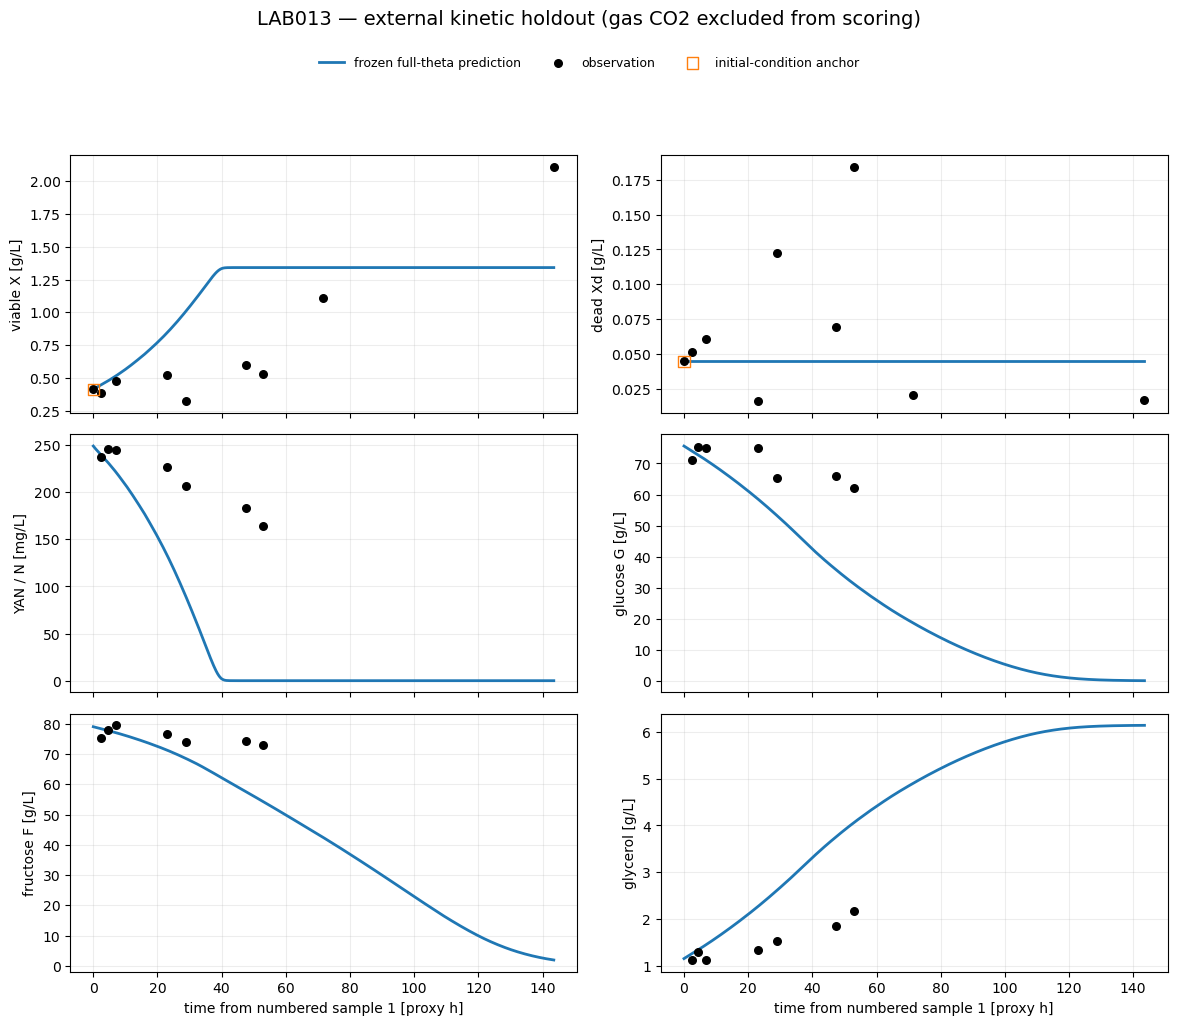

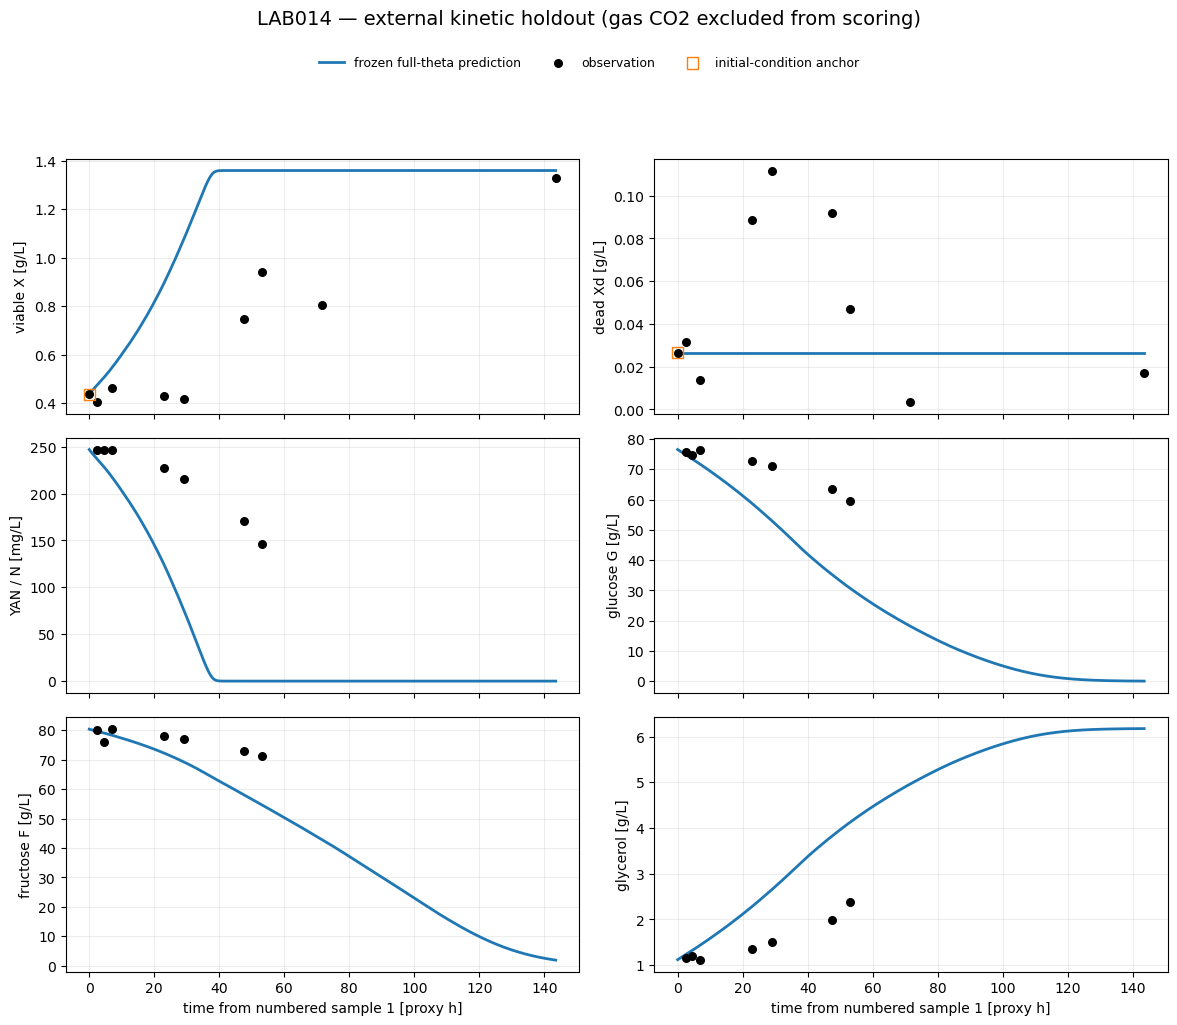

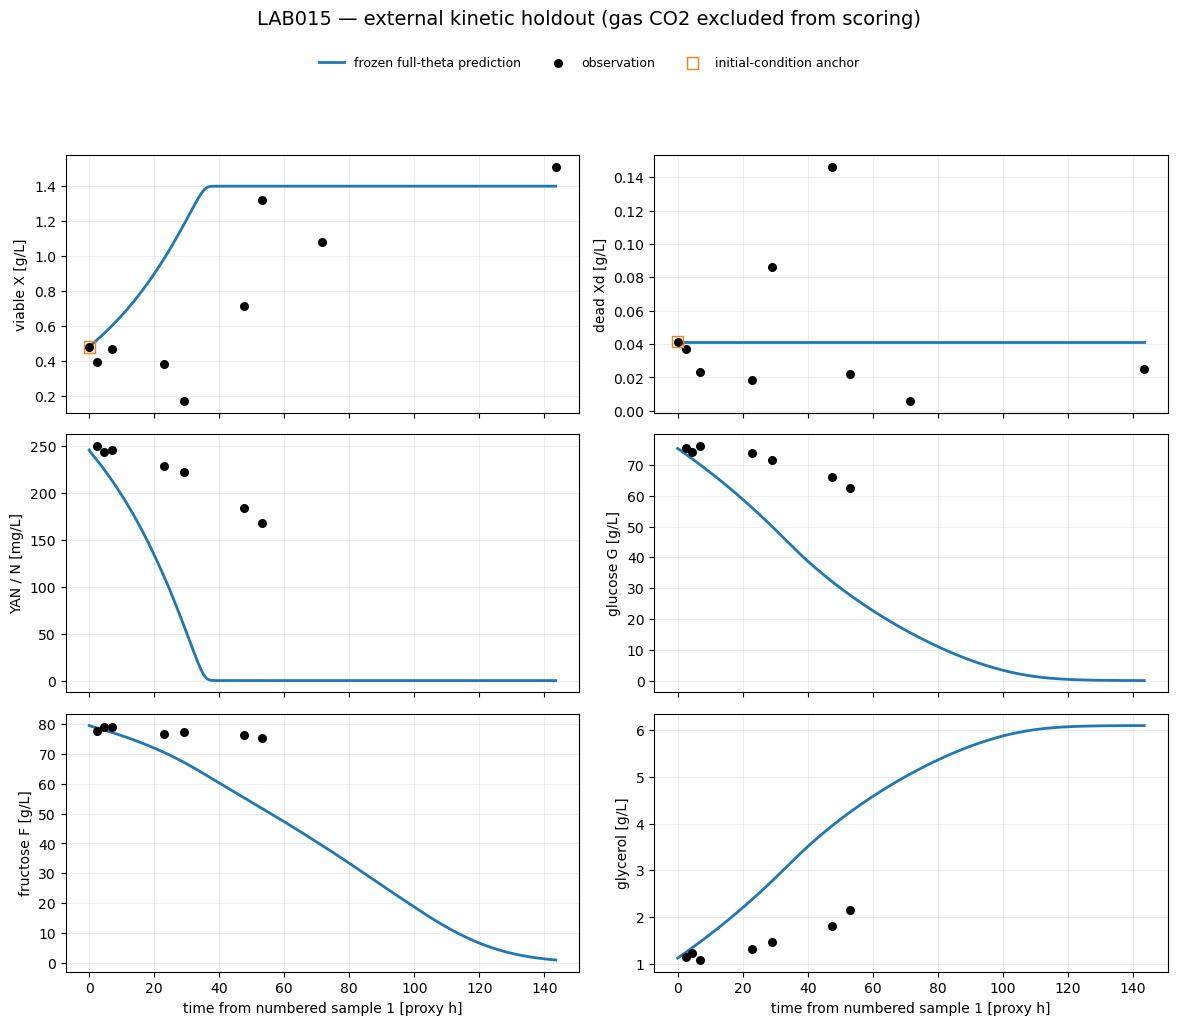

In [19]:
external_state_predictions = {
    lab: kinetic_base.simulate(batch, theta_natural_frozen, batch.time)
    for lab, batch in external_kinetic_batches.items()
}
assert all(frame is not None for frame in external_state_predictions.values())

point_rows = []
state_specs = {
    "G": ("glucose_g_L", 1.0, "g/L"),
    "F": ("fructose_g_L", 1.0, "g/L"),
    "N": ("YAN_mg_L", 1000.0, "mg/L"),
    "Gly": ("glycerol_g_L", 1.0, "g/L"),
}
for lab in EXTERNAL_KINETIC_LABS:
    sim = external_state_predictions[lab]
    chem = combined_13_15[combined_13_15["lab_id"].eq(lab)].sort_values("time_proxy_h")
    for state, (column, factor, unit) in state_specs.items():
        observed_rows = chem.dropna(subset=[column])
        for row in observed_rows.itertuples(index=False):
            predicted = factor * float(np.interp(row.time_proxy_h, sim.index, sim[state]))
            observed = float(getattr(row, column))
            point_rows.append({
                "batch": lab, "state": state, "unit": unit,
                "sample_id": row.sample_id, "time_proxy_h": float(row.time_proxy_h),
                "observed": observed, "predicted": predicted,
                "error_pred_minus_obs": predicted - observed,
                "initialization_anchor": False,
            })
    biomass = oculyze_13_15[oculyze_13_15["batch"].eq(lab)].sort_values("time_proxy_h")
    for state, column in (("X", "X_obs_g_l"), ("Xd", "Xd_obs_g_l")):
        for row in biomass.itertuples(index=False):
            predicted = float(np.interp(row.time_proxy_h, sim.index, sim[state]))
            observed = float(getattr(row, column))
            point_rows.append({
                "batch": lab, "state": state, "unit": "g/L",
                "sample_id": row.sample_id, "time_proxy_h": float(row.time_proxy_h),
                "observed": observed, "predicted": predicted,
                "error_pred_minus_obs": predicted - observed,
                "initialization_anchor": bool(abs(row.time_proxy_h) < 1e-9),
            })

external_state_point_errors = pd.DataFrame(point_rows)
metric_rows = []
for (lab, state), group in external_state_point_errors.groupby(["batch", "state"], sort=True):
    scored = group[~group["initialization_anchor"]].sort_values("time_proxy_h")
    observed = scored["observed"].to_numpy(float)
    predicted = scored["predicted"].to_numpy(float)
    error = predicted - observed
    observed_range = float(np.ptp(observed)) if len(observed) else np.nan
    ss_tot = float(np.sum((observed - observed.mean()) ** 2)) if len(observed) else np.nan
    metric_rows.append({
        "batch": lab, "state": state, "unit": scored["unit"].iloc[0], "n": len(scored),
        "rmse": float(np.sqrt(np.mean(error ** 2))),
        "nrmse_observed_range": float(np.sqrt(np.mean(error ** 2))) / observed_range if observed_range > 0 else np.nan,
        "bias_pred_minus_obs": float(np.mean(error)),
        "r2": 1.0 - float(np.sum(error ** 2)) / ss_tot if ss_tot > 0 else np.nan,
        "first_time_proxy_h": float(scored["time_proxy_h"].iloc[0]),
        "observed_initial": float(observed[0]), "predicted_initial": float(predicted[0]),
        "final_time_proxy_h": float(scored["time_proxy_h"].iloc[-1]),
        "observed_final": float(observed[-1]), "predicted_final": float(predicted[-1]),
    })
external_kinetic_metrics = pd.DataFrame(metric_rows)
display(external_kinetic_metrics.round(5))
display(external_state_point_errors.round(5))

state_labels = {
    "X": "viable X [g/L]", "Xd": "dead Xd [g/L]", "N": "YAN / N [mg/L]",
    "G": "glucose G [g/L]", "F": "fructose F [g/L]", "Gly": "glycerol [g/L]",
}
for lab in EXTERNAL_KINETIC_LABS:
    sim = external_state_predictions[lab]
    fig, axes = plt.subplots(3, 2, figsize=(12.5, 10.5), sharex=True)
    for ax, state in zip(axes.flat, ("X", "Xd", "N", "G", "F", "Gly")):
        factor = 1000.0 if state == "N" else 1.0
        points = external_state_point_errors[
            external_state_point_errors["batch"].eq(lab) & external_state_point_errors["state"].eq(state)
        ]
        ax.plot(sim.index, factor * sim[state], color="tab:blue", lw=2.0, label="frozen full-theta prediction")
        ax.scatter(points["time_proxy_h"], points["observed"], color="black", s=30, zorder=3, label="observation")
        anchors = points[points["initialization_anchor"]]
        if not anchors.empty:
            ax.scatter(anchors["time_proxy_h"], anchors["observed"], marker="s", facecolors="none",
                       edgecolors="tab:orange", s=65, zorder=4, label="initial-condition anchor")
        ax.set_ylabel(state_labels[state]); ax.grid(alpha=0.22)
    axes[-1, 0].set_xlabel("time from numbered sample 1 [proxy h]")
    axes[-1, 1].set_xlabel("time from numbered sample 1 [proxy h]")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(
        f"{lab} — external kinetic holdout (gas CO2 excluded from scoring)",
        y=0.992, fontsize=14,
    )
    fig.legend(
        handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.958),
        ncol=3, frameon=False, fontsize=9,
    )
    fig.tight_layout(rect=(0.025, 0.02, 0.975, 0.90))
    fig.savefig(analysis.PLOT_DIR / f"external_kinetic_holdout_{lab}_states.png", dpi=180, bbox_inches="tight")
    plt.show()


### Chemical bracket, activation gate and CO2-source chain

The bracket uses the unchanged historical rule on paired temporal G/F samples: the first point
where `G + F` has fallen by at least 5 g/L from the first temporal G/F observation, with the
previous temporal sample as the lower bound. Temporal ethanol is absent, so the ethanol rule is
not applied. Frozen CO2 parameters then place the smooth gate inside that measured bracket.

`qCO2_base → gate/O2 → qCO2_effective → dissolved pool → release` is shown without gas-phase
ground truth. Predicted release is a model diagnostic only.


,batch,chemical_activity_lower_proxy_h,chemical_activity_upper_proxy_h,bracket_width_h,criterion,gate_start_proxy_h,gate_end_proxy_h,gate_duration_h,qCO2_base_peak_g_l_h,qCO2_effective_peak_g_l_h,first_base_metabolic_qCO2_gt_0p005_proxy_h,first_effective_qCO2_after_gate_gt_0p005_proxy_h,first_gas_release_gt_0p005_proxy_h,predicted_gas_onset_over_operational_LOD_proxy_h,absolute_time_from_inoculation_valid
0,LAB013,23.0,29.0,6.0,G+F drop >= 5 g/L; temporal E unavailable,27.44945,30.19609,2.74664,0.30861,0.30861,0.0,27.64425,29.64951,31.74135,False
1,LAB014,2.5,4.5,2.0,G+F drop >= 5 g/L; temporal E unavailable,3.98315,4.89870,0.91555,0.31725,0.31725,0.0,4.07862,6.41435,10.68576,False
2,LAB015,29.0,47.5,18.5,G+F drop >= 5 g/L; temporal E unavailable,42.71913,51.18794,8.46881,0.32872,0.30897,0.0,43.34355,46.56876,49.49863,False


,batch,last_chemistry_proxy_h,observed_final_GplusF_g_l,predicted_final_GplusF_g_l,observed_final_YAN_mg_l,predicted_final_N_mg_l,observed_final_Gly_g_l,predicted_final_Gly_g_l,qCO2_effective_peak_proxy_h,qCO2_below_10pct_peak_proxy_h,mean_last12h_qCO2_over_peak,final_qgas_over_peak,absolute_termination_time_valid
0,LAB013,53.0,134.95,85.41639,164.0,0.0,2.16,4.06263,38.0,NaN,0.25009,0.31581,False
1,LAB014,53.0,130.71,85.48232,146.0,0.0,2.39,4.12406,37.5,NaN,0.24182,0.30534,False
2,LAB015,53.0,137.72,79.60117,168.0,0.0,2.15,4.24283,51.5,142.25,0.15217,0.22228,False


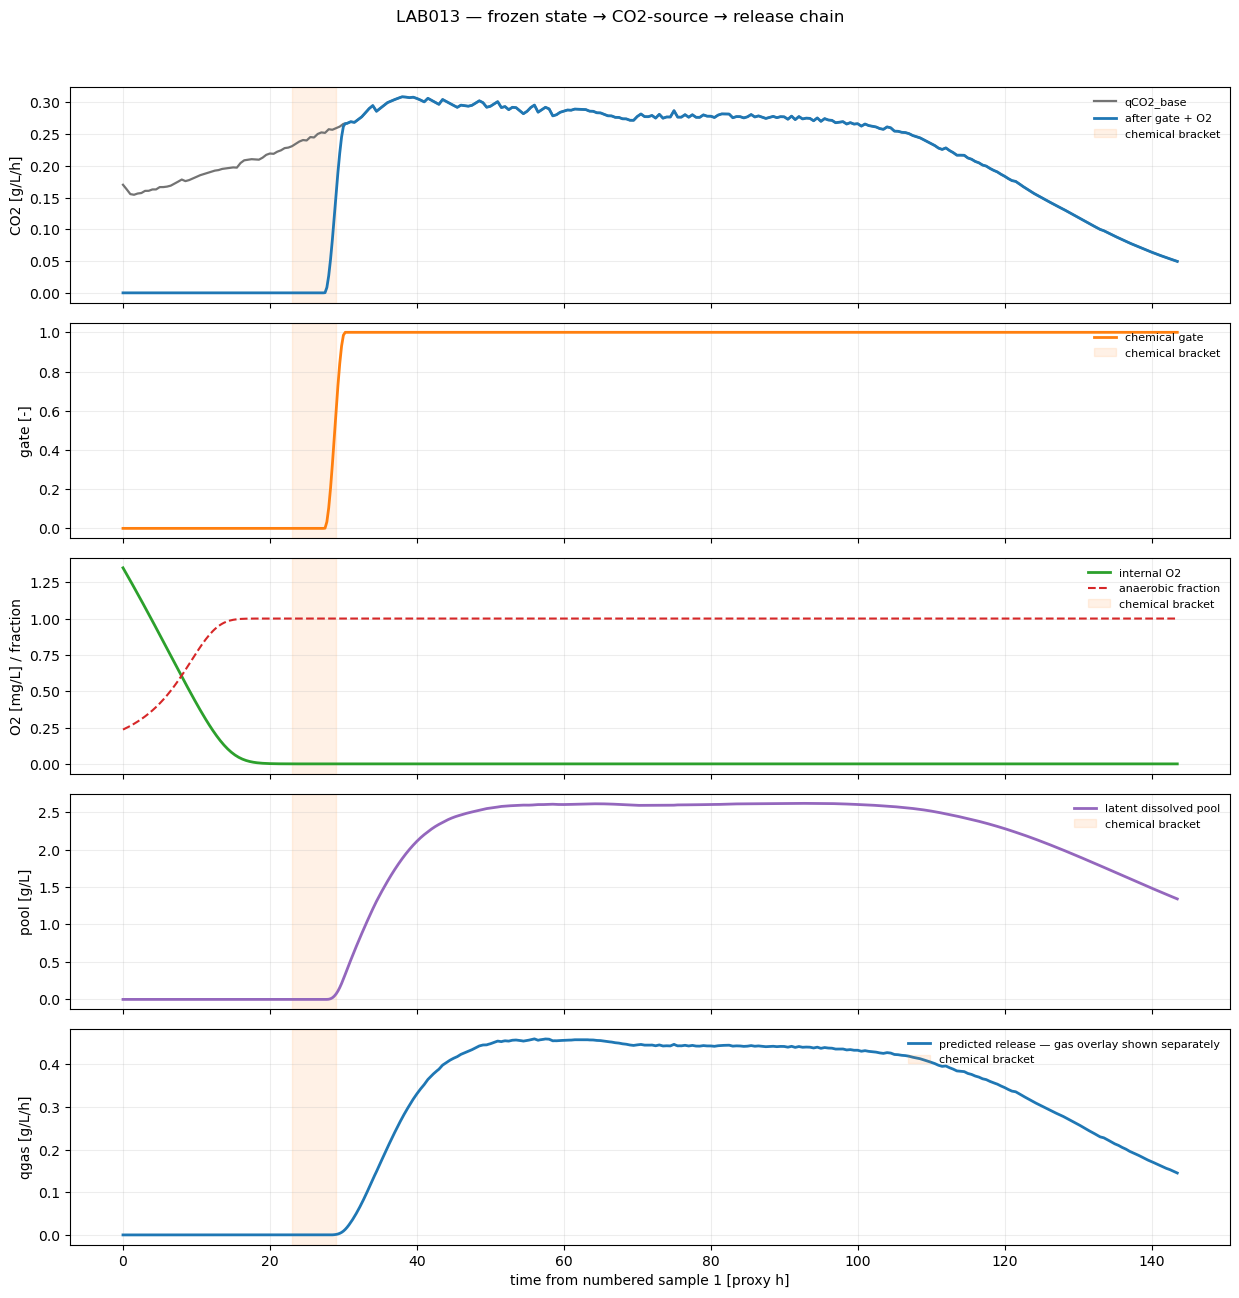

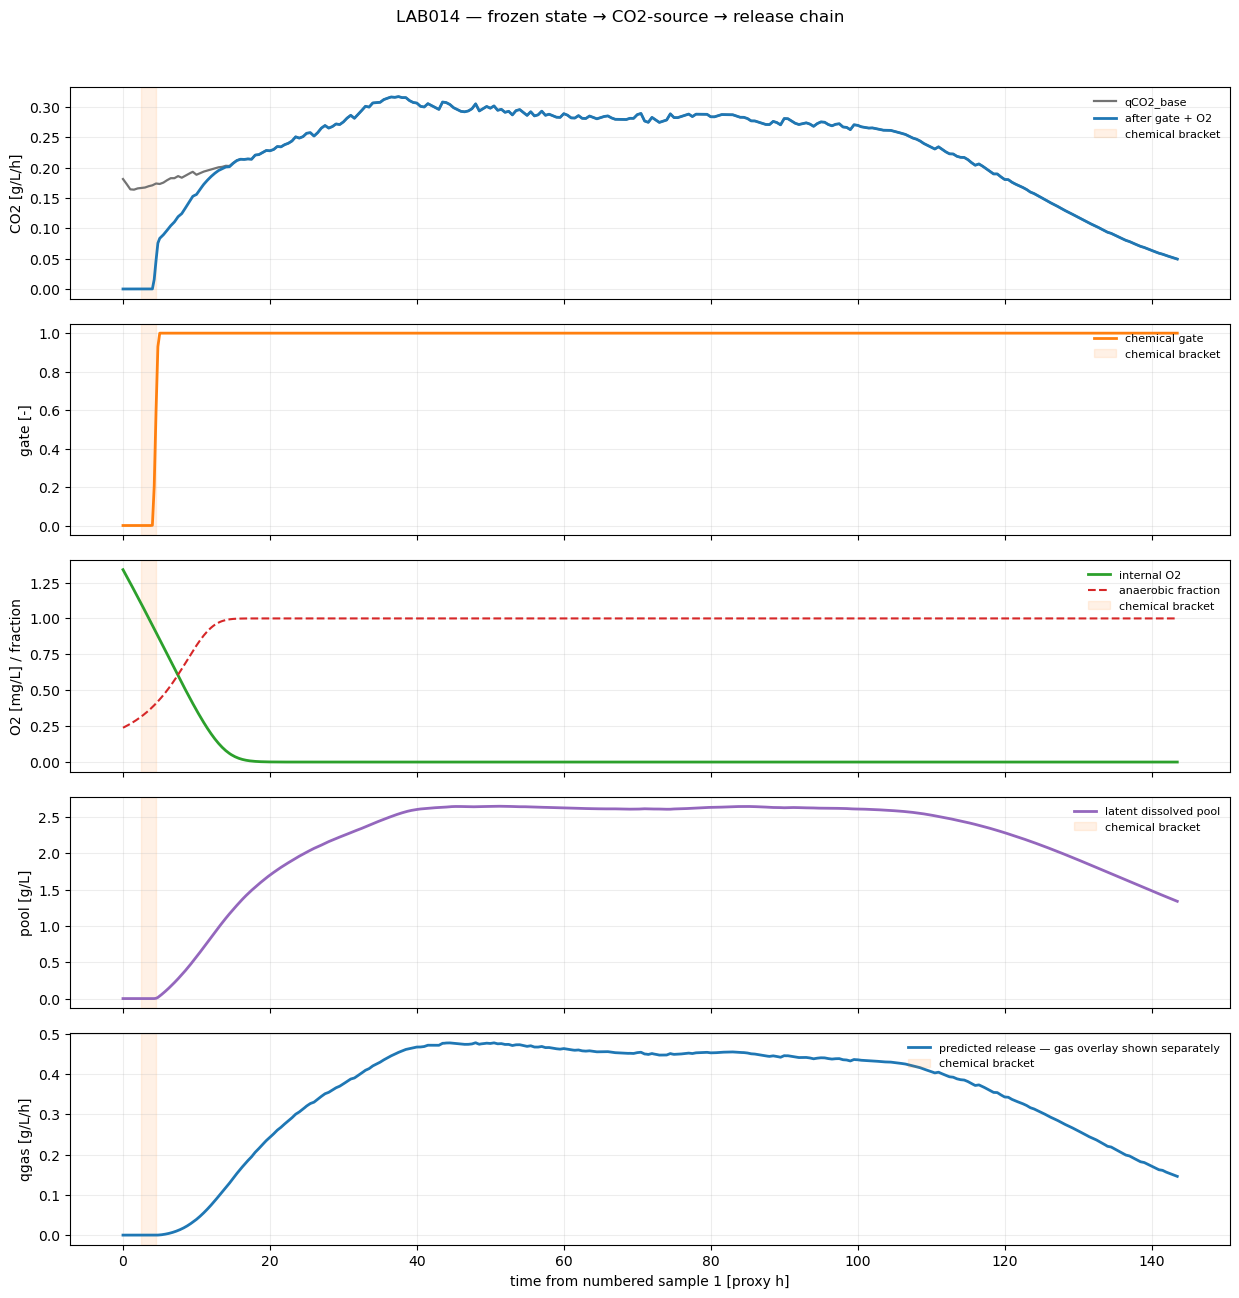

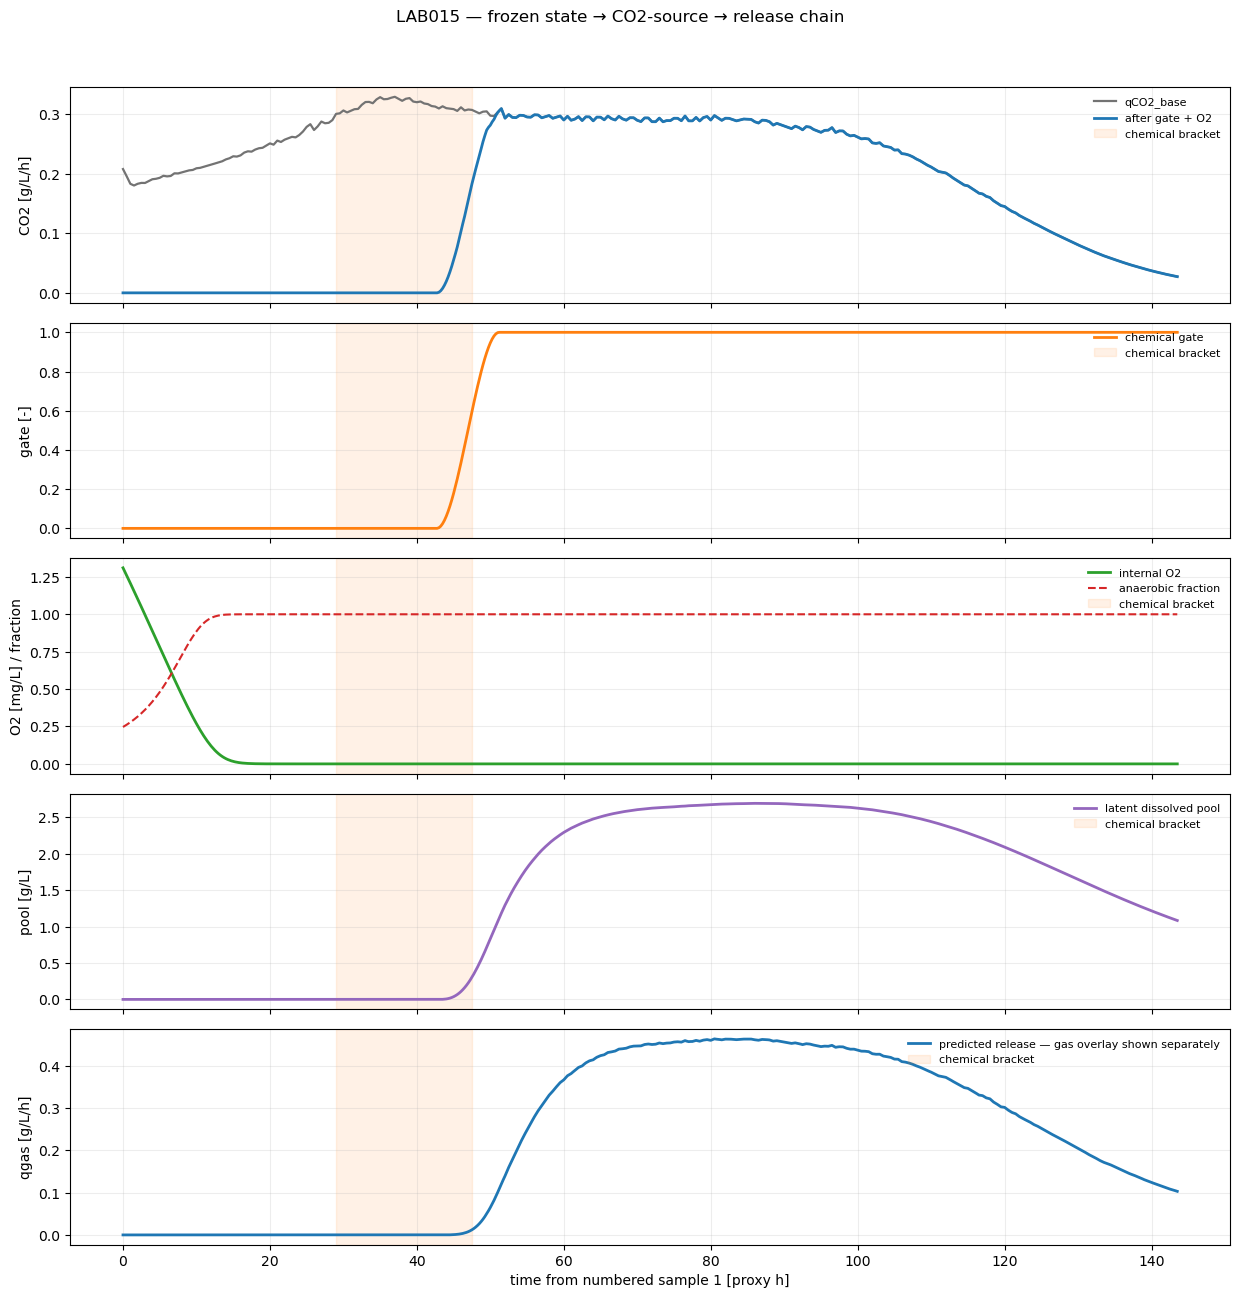

In [20]:
external_cache_support = pd.DataFrame([
    {
        "batch": lab, "matrix": "natural", "calibratable": True,
        "chemistry_last_h": float(batch.time[-1]), "t_h": 0.0,
    }
    for lab, batch in external_kinetic_batches.items()
])
external_driver_cache, external_driver_diagnostics = _historical.build_driver_cache(
    external_kinetic_batches, {"natural": theta_natural_frozen}, external_cache_support
)

activation_rows, chain_frames, termination_rows = [], [], []
for lab, cache in external_driver_cache.items():
    parameters = fixed_co2_parameters
    qgas_raw, qprod_effective, o2_internal, phi_ana = _historical.raw_qgas_grid_prediction(
        cache,
        parameters["kCO2_release_h"], parameters["CO2sat_scale"],
        parameters["O2_qmax_mg_gdw_h"], parameters["O2_initial_scale"],
        chemistry_aligned=True, nitrogen_boost_transition=True,
        pulse_t_rise_h=parameters["pulse_t_rise_h"],
        pulse_activity_gain=parameters["pulse_activity_gain"],
        continuous_release=True, bounded_chemical_activation=True,
        chem_activation_start_fraction=parameters["chem_activation_start_fraction"],
        chem_activation_duration_fraction=parameters["chem_activation_duration_fraction"],
    )
    driver = external_driver_diagnostics[external_driver_diagnostics["batch"].eq(lab)].iloc[0]
    lower_h, upper_h = float(driver.chemical_activity_lower_h), float(driver.chemical_activity_upper_h)
    width_h = upper_h - lower_h
    gate_start_h = lower_h + parameters["chem_activation_start_fraction"] * width_h
    gate_duration_h = max(parameters["chem_activation_duration_fraction"] * width_h, _historical.DRIVER_GRID_H)
    gate_end_h = gate_start_h + gate_duration_h
    gate = _historical._bounded_smoothstep_activation(
        cache.time_h, lower_h, upper_h,
        parameters["chem_activation_start_fraction"],
        parameters["chem_activation_duration_fraction"],
    )
    dissolved = np.zeros(len(cache.time_h), dtype=float)
    for idx in range(1, len(cache.time_h)):
        dt = float(cache.time_h[idx] - cache.time_h[idx - 1])
        dissolved[idx] = max(dissolved[idx - 1] + dt * (qprod_effective[idx - 1] - qgas_raw[idx]), 0.0)
    qgas_scaled = parameters["matrix_gain"] * qgas_raw

    chemistry = combined_13_15[
        combined_13_15["lab_id"].eq(lab) & combined_13_15["glucose_g_L"].notna()
        & combined_13_15["fructose_g_L"].notna()
    ].sort_values("time_proxy_h")
    sugar = chemistry["glucose_g_L"].to_numpy(float) + chemistry["fructose_g_L"].to_numpy(float)
    crossed = sugar <= sugar[0] - _historical.CHEMISTRY_SUGAR_DROP_G_L
    first_cross = int(np.flatnonzero(crossed)[0])
    assert np.isclose(lower_h, chemistry["time_proxy_h"].iloc[first_cross - 1])
    assert np.isclose(upper_h, chemistry["time_proxy_h"].iloc[first_cross])

    first_qprod_base = _historical._sustained_onset_h(
        cache.time_h, cache.base_qprod_g_l_h,
        _historical.EARLY_EMISSION_THRESHOLD_G_L_H, consecutive=2
    )
    first_qprod_effective = _historical._sustained_onset_h(
        cache.time_h, qprod_effective,
        _historical.EARLY_EMISSION_THRESHOLD_G_L_H, consecutive=2
    )
    first_qgas = _historical._sustained_onset_h(
        cache.time_h, qgas_scaled, _historical.EARLY_EMISSION_THRESHOLD_G_L_H, consecutive=2
    )
    gas_detectable = _historical._sustained_onset_h(
        cache.time_h, qgas_scaled, _historical.CO2_DETECTION_LIMIT_G_L_H, consecutive=3
    )
    activation_rows.append({
        "batch": lab,
        "chemical_activity_lower_proxy_h": lower_h,
        "chemical_activity_upper_proxy_h": upper_h,
        "bracket_width_h": width_h,
        "criterion": "G+F drop >= 5 g/L; temporal E unavailable",
        "gate_start_proxy_h": gate_start_h,
        "gate_end_proxy_h": gate_end_h,
        "gate_duration_h": gate_duration_h,
        "qCO2_base_peak_g_l_h": float(np.max(cache.base_qprod_g_l_h)),
        "qCO2_effective_peak_g_l_h": float(np.max(qprod_effective)),
        "first_base_metabolic_qCO2_gt_0p005_proxy_h": first_qprod_base,
        "first_effective_qCO2_after_gate_gt_0p005_proxy_h": first_qprod_effective,
        "first_gas_release_gt_0p005_proxy_h": first_qgas,
        "predicted_gas_onset_over_operational_LOD_proxy_h": gas_detectable,
        "absolute_time_from_inoculation_valid": False,
    })
    sim = external_state_predictions[lab]
    chain = pd.DataFrame({
        "batch": lab, "time_proxy_h": cache.time_h,
        "qCO2_base_g_l_h": cache.base_qprod_g_l_h,
        "chemical_gate": gate,
        "o2_internal_mg_l": o2_internal,
        "anaerobic_fraction": phi_ana,
        "qCO2_effective_g_l_h": qprod_effective,
        "dissolved_CO2_pool_g_l": dissolved,
        "qgas_release_raw_g_l_h": qgas_raw,
        "qgas_release_scaled_g_l_h": qgas_scaled,
    })
    for state in kinetic_base.STATE_NAMES:
        chain[state] = np.interp(cache.time_h, sim.index, sim[state])
    chain_frames.append(chain)

    peak_idx = int(np.argmax(qprod_effective))
    post_peak = np.arange(len(qprod_effective)) >= peak_idx
    below_tail = post_peak & (qprod_effective <= 0.10 * max(float(np.max(qprod_effective)), 1e-12))
    tail_time = float(cache.time_h[np.flatnonzero(below_tail)[0]]) if below_tail.any() else np.nan
    last_12 = cache.time_h >= cache.time_h[-1] - 12.0
    points = external_state_point_errors[external_state_point_errors["batch"].eq(lab)]
    def _final_pair(state):
        row = points[points["state"].eq(state)].sort_values("time_proxy_h").iloc[-1]
        return float(row.observed), float(row.predicted), float(row.time_proxy_h)
    g_obs, g_pred, g_t = _final_pair("G")
    f_obs, f_pred, f_t = _final_pair("F")
    n_obs, n_pred, n_t = _final_pair("N")
    gly_obs, gly_pred, gly_t = _final_pair("Gly")
    termination_rows.append({
        "batch": lab, "last_chemistry_proxy_h": max(g_t, f_t, n_t, gly_t),
        "observed_final_GplusF_g_l": g_obs + f_obs,
        "predicted_final_GplusF_g_l": g_pred + f_pred,
        "observed_final_YAN_mg_l": n_obs, "predicted_final_N_mg_l": n_pred,
        "observed_final_Gly_g_l": gly_obs, "predicted_final_Gly_g_l": gly_pred,
        "qCO2_effective_peak_proxy_h": float(cache.time_h[peak_idx]),
        "qCO2_below_10pct_peak_proxy_h": tail_time,
        "mean_last12h_qCO2_over_peak": float(np.mean(qprod_effective[last_12]) / max(np.max(qprod_effective), 1e-12)),
        "final_qgas_over_peak": float(qgas_scaled[-1] / max(np.max(qgas_scaled), 1e-12)),
        "absolute_termination_time_valid": False,
    })

external_activation_summary = pd.DataFrame(activation_rows)
external_chain_trajectories = pd.concat(chain_frames, ignore_index=True)
external_termination_summary = pd.DataFrame(termination_rows)
display(external_activation_summary.round(5))
display(external_termination_summary.round(5))

for lab in EXTERNAL_KINETIC_LABS:
    chain = external_chain_trajectories[external_chain_trajectories["batch"].eq(lab)]
    summary = external_activation_summary.set_index("batch").loc[lab]
    fig, axes = plt.subplots(5, 1, figsize=(12.5, 13), sharex=True)
    axes[0].plot(chain["time_proxy_h"], chain["qCO2_base_g_l_h"], color="0.45", lw=1.6, label="qCO2_base")
    axes[0].plot(chain["time_proxy_h"], chain["qCO2_effective_g_l_h"], color="tab:blue", lw=2.0, label="after gate + O2")
    axes[1].plot(chain["time_proxy_h"], chain["chemical_gate"], color="tab:orange", lw=2.0, label="chemical gate")
    axes[2].plot(chain["time_proxy_h"], chain["o2_internal_mg_l"], color="tab:green", lw=2.0, label="internal O2")
    axes[2].plot(chain["time_proxy_h"], chain["anaerobic_fraction"], color="tab:red", lw=1.5, ls="--", label="anaerobic fraction")
    axes[3].plot(chain["time_proxy_h"], chain["dissolved_CO2_pool_g_l"], color="tab:purple", lw=2.0, label="latent dissolved pool")
    axes[4].plot(chain["time_proxy_h"], chain["qgas_release_scaled_g_l_h"], color="tab:blue", lw=2.0, label="predicted release — gas overlay shown separately")
    for ax in axes:
        ax.axvspan(summary.chemical_activity_lower_proxy_h, summary.chemical_activity_upper_proxy_h,
                   color="tab:orange", alpha=0.10, label="chemical bracket")
        ax.grid(alpha=0.22); ax.legend(frameon=False, fontsize=8, loc="upper right")
    axes[0].set_ylabel("CO2 [g/L/h]"); axes[1].set_ylabel("gate [-]")
    axes[2].set_ylabel("O2 [mg/L] / fraction")
    axes[3].set_ylabel("pool [g/L]"); axes[4].set_ylabel("qgas [g/L/h]")
    axes[-1].set_xlabel("time from numbered sample 1 [proxy h]")
    fig.suptitle(f"{lab} — frozen state → CO2-source → release chain", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(analysis.PLOT_DIR / f"external_activation_chain_{lab}.png", dpi=180, bbox_inches="tight")
    plt.show()


### Exploratory gas-phase CO2 overlay — visualization only

This is the requested visual comparison, not a validation score. The documented-unreliable
`CO2_FILT_*` signal is aligned to the same sample-1 proxy clock, corrected with the current
run-specific initial-12-h q10 zero rule, converted with `SCCM_CORRECTED` at the documented 2 L
reactor volume, aggregated hourly and passed through the current median + Savitzky–Golay
smoothing. No additional transient repair is inferred for these LABs.

The observed curve is not passed to the optimizer and is not used for RMSE, integral, peak,
onset or parameter conclusions. The orange band is the G+F chemical bracket; it is provided
only as temporal context. Because inoculation t0 remains unresolved, the horizontal coordinate
is still time from numbered sample 1 rather than biological age.


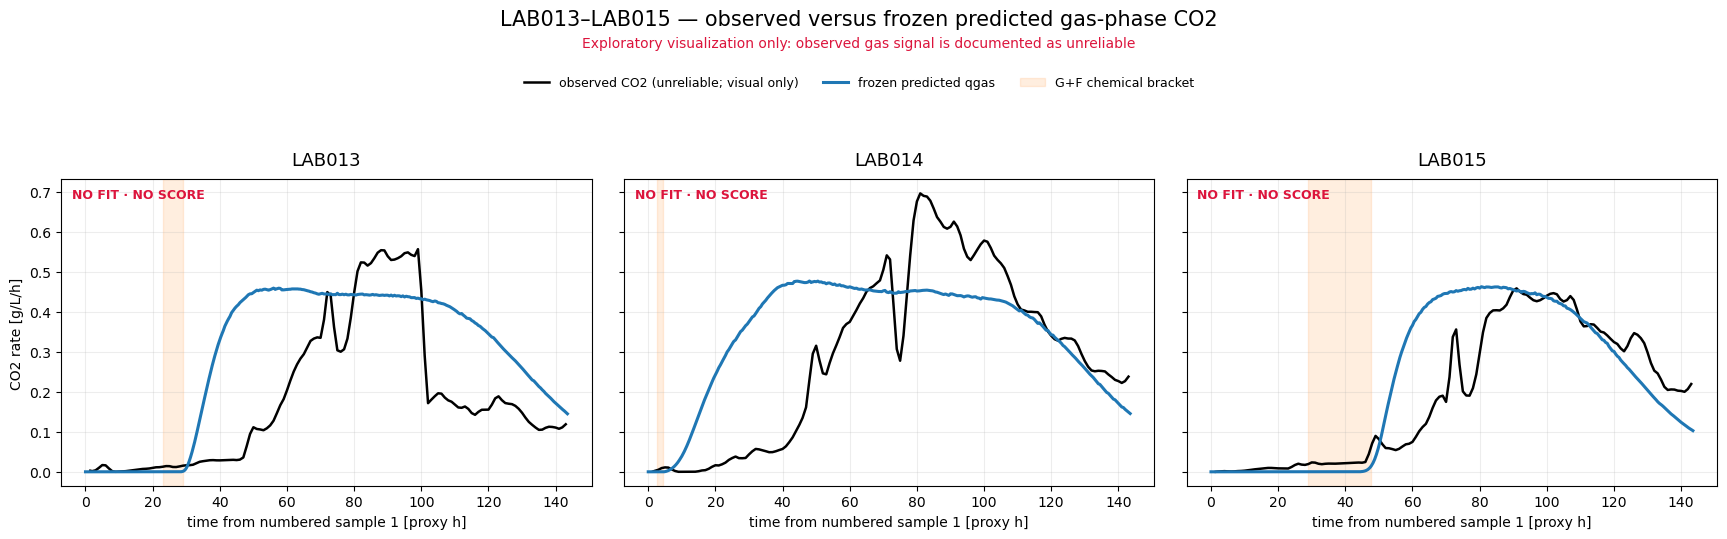

,batch,source_file,n_raw,n_hourly,first_time_proxy_h,last_time_proxy_h,sensor_zero_offset_sccm,sccm_factor_g_l_h_per_sccm,used_in_fit,used_in_metrics,reliability
0,LAB013,fermentation_model/data/mem2026/LAB013-015/CO2...,48809,143,1.375000,143.498889,0.000,0.040439,False,False,documented unreliable; visualization only
1,LAB014,fermentation_model/data/mem2026/LAB013-015/CO2...,48807,143,1.380556,143.498889,0.000,0.040439,False,False,documented unreliable; visualization only
2,LAB015,fermentation_model/data/mem2026/LAB013-015/CO2...,48806,143,1.383611,143.498889,0.214,0.040439,False,False,documented unreliable; visualization only


In [21]:
external_gas_frames = []
external_gas_audit_rows = []
for lab in EXTERNAL_KINETIC_LABS:
    raw_gas = pd.read_csv(
        GAS_PATHS_EXCLUDED[lab],
        usecols=["timestamp", "flow_filt_sccm", "status", "is_spike"],
    )
    raw_gas["timestamp"] = pd.to_datetime(raw_gas["timestamp"], errors="raise")
    raw_gas["flow_filt_sccm"] = pd.to_numeric(raw_gas["flow_filt_sccm"], errors="coerce")
    raw_gas["is_spike"] = pd.to_numeric(raw_gas["is_spike"], errors="coerce").fillna(0)
    raw_gas = raw_gas.dropna(subset=["timestamp", "flow_filt_sccm"]).sort_values("timestamp")
    raw_gas["batch"] = lab
    raw_gas["time_proxy_h"] = (
        raw_gas["timestamp"] - proxy_t0_by_lab[lab]
    ).dt.total_seconds() / 3600.0
    prediction_horizon = float(
        external_chain_trajectories.loc[
            external_chain_trajectories["batch"].eq(lab), "time_proxy_h"
        ].max()
    )
    raw_gas = raw_gas[raw_gas["time_proxy_h"].between(0.0, prediction_horizon)].copy()
    first_available_h = float(raw_gas["time_proxy_h"].min())
    zero_candidates = raw_gas.loc[
        raw_gas["time_proxy_h"].le(first_available_h + _historical.SENSOR_ZERO_WINDOW_H),
        "flow_filt_sccm",
    ]
    zero_offset_sccm = max(
        0.0, float(zero_candidates.quantile(_historical.SENSOR_ZERO_QUANTILE))
    )
    raw_gas["zero_corrected_sccm"] = (
        raw_gas["flow_filt_sccm"] - zero_offset_sccm
    ).clip(lower=0.0)
    raw_gas["co2_rate_zero_corrected_g_l_h"] = (
        raw_gas["zero_corrected_sccm"] * analysis.SCCM_FACTOR_G_L_H_PER_SCCM
    )
    raw_gas["time_bin_h"] = (
        raw_gas["time_proxy_h"] / _historical.OBSERVATION_BIN_H
    ).round() * _historical.OBSERVATION_BIN_H
    hourly_gas = (
        raw_gas.groupby("time_bin_h", as_index=False)
        .agg(
            time_proxy_h=("time_proxy_h", "median"),
            flow_filt_sccm=("flow_filt_sccm", "median"),
            zero_corrected_sccm=("zero_corrected_sccm", "median"),
            co2_rate_filtered_g_l_h=("co2_rate_zero_corrected_g_l_h", "median"),
            spike_fraction=("is_spike", "mean"),
            n_raw=("timestamp", "size"),
        )
        .sort_values("time_proxy_h")
    )
    hourly_gas["matrix"] = "natural"
    hourly_gas["batch"] = lab
    hourly_gas["t_h"] = hourly_gas["time_proxy_h"]
    hourly_gas = _historical.smooth_hourly_co2_profiles(
        hourly_gas,
        pd.DataFrame(columns=["batch", "pulse_time_h"]),
    )
    hourly_gas["co2_observed_exploratory_g_l_h"] = hourly_gas[
        "co2_rate_smoothed_g_l_h"
    ]
    hourly_gas["sensor_zero_offset_sccm"] = zero_offset_sccm
    hourly_gas["sccm_conversion"] = "SCCM_CORRECTED"
    hourly_gas["used_in_fit"] = False
    hourly_gas["used_in_metrics"] = False
    external_gas_frames.append(hourly_gas)
    external_gas_audit_rows.append({
        "batch": lab,
        "source_file": GAS_PATHS_EXCLUDED[lab].relative_to(ROOT).as_posix(),
        "n_raw": len(raw_gas),
        "n_hourly": len(hourly_gas),
        "first_time_proxy_h": first_available_h,
        "last_time_proxy_h": float(raw_gas["time_proxy_h"].max()),
        "sensor_zero_offset_sccm": zero_offset_sccm,
        "sccm_factor_g_l_h_per_sccm": analysis.SCCM_FACTOR_G_L_H_PER_SCCM,
        "used_in_fit": False,
        "used_in_metrics": False,
        "reliability": "documented unreliable; visualization only",
    })

external_gas_observed = pd.concat(external_gas_frames, ignore_index=True)
external_gas_plot_audit = pd.DataFrame(external_gas_audit_rows)
assert not external_gas_observed["used_in_fit"].any()
assert not external_gas_observed["used_in_metrics"].any()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), sharex=True, sharey=True)
for ax, lab in zip(axes, EXTERNAL_KINETIC_LABS):
    observed = external_gas_observed[external_gas_observed["batch"].eq(lab)]
    predicted = external_chain_trajectories[
        external_chain_trajectories["batch"].eq(lab)
    ]
    bracket = external_activation_summary.set_index("batch").loc[lab]
    ax.plot(
        observed["time_proxy_h"], observed["co2_observed_exploratory_g_l_h"],
        color="black", lw=1.8, label="observed CO2 (unreliable; visual only)",
    )
    ax.plot(
        predicted["time_proxy_h"], predicted["qgas_release_scaled_g_l_h"],
        color="tab:blue", lw=2.2, label="frozen predicted qgas",
    )
    ax.axvspan(
        bracket.chemical_activity_lower_proxy_h,
        bracket.chemical_activity_upper_proxy_h,
        color="tab:orange", alpha=0.13, label="G+F chemical bracket",
    )
    ax.set_title(lab, fontsize=13, pad=10)
    ax.set_xlabel("time from numbered sample 1 [proxy h]")
    ax.grid(alpha=0.22)
    ax.text(
        0.02, 0.97, "NO FIT · NO SCORE",
        transform=ax.transAxes, ha="left", va="top",
        color="crimson", fontsize=9, fontweight="bold",
    )
axes[0].set_ylabel("CO2 rate [g/L/h]")
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    "LAB013–LAB015 — observed versus frozen predicted gas-phase CO2",
    y=0.985, fontsize=15,
)
fig.text(
    0.5, 0.925,
    "Exploratory visualization only: observed gas signal is documented as unreliable",
    ha="center", va="center", color="crimson", fontsize=10,
)
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.885),
    ncol=3, frameon=False, fontsize=9,
)
fig.tight_layout(rect=(0.02, 0.03, 0.985, 0.82), w_pad=2.0)
fig.savefig(
    analysis.PLOT_DIR / "external_gas_curve_comparison_LAB013_015.png",
    dpi=180, bbox_inches="tight",
)
plt.show()
display(external_gas_plot_audit.round(6))


### Exploratory dissolved-CO2 and DO comparison

Carbodoseur CO2 and model pool share mass-concentration units after conversion, and measured DO
and internal O2 share mg/L units. Nevertheless, neither pair has a validated observation function:
the model pool is a latent well-mixed balance with zero initial pool, and the internal O2 model
omits probe dynamics and reaeration. The overlays below are therefore exploratory and deliberately
carry no RMSE, R² or fitting weight. Brix and density remain contextual observations because no
validated mapping to an individual model state exists.


,observed,model,direct_observation_function_validated,scored,note
0,Carbodoseur dissolved CO2 [g/L],latent dissolved CO2 pool [g/L],False,False,NaN
1,offline DO [mg/L],internal depletion-only O2 [mg/L],False,False,NaN
2,Brix / density,none,False,False,NaN
3,gas-phase CO2,qgas release,False,False,documented unreliable; loaded only for explora...


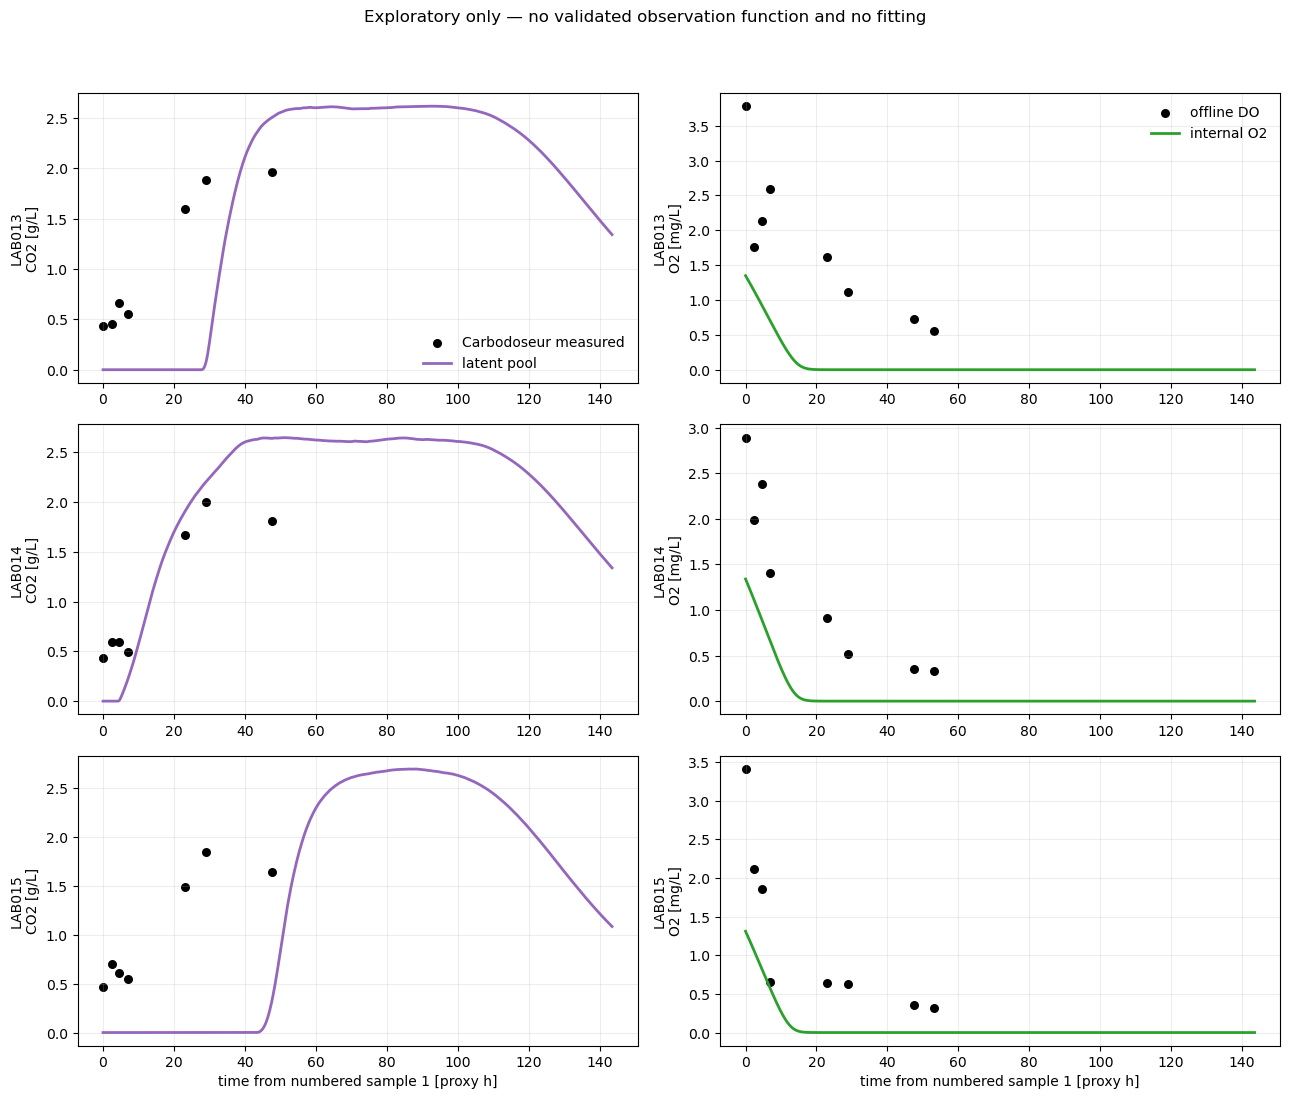

,batch,X,Xd,N,G,F,E,Gly,temperature_min_c,temperature_mean_c,temperature_max_c,chemical_activity_lower_proxy_h,chemical_activity_upper_proxy_h,bracket_width_h,criterion,gate_start_proxy_h,gate_end_proxy_h,gate_duration_h,qCO2_base_peak_g_l_h,qCO2_effective_peak_g_l_h,first_base_metabolic_qCO2_gt_0p005_proxy_h,first_effective_qCO2_after_gate_gt_0p005_proxy_h,first_gas_release_gt_0p005_proxy_h,predicted_gas_onset_over_operational_LOD_proxy_h,absolute_time_from_inoculation_valid
0,LAB013,0.41135,0.04495,0.249,75.62,79.03,0.0,1.15,15.6,16.01574,19.2,23.0,29.0,6.0,G+F drop >= 5 g/L; temporal E unavailable,27.44945,30.19609,2.74664,0.30861,0.30861,0.0,27.64425,29.64951,31.74135,False
1,LAB014,0.43670,0.02650,0.247,76.54,80.38,0.0,1.12,15.6,16.03661,19.4,2.5,4.5,2.0,G+F drop >= 5 g/L; temporal E unavailable,3.98315,4.89870,0.91555,0.31725,0.31725,0.0,4.07862,6.41435,10.68576,False
2,LAB015,0.47934,0.04146,0.246,75.32,79.45,0.0,1.12,15.6,16.01957,20.4,29.0,47.5,18.5,G+F drop >= 5 g/L; temporal E unavailable,42.71913,51.18794,8.46881,0.32872,0.30897,0.0,43.34355,46.56876,49.49863,False


,candidate,correlation_with_gate_start_proxy,n,interpretation
0,temperature_mean_c,-0.83915,3,descriptive only; n=3 and inoculation t0 unres...
1,X,0.52081,3,descriptive only; n=3 and inoculation t0 unres...
2,N,-0.21032,3,descriptive only; n=3 and inoculation t0 unres...
3,G,-0.98661,3,descriptive only; n=3 and inoculation t0 unres...
4,F,-0.75779,3,descriptive only; n=3 and inoculation t0 unres...


In [22]:
exploratory_mapping = pd.DataFrame([
    {"observed": "Carbodoseur dissolved CO2 [g/L]", "model": "latent dissolved CO2 pool [g/L]",
     "direct_observation_function_validated": False, "scored": False},
    {"observed": "offline DO [mg/L]", "model": "internal depletion-only O2 [mg/L]",
     "direct_observation_function_validated": False, "scored": False},
    {"observed": "Brix / density", "model": "none", "direct_observation_function_validated": False, "scored": False},
    {"observed": "gas-phase CO2", "model": "qgas release", "direct_observation_function_validated": False,
     "scored": False, "note": "documented unreliable; loaded only for exploratory overlay"},
])
display(exploratory_mapping)

fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=False)
for row, lab in enumerate(EXTERNAL_KINETIC_LABS):
    off = offline_13_15[offline_13_15["lab_id"].eq(lab)].sort_values("time_proxy_h")
    chain = external_chain_trajectories[external_chain_trajectories["batch"].eq(lab)]
    axes[row, 0].scatter(off["time_proxy_h"], pd.to_numeric(off["CO2_dissolved_actualT_mg_L"], errors="coerce") * 1e-3,
                         color="black", s=30, label="Carbodoseur measured")
    axes[row, 0].plot(chain["time_proxy_h"], chain["dissolved_CO2_pool_g_l"], color="tab:purple", lw=2.0, label="latent pool")
    axes[row, 1].scatter(off["time_proxy_h"], pd.to_numeric(off["DO_value"], errors="coerce"),
                         color="black", s=30, label="offline DO")
    axes[row, 1].plot(chain["time_proxy_h"], chain["o2_internal_mg_l"], color="tab:green", lw=2.0, label="internal O2")
    axes[row, 0].set_ylabel(f"{lab}\nCO2 [g/L]")
    axes[row, 1].set_ylabel(f"{lab}\nO2 [mg/L]")
    for ax in axes[row]: ax.grid(alpha=0.22)
axes[0, 0].legend(frameon=False); axes[0, 1].legend(frameon=False)
axes[-1, 0].set_xlabel("time from numbered sample 1 [proxy h]")
axes[-1, 1].set_xlabel("time from numbered sample 1 [proxy h]")
fig.suptitle("Exploratory only — no validated observation function and no fitting", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(analysis.PLOT_DIR / "external_exploratory_dissolved_CO2_DO_LAB013_015.png", dpi=180, bbox_inches="tight")
plt.show()

external_temperature_summary = external_temperature_inputs.groupby("batch", as_index=False).agg(
    temperature_min_c=("temperature_c", "min"),
    temperature_mean_c=("temperature_c", "mean"),
    temperature_max_c=("temperature_c", "max"),
)
conditions_and_activation = external_initial_conditions.merge(
    external_temperature_summary, on="batch", validate="one_to_one",
).merge(external_activation_summary, on="batch", validate="one_to_one")
descriptive_correlations = pd.DataFrame([
    {
        "candidate": candidate,
        "correlation_with_gate_start_proxy": conditions_and_activation[[candidate, "gate_start_proxy_h"]].corr().iloc[0, 1],
        "n": len(conditions_and_activation),
        "interpretation": "descriptive only; n=3 and inoculation t0 unresolved",
    }
    for candidate in ("temperature_mean_c", "X", "N", "G", "F")
])
display(conditions_and_activation.round(5))
display(descriptive_correlations.round(5))


### Artifacts, safeguards and interpretation

All LAB013–LAB015 outputs are diagnostic tables/figures. They are never added to the CO2
calibration objective. The assertions below preserve the existing fit membership and write an
explicit manifest. Old LAB016–LAB018 result files from an earlier execution, if present in the
results directory, are superseded and are not referenced by this notebook.


In [23]:
assert fit_batches_b == ["LAB004", "LAB005", "LAB006", "LAB007", "LAB008", "LAB011"]
assert analysis.HOLDOUTS["natural"] == "LAB012"
assert SENSITIVITY_EXCLUDED_BATCH == "LAB010"
assert len(theta_natural_frozen) == 17
assert not any(lab in result["observations"]["batch"].unique() for lab in EXTERNAL_KINETIC_LABS)

tables_to_save = {
    "sensitivity_calibration_inventory.csv": sensitivity_inventory,
    "sensitivity_objectives_A_vs_B.csv": sensitivity_objectives,
    "sensitivity_parameters_A_vs_B.csv": sensitivity_parameters_long,
    "sensitivity_parameter_changes_A_vs_B.csv": sensitivity_parameter_changes,
    "sensitivity_batch_metrics_A_vs_B.csv": sensitivity_metrics_long,
    "sensitivity_batch_metric_changes_A_vs_B.csv": sensitivity_metric_changes,
    "sensitivity_identifiability_A_vs_B.csv": sensitivity_identifiability,
    "sensitivity_local_parameter_correlations_A_vs_B.csv": sensitivity_correlations,
    "sensitivity_activation_profiles_A_vs_B.csv": sensitivity_profiles,
    "sensitivity_loo_summary_A_vs_B.csv": sensitivity_loo_summary,
    "sensitivity_loo_estimates_A_vs_B.csv": sensitivity_loo_estimates,
    "signal_swap_observation_audit.csv": signal_swap_audit,
    "signals_repaired_vs_previous_parameters.csv": signal_parameters_long,
    "signals_repaired_vs_previous_parameter_changes.csv": signal_parameter_changes,
    "signals_repaired_vs_previous_objectives.csv": signal_objectives,
    "signals_repaired_vs_previous_batch_metrics.csv": signal_metrics_long,
    "signals_repaired_vs_previous_batch_metric_changes.csv": signal_metric_changes,
    "signals_repaired_vs_previous_identifiability.csv": signal_identifiability,
    "signals_repaired_vs_previous_local_correlations.csv": signal_correlations,
    "signals_repaired_vs_previous_loo_summary.csv": signal_loo_summary,
    "signals_repaired_vs_previous_loo_estimates.csv": signal_loo_estimates,
    "external_kinetic_holdout_source_audit_LAB013_015.csv": external_source_audit.drop(columns="path"),
    "external_kinetic_holdout_t0_audit_LAB013_015.csv": t0_audit,
    "external_kinetic_holdout_initial_conditions_LAB013_015.csv": external_initial_conditions,
    "external_kinetic_holdout_state_coverage_LAB013_015.csv": external_state_coverage,
    "external_kinetic_holdout_metrics_LAB013_015.csv": external_kinetic_metrics,
    "external_kinetic_holdout_point_errors_LAB013_015.csv": external_state_point_errors,
    "external_activation_brackets_LAB013_015.csv": external_activation_summary,
    "external_activation_chain_LAB013_015.csv": external_chain_trajectories,
    "external_kinetic_termination_LAB013_015.csv": external_termination_summary,
    "external_initial_conditions_activation_LAB013_015.csv": conditions_and_activation,
    "external_activation_descriptive_correlations_LAB013_015.csv": descriptive_correlations,
    "external_exploratory_mapping_LAB013_015.csv": exploratory_mapping,
    "external_exploratory_gas_CO2_hourly_LAB013_015.csv": external_gas_observed,
    "external_exploratory_gas_CO2_audit_LAB013_015.csv": external_gas_plot_audit,
}
SENSITIVITY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
analysis.PLOT_DIR.mkdir(parents=True, exist_ok=True)
for filename, frame in tables_to_save.items():
    frame.to_csv(SENSITIVITY_RESULTS_DIR / filename, index=False)


In [24]:
from IPython.display import Markdown

mean_state = external_kinetic_metrics.groupby("state").agg(
    mean_nrmse=("nrmse_observed_range", "mean"), mean_bias=("bias_pred_minus_obs", "mean")
)
bracket_text = "; ".join(
    f"{row.batch}: [{row.chemical_activity_lower_proxy_h:.1f}, {row.chemical_activity_upper_proxy_h:.1f}] h (width {row.bracket_width_h:.1f} h)"
    for row in external_activation_summary.itertuples(index=False)
)
tail_text = "; ".join(
    f"{row.batch}: final G+F obs/pred {row.observed_final_GplusF_g_l:.1f}/{row.predicted_final_GplusF_g_l:.1f} g/L, last-12h qCO2/peak {row.mean_last12h_qCO2_over_peak:.2f}"
    for row in external_termination_summary.itertuples(index=False)
)
display(Markdown(f"""
## Frozen external diagnostic — interpretation boundaries

- **t0:** unresolved. All times are relative to numbered sample 1 and cannot establish absolute
  biological lag or onset from inoculation.
- **Chemical brackets:** {bracket_text}.
- **Kinetic reproduction:** use the state table above; mean range-normalized errors are
  `X={mean_state.loc['X', 'mean_nrmse']:.2f}`, `Xd={mean_state.loc['Xd', 'mean_nrmse']:.2f}`,
  `N={mean_state.loc['N', 'mean_nrmse']:.2f}`, `G={mean_state.loc['G', 'mean_nrmse']:.2f}`,
  `F={mean_state.loc['F', 'mean_nrmse']:.2f}`, `Gly={mean_state.loc['Gly', 'mean_nrmse']:.2f}`.
- **Termination:** {tail_text}.
- **What is supported:** frozen state/shape performance, bracket widths/order, and the modeled
  chain from state trajectories to latent release.
- **What is not supported:** gas CO2 RMSE/integral/amplitude, an absolute lag from inoculation,
  causal correlations from only three replicates, or parameter improvement claims.
- **LAB016–LAB018 implication:** these three measured brackets demonstrate that replacing missing
  chemistry by `[0, 0]` can by itself force premature activation. They do not prove that the
  kinetic model is otherwise correct; state residuals quantify that remaining question.
"""))



## Frozen external diagnostic — interpretation boundaries

- **t0:** unresolved. All times are relative to numbered sample 1 and cannot establish absolute
  biological lag or onset from inoculation.
- **Chemical brackets:** LAB013: [23.0, 29.0] h (width 6.0 h); LAB014: [2.5, 4.5] h (width 2.0 h); LAB015: [29.0, 47.5] h (width 18.5 h).
- **Kinetic reproduction:** use the state table above; mean range-normalized errors are
  `X=0.38`, `Xd=0.36`,
  `N=1.30`, `G=1.33`,
  `F=1.94`, `Gly=1.07`.
- **Termination:** LAB013: final G+F obs/pred 134.9/85.4 g/L, last-12h qCO2/peak 0.25; LAB014: final G+F obs/pred 130.7/85.5 g/L, last-12h qCO2/peak 0.24; LAB015: final G+F obs/pred 137.7/79.6 g/L, last-12h qCO2/peak 0.15.
- **What is supported:** frozen state/shape performance, bracket widths/order, and the modeled
  chain from state trajectories to latent release.
- **What is not supported:** gas CO2 RMSE/integral/amplitude, an absolute lag from inoculation,
  causal correlations from only three replicates, or parameter improvement claims.
- **LAB016–LAB018 implication:** these three measured brackets demonstrate that replacing missing
  chemistry by `[0, 0]` can by itself force premature activation. They do not prove that the
  kinetic model is otherwise correct; state residuals quantify that remaining question.


## Existing `no_lab010` sensitivity conclusion (unchanged calibration)

The repaired LAB004/LAB007/LAB008 signals retain their previously established effect on the
`no_lab010` fit and identifiability. LAB011 remains structurally underpredicted and LAB012 remains
the unchanged internal gas-phase CO2 holdout. This external diagnostic neither recalibrates nor
reinterprets those results; it only replaces the former LAB016–LAB018 gas comparison with a
frozen LAB013–LAB015 kinetic/activation assessment.
